Figure 1. Biodiversity only

Loading historical ensemble:
  /capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob_revised/Ensembles/Historical/total_richness_historical_2015_ensemble.nc
Building Natural Earth land mask...
Natural Earth land cells: 85,698
Final analysis cells: 58,847

Loading scenario: rcp26
  PA17: /capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob_revised/Ensembles/PA17/complete/total_richness_pa17_complete_rcp26_2080_ensemble.nc
  PA30 biodiversity-only: /capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob_revised/Ensembles/PA30_Bio/complete/total_richness_pa30_bio_complete_rcp26_2080_ensemble.nc
[rcp26] Existing 17%-PA network: 2080 relative to 2015
    Valid cells: 58,847
    Minimum: -70.13%
    1st percentile: -32.07%
    Median: 1.76%
    99th percentile: 47.55%
    Maximum: 100.00%
[rcp26] 30% biodiversity-only expansion: difference from 17%-PA in 2080
    Valid cells: 58,847
    Minimum: -61.37%
    1st percentile: -13.17%
    M

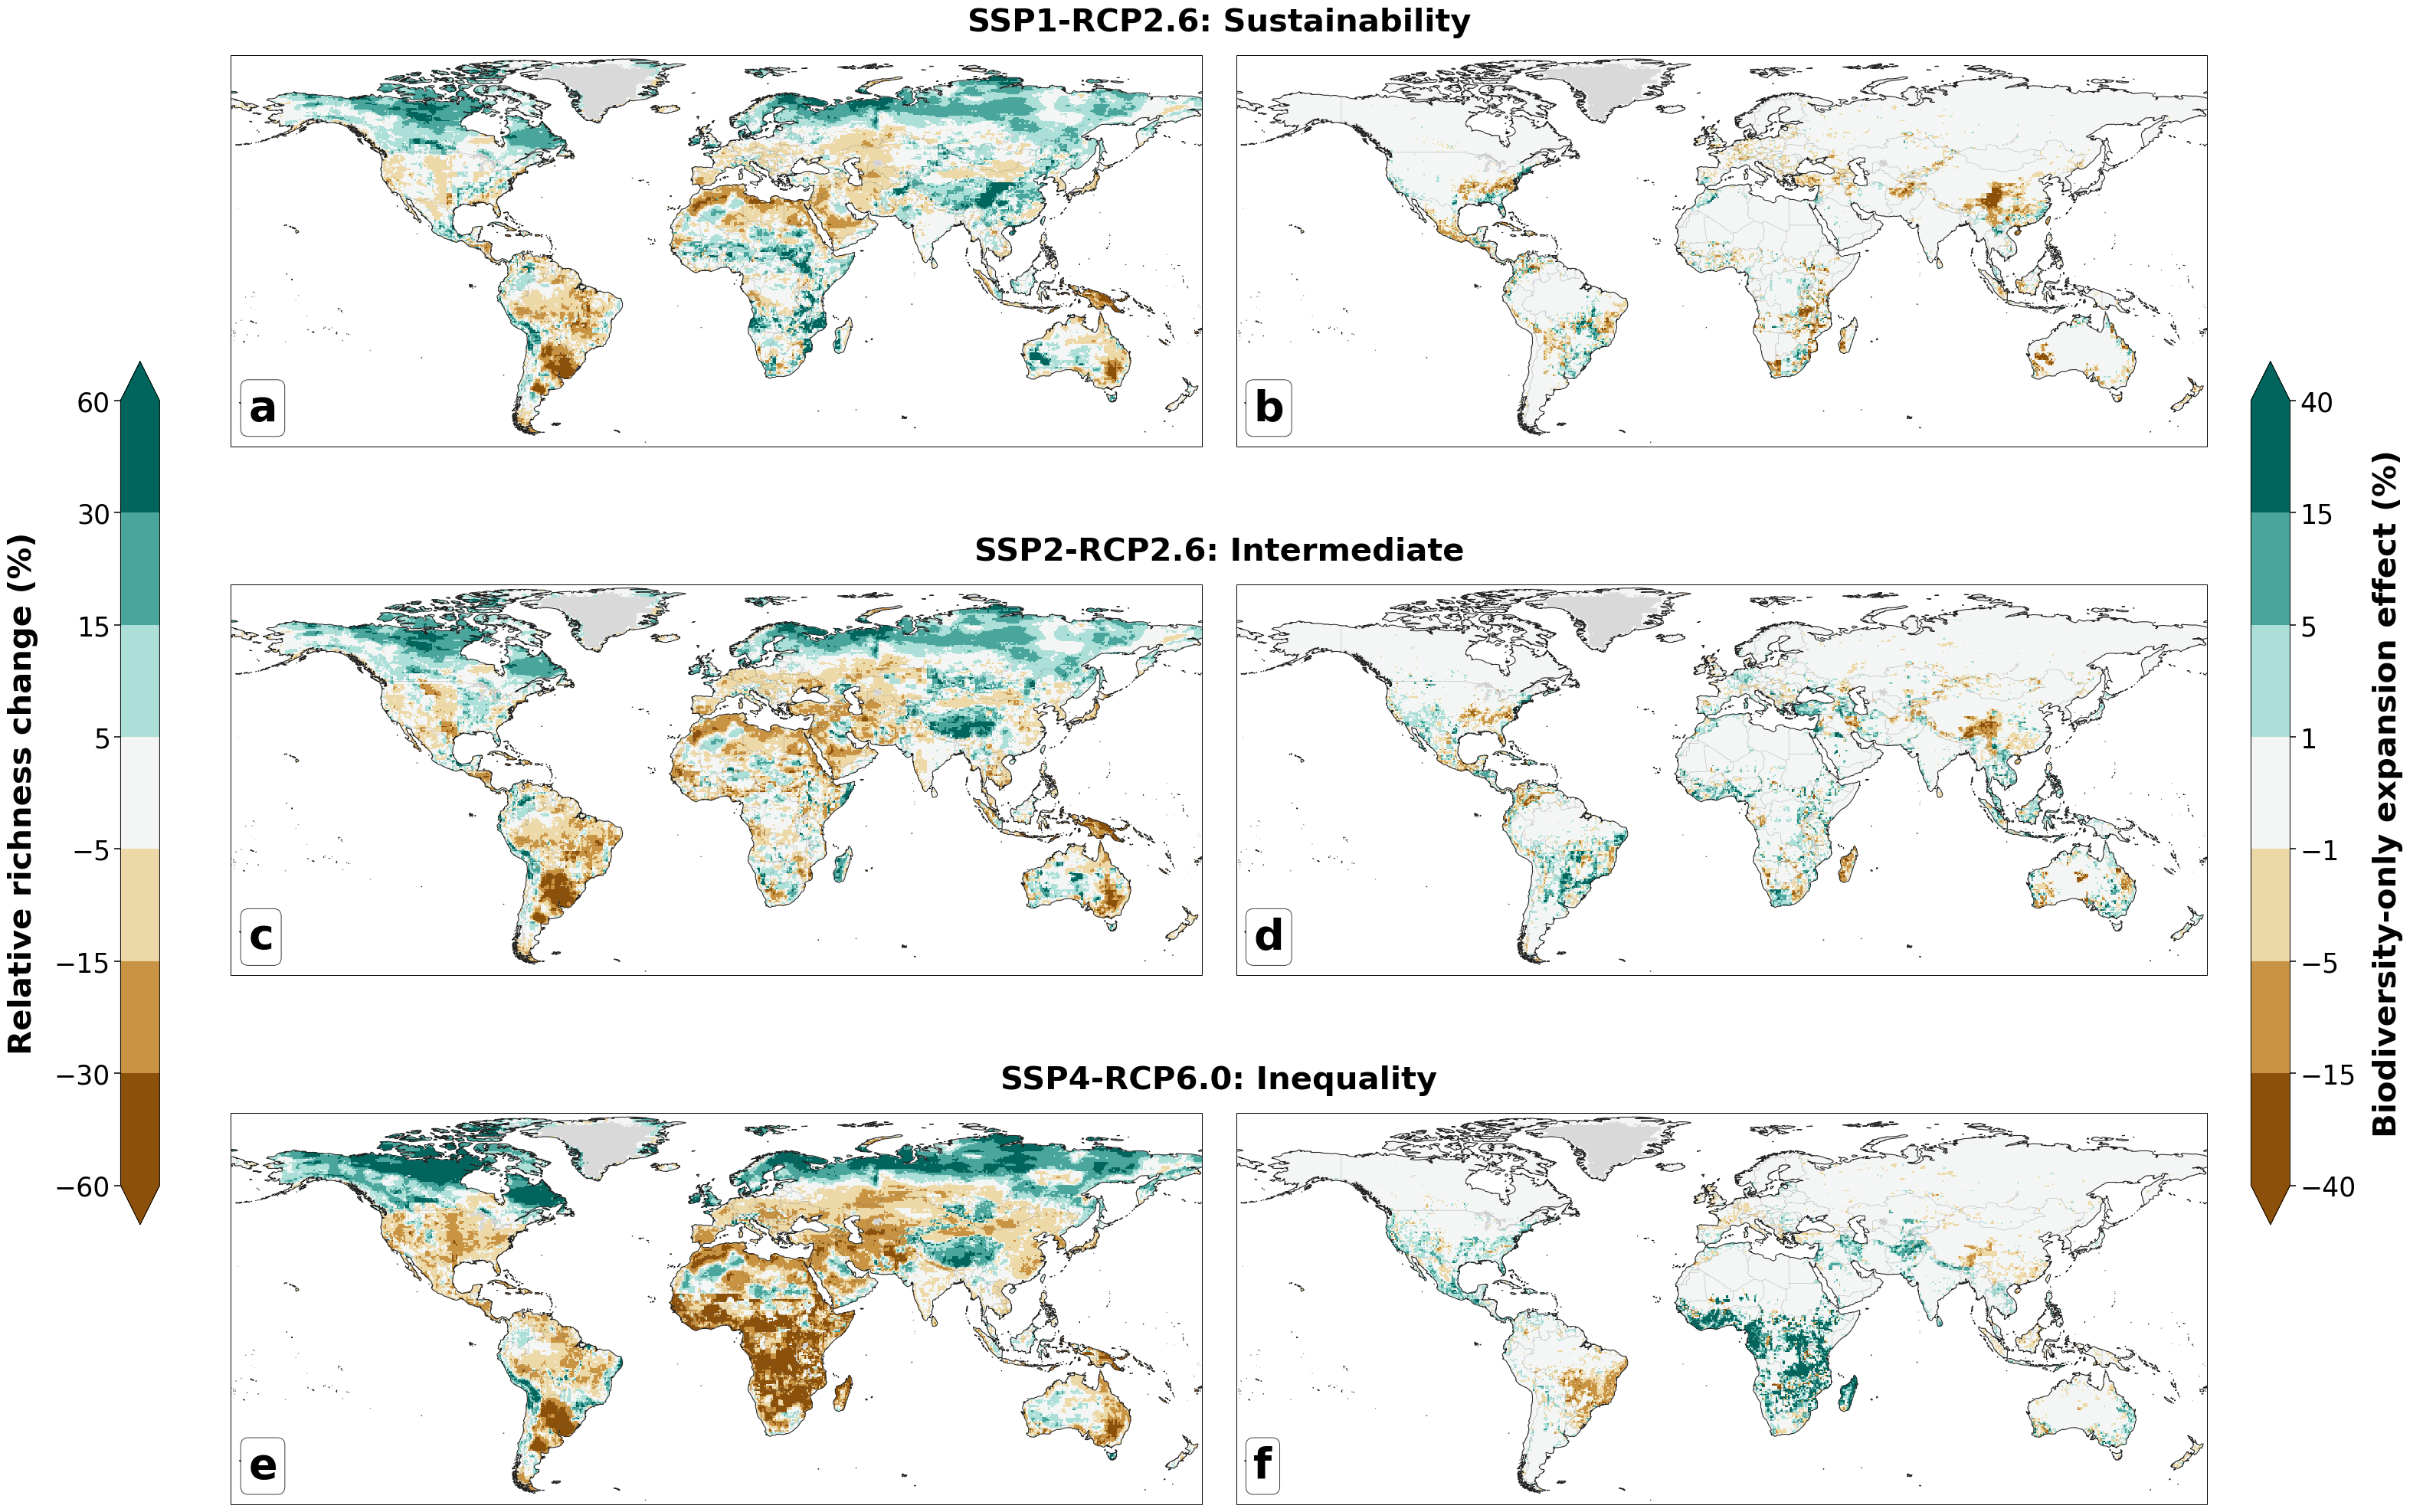


Figure saved successfully:
  PNG:  /capacity/occr_davin/mguzman/chari_P2_review/Global/New_results/Figures/F1_species_richness_complete_retention_BrBG.png
  TIFF: /capacity/occr_davin/mguzman/chari_P2_review/Global/New_results/Figures/F1_species_richness_complete_retention_BrBG.tiff
  PDF:  /capacity/occr_davin/mguzman/chari_P2_review/Global/New_results/Figures/F1_species_richness_complete_retention_BrBG.pdf


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Create Figure 1 from the revised ensemble outputs.

Rows:
    1. Sustainability:
       SSP1 land use + RCP2.6 climate

    2. Intermediate:
       SSP2-RCP4.5 land use + RCP2.6 climate

    3. Inequality:
       SSP4 land use + RCP6.0 climate

Columns:
    1. Relative richness change under the existing 17%-PA network:
       PA17 complete retention in 2080 relative to historical 2015.

    2. Marginal effect of 30% biodiversity-only PA expansion:
       PA30 biodiversity-only complete retention relative to
       PA17 complete retention in 2080.

The analytical contrasts are identified by the two color-bar labels
and explained fully in the figure caption. Separate column headings
are therefore omitted to avoid repeating information.

Map conventions:
    - Brown indicates projected richness loss.
    - Off-white indicates little or no change.
    - Green indicates projected richness gain.
    - Grey indicates terrestrial cells outside the analysis domain.
    - Ocean cells are white.
    - Greenland is retained wherever the model data are valid.

Color-scale design:
    - Seven discrete classes are used in each column.
    - Classes distinguish negligible, small, moderate, and large
      changes without excessive visual fragmentation.
    - The columns use different thresholds because the PA-expansion
      effects are more concentrated around zero.

Output:
    - PNG at 600 dpi
    - TIFF with LZW compression at 600 dpi
    - PDF with vector text and rasterized map layers
"""

import os
import string
import warnings

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
import numpy as np
import xarray as xr

from shapely.geometry import Point
from shapely.ops import unary_union
from shapely.prepared import prep


warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
)


# =====================================================================
# 1. PATHS
# =====================================================================

BASE_PATH = (
    "/capacity/occr_davin/mguzman/chari_P2_review/"
    "Global/PA_scenarios/Sumprob_revised"
)

ENSEMBLE_ROOT = os.path.join(
    BASE_PATH,
    "Ensembles",
)

HIST_FILE = os.path.join(
    ENSEMBLE_ROOT,
    "Historical",
    "total_richness_historical_2015_ensemble.nc",
)

PA17_DIR = os.path.join(
    ENSEMBLE_ROOT,
    "PA17",
    "complete",
)

PA30_BIO_DIR = os.path.join(
    ENSEMBLE_ROOT,
    "PA30_Bio",
    "complete",
)

OUTPUT_DIR = (
    "/capacity/occr_davin/mguzman/"
    "chari_P2_review/Global/New_results/Figures"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True,
)

OUTPUT_PNG = os.path.join(
    OUTPUT_DIR,
    "F1_species_richness_full-eff.png",
)

OUTPUT_TIFF = os.path.join(
    OUTPUT_DIR,
    "F1_species_richness_full-eff.tiff",
)

OUTPUT_PDF = os.path.join(
    OUTPUT_DIR,
    "F1_species_richness_full-eff.pdf",
)


# =====================================================================
# 2. DATA SETTINGS
# =====================================================================

VARIABLE = "prob_clim_disp_luf"

YEAR_FUTURE = "2080"

# Exclude cells with very small reference richness to avoid unstable
# percentage changes.
REFERENCE_THRESHOLD = 0.01

# Preserve calculated values to +/-100%. Values outside the displayed
# scale boundaries receive the appropriate terminal color.
CLIP_LIMIT = 100.0

MAP_EXTENT = [
    -180,
    180,
    -60,
    85,
]


# =====================================================================
# 3. SCENARIO SETTINGS
# =====================================================================

SCENARIOS = [
    "rcp26",
    "rcp45",
    "rcp60",
]

# The middle pathway combines SSP2-RCP4.5 land-use projections with
# RCP2.6 climate projections because RCP4.5 SDM outputs were unavailable.

SCENARIO_TITLES = {
    "rcp26": "SSP1-RCP2.6: Sustainability",
    "rcp45": "SSP2-RCP2.6: Intermediate",
    "rcp60": "SSP4-RCP6.0: Inequality",
}

# These descriptions are retained for terminal diagnostics only.
# They are not printed as headings in the figure.

COMPARISON_DESCRIPTIONS = {
    0: (
        "Existing 17%-PA network: "
        "2080 relative to 2015"
    ),
    1: (
        "30% biodiversity-only expansion: "
        "difference from 17%-PA in 2080"
    ),
}

# Lowercase labels correspond directly to standard caption references:
# a,b; c,d; e,f.

PANEL_LABELS = list(
    string.ascii_lowercase
)


# =====================================================================
# 4. FIGURE SETTINGS
# =====================================================================

# The large canvas preserves the font sizes selected after reviewer
# feedback. The figure can subsequently be reduced proportionally
# without losing map or text resolution.

FIGURE_WIDTH = 30
FIGURE_HEIGHT = 23

SCENARIO_FONT_SIZE = 30
PANEL_FONT_SIZE = 40

COLORBAR_LABEL_SIZE = 30
COLORBAR_TICK_SIZE = 25

COASTLINE_WIDTH = 0.75
BORDER_WIDTH = 0.35

OUTPUT_DPI = 600


# =====================================================================
# 5. TYPOGRAPHY
# =====================================================================

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": [
            "Arial",
            "Helvetica",
            "DejaVu Sans",
        ],
        "font.size": 24,
        "axes.linewidth": 0.7,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "savefig.facecolor": "white",
        "savefig.edgecolor": "white",
    }
)


# =====================================================================
# 6. BACKGROUND COLORS
# =====================================================================

# Pure white for ocean and figure background.
OCEAN_COLOR = "#FFFFFF"

# Neutral grey for terrestrial cells outside the analysis domain.
NO_DATA_COLOR = "#D9D9D9"

# Transparent masked raster cells.
TRANSPARENT_COLOR = (
    1.0,
    1.0,
    1.0,
    0.0,
)


# =====================================================================
# 7. DISCRETE BrBG COLOR SCALES
# =====================================================================

# ---------------------------------------------------------------------
# Left column
# ---------------------------------------------------------------------
#
# Reported distributions:
#
#     SSP1: 1st = -32.14%, 99th = 47.39%
#     SSP2: 1st = -36.19%, 99th = 38.93%
#     SSP4: 1st = -53.38%, 99th = 51.18%
#
# Seven classes:
#
#     < -30%          large decrease
#     -30 to -15%     moderate decrease
#     -15 to -5%      small decrease
#     -5 to +5%       limited change
#     +5 to +15%      small increase
#     +15 to +30%     moderate increase
#     > +30%          large increase

LEFT_BOUNDARIES = [
    -60,
    -30,
    -15,
    -5,
    5,
    15,
    30,
    60,
]


# ---------------------------------------------------------------------
# Right column
# ---------------------------------------------------------------------
#
# Most PA-expansion effects are close to zero, so narrower central
# classes retain meaningful spatial variation.
#
# Seven classes:
#
#     < -15%          large negative effect
#     -15 to -5%      moderate negative effect
#     -5 to -1%       small negative effect
#     -1 to +1%       limited effect
#     +1 to +5%       small positive effect
#     +5 to +15%      moderate positive effect
#     > +15%          large positive effect

RIGHT_BOUNDARIES = [
    -40,
    -15,
    -5,
    -1,
    1,
    5,
    15,
    40,
]


# Use BrBG without the most saturated endpoints. The selected positions
# retain clear separation among seven classes while avoiding excessive
# visual intensity.

BRBG_BASE = plt.get_cmap(
    "BrBG"
)

BRBG_POSITIONS = [
    0.10,
    0.23,
    0.36,
    0.50,
    0.64,
    0.77,
    0.90,
]

BRBG_COLORS = [
    BRBG_BASE(position)
    for position in BRBG_POSITIONS
]


LEFT_CMAP = ListedColormap(
    BRBG_COLORS,
    name="muted_BrBG_left",
)

RIGHT_CMAP = ListedColormap(
    BRBG_COLORS,
    name="muted_BrBG_right",
)


# Masked cells are transparent:
#
#     ocean -> white axes background
#     no-data land -> grey land feature

LEFT_CMAP.set_bad(
    TRANSPARENT_COLOR
)

RIGHT_CMAP.set_bad(
    TRANSPARENT_COLOR
)


# Values beyond displayed limits use the terminal colors.

LEFT_CMAP.set_under(
    BRBG_COLORS[0]
)

LEFT_CMAP.set_over(
    BRBG_COLORS[-1]
)

RIGHT_CMAP.set_under(
    BRBG_COLORS[0]
)

RIGHT_CMAP.set_over(
    BRBG_COLORS[-1]
)


LEFT_NORM = BoundaryNorm(
    LEFT_BOUNDARIES,
    LEFT_CMAP.N,
    clip=False,
)

RIGHT_NORM = BoundaryNorm(
    RIGHT_BOUNDARIES,
    RIGHT_CMAP.N,
    clip=False,
)


# =====================================================================
# 8. INPUT FILE FUNCTIONS
# =====================================================================

def pa17_file(
    scenario,
):
    """
    Return one PA17 complete-retention ensemble path.
    """

    filename = (
        f"total_richness_pa17_complete_"
        f"{scenario}_{YEAR_FUTURE}_ensemble.nc"
    )

    return os.path.join(
        PA17_DIR,
        filename,
    )


def pa30_bio_file(
    scenario,
):
    """
    Return one biodiversity-only PA30 complete-retention ensemble path.
    """

    filename = (
        f"total_richness_pa30_bio_complete_"
        f"{scenario}_{YEAR_FUTURE}_ensemble.nc"
    )

    return os.path.join(
        PA30_BIO_DIR,
        filename,
    )


# =====================================================================
# 9. DATA-LOADING FUNCTIONS
# =====================================================================

def standardize_coordinates(
    data_array,
):
    """
    Standardize latitude and longitude coordinate names and order.
    """

    rename_dict = {}

    if (
        "latitude" in data_array.coords
        or "latitude" in data_array.dims
    ):
        rename_dict["latitude"] = "lat"

    if (
        "longitude" in data_array.coords
        or "longitude" in data_array.dims
    ):
        rename_dict["longitude"] = "lon"

    if rename_dict:
        data_array = data_array.rename(
            rename_dict
        )

    if (
        "lat" not in data_array.coords
        or "lon" not in data_array.coords
    ):
        raise ValueError(
            "Input data do not contain recognizable "
            "latitude and longitude coordinates."
        )

    # Convert 0–360 longitudes to -180–180.
    if float(
        data_array["lon"].max()
    ) > 180:

        data_array = data_array.assign_coords(
            lon=(
                (
                    data_array["lon"]
                    + 180
                )
                % 360
            )
            - 180
        )

    return (
        data_array
        .sortby("lon")
        .sortby("lat")
    )


def load_richness(
    file_path,
):
    """
    Load and validate one ensemble-richness raster.
    """

    if not os.path.isfile(
        file_path
    ):
        raise FileNotFoundError(
            f"Input file not found:\n{file_path}"
        )

    if os.path.getsize(
        file_path
    ) == 0:
        raise ValueError(
            f"Input file is empty:\n{file_path}"
        )

    with xr.open_dataset(
        file_path,
        decode_times=False,
    ) as dataset:

        if VARIABLE not in dataset.data_vars:
            raise KeyError(
                f"Variable {VARIABLE!r} was not found in:\n"
                f"{file_path}\n"
                f"Available variables: "
                f"{list(dataset.data_vars)}"
            )

        richness = (
            dataset[VARIABLE]
            .squeeze(drop=True)
            .load()
        )

    richness = standardize_coordinates(
        richness
    )

    return richness.astype(
        np.float32
    )


def align_exact(
    first,
    second,
    description,
):
    """
    Validate that two rasters have identical coordinates.
    """

    try:

        first_aligned, second_aligned = xr.align(
            first,
            second,
            join="exact",
        )

    except ValueError as error:

        raise ValueError(
            f"Grid mismatch while calculating {description}."
        ) from error

    return (
        first_aligned,
        second_aligned,
    )


def relative_change(
    future,
    reference,
    description,
):
    """
    Calculate percentage change relative to a reference raster.
    """

    future, reference = align_exact(
        future,
        reference,
        description,
    )

    valid_reference = reference.where(
        np.isfinite(reference)
        & (
            reference
            > REFERENCE_THRESHOLD
        )
    )

    change = (
        (
            future
            - valid_reference
        )
        / valid_reference
    ) * 100.0

    change = change.where(
        np.isfinite(change)
    )

    return change.clip(
        min=-CLIP_LIMIT,
        max=CLIP_LIMIT,
    )


def print_summary(
    data_array,
    scenario,
    comparison,
):
    """
    Print summary statistics for one plotted raster.
    """

    finite_values = data_array.values[
        np.isfinite(
            data_array.values
        )
    ]

    if finite_values.size == 0:

        print(
            f"[WARNING] No finite values: "
            f"{scenario} | {comparison}"
        )

        return

    print(
        f"[{scenario}] {comparison}\n"
        f"    Valid cells: {finite_values.size:,}\n"
        f"    Minimum: {np.min(finite_values):.2f}%\n"
        f"    1st percentile: "
        f"{np.quantile(finite_values, 0.01):.2f}%\n"
        f"    Median: {np.median(finite_values):.2f}%\n"
        f"    99th percentile: "
        f"{np.quantile(finite_values, 0.99):.2f}%\n"
        f"    Maximum: {np.max(finite_values):.2f}%"
    )


# =====================================================================
# 10. BUILD NATURAL EARTH LAND MASK
# =====================================================================

def build_land_mask(
    template,
):
    """
    Build a land mask at the raster grid-cell centers.

    Marine cells are excluded from the plotted raster.

    Greenland and all other terrestrial areas are retained wherever
    historical richness exceeds the reference threshold.
    """

    longitude_values = (
        template["lon"].values
    )

    latitude_values = (
        template["lat"].values
    )

    longitude_grid, latitude_grid = np.meshgrid(
        longitude_values,
        latitude_values,
    )


    # Use the 50-m Natural Earth land polygons for a more accurate
    # coastline mask in the publication figure.

    land_shapefile = shpreader.natural_earth(
        resolution="50m",
        category="physical",
        name="land",
    )


    land_geometries = list(
        shpreader.Reader(
            land_shapefile
        ).geometries()
    )


    combined_land_geometry = unary_union(
        land_geometries
    )


    prepared_land_geometry = prep(
        combined_land_geometry
    )


    land_values = np.zeros(
        longitude_grid.shape,
        dtype=bool,
    )


    for latitude_index in range(
        latitude_grid.shape[0]
    ):

        for longitude_index in range(
            longitude_grid.shape[1]
        ):

            point = Point(
                float(
                    longitude_grid[
                        latitude_index,
                        longitude_index
                    ]
                ),
                float(
                    latitude_grid[
                        latitude_index,
                        longitude_index
                    ]
                ),
            )


            land_values[
                latitude_index,
                longitude_index
            ] = prepared_land_geometry.covers(
                point
            )


    return xr.DataArray(
        land_values,
        coords={
            "lat": template["lat"],
            "lon": template["lon"],
        },
        dims=[
            "lat",
            "lon",
        ],
        name="land_mask",
    )


# =====================================================================
# 11. LOAD HISTORICAL DATA AND DEFINE ANALYSIS DOMAIN
# =====================================================================

print(
    "Loading historical ensemble:"
)

print(
    f"  {HIST_FILE}"
)


historical = load_richness(
    HIST_FILE
)


print(
    "Building Natural Earth land mask..."
)


LAND_MASK = build_land_mask(
    historical
)


# The analysis domain requires:
#
#     1. finite historical richness;
#     2. historical richness above the reference threshold;
#     3. a grid-cell center located on land.
#
# Greenland is treated identically to all other terrestrial regions.

ANALYSIS_MASK = (
    np.isfinite(historical)
    & (
        historical
        > REFERENCE_THRESHOLD
    )
    & LAND_MASK
)


land_cell_count = int(
    LAND_MASK.sum().item()
)

analysis_cell_count = int(
    ANALYSIS_MASK.sum().item()
)


print(
    f"Natural Earth land cells: "
    f"{land_cell_count:,}"
)

print(
    f"Final analysis cells: "
    f"{analysis_cell_count:,}"
)


if analysis_cell_count == 0:

    raise RuntimeError(
        "The final analysis mask contains no valid cells."
    )


# =====================================================================
# 12. FIGURE SETUP
# =====================================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(
        FIGURE_WIDTH,
        FIGURE_HEIGHT,
    ),
    facecolor=OCEAN_COLOR,
    subplot_kw={
        "projection": ccrs.PlateCarree(),
    },
)


# No separate column headings are included.
#
# The upper margin is reserved only for the first scenario title.
# Increased row spacing provides room for the second and third titles.

plt.subplots_adjust(
    left=0.070,
    right=0.930,
    top=0.925,
    bottom=0.070,
    hspace=0.18,
    wspace=0.035,
)


left_image = None
right_image = None


# =====================================================================
# 13. PROCESS AND PLOT EACH SCENARIO
# =====================================================================

for row_index, scenario in enumerate(
    SCENARIOS
):

    file_17pa = pa17_file(
        scenario
    )

    file_pa30_bio = pa30_bio_file(
        scenario
    )


    print("")
    print(
        f"Loading scenario: {scenario}"
    )

    print(
        f"  PA17: {file_17pa}"
    )

    print(
        f"  PA30 biodiversity-only: "
        f"{file_pa30_bio}"
    )


    richness_17pa = load_richness(
        file_17pa
    )

    richness_pa30_bio = load_richness(
        file_pa30_bio
    )


    # -----------------------------------------------------------------
    # Left column:
    # PA17 in 2080 relative to the historical 2015 baseline.
    # -----------------------------------------------------------------

    change_17pa = relative_change(
        future=richness_17pa,
        reference=historical,
        description=(
            f"PA17 2080 versus 2015 "
            f"for {scenario}"
        ),
    )


    # -----------------------------------------------------------------
    # Right column:
    # PA30 biodiversity-only relative to PA17 in 2080.
    # -----------------------------------------------------------------

    change_pa30 = relative_change(
        future=richness_pa30_bio,
        reference=richness_17pa,
        description=(
            f"PA30 biodiversity-only versus PA17 "
            f"for {scenario}"
        ),
    )


    # Apply the same terrestrial historical domain to both comparisons.
    #
    # Cells outside that domain are set to NaN and plotted transparently.

    change_17pa = change_17pa.where(
        ANALYSIS_MASK,
        other=np.nan,
    )

    change_pa30 = change_pa30.where(
        ANALYSIS_MASK,
        other=np.nan,
    )


    print_summary(
        change_17pa,
        scenario,
        COMPARISON_DESCRIPTIONS[0],
    )

    print_summary(
        change_pa30,
        scenario,
        COMPARISON_DESCRIPTIONS[1],
    )


    row_data = [
        change_17pa,
        change_pa30,
    ]


    for column_index, plot_data in enumerate(
        row_data
    ):

        axis = axes[
            row_index,
            column_index,
        ]


        if column_index == 0:

            current_cmap = LEFT_CMAP
            current_norm = LEFT_NORM

        else:

            current_cmap = RIGHT_CMAP
            current_norm = RIGHT_NORM


        # -------------------------------------------------------------
        # Map extent and background
        # -------------------------------------------------------------

        axis.set_extent(
            MAP_EXTENT,
            crs=ccrs.PlateCarree(),
        )


        # White axes background provides the ocean color.

        axis.set_facecolor(
            OCEAN_COLOR
        )


        # Grey terrestrial layer remains visible wherever the raster
        # is transparent over land.

        axis.add_feature(
            cfeature.LAND.with_scale(
                "50m"
            ),
            facecolor=NO_DATA_COLOR,
            edgecolor="none",
            zorder=0,
        )


        # -------------------------------------------------------------
        # Raster
        # -------------------------------------------------------------

        masked_values = np.ma.masked_invalid(
            plot_data.values
        )


        image = axis.pcolormesh(
            plot_data["lon"],
            plot_data["lat"],
            masked_values,
            transform=ccrs.PlateCarree(),
            cmap=current_cmap,
            norm=current_norm,
            shading="auto",
            rasterized=True,
            zorder=1,
        )


        if column_index == 0:

            left_image = image

        else:

            right_image = image


        # -------------------------------------------------------------
        # Coastlines and borders
        # -------------------------------------------------------------

        axis.coastlines(
            resolution="50m",
            color="#222222",
            linewidth=COASTLINE_WIDTH,
            zorder=3,
        )


        axis.add_feature(
            cfeature.BORDERS.with_scale(
                "50m"
            ),
            edgecolor="#666666",
            linewidth=BORDER_WIDTH,
            alpha=0.50,
            zorder=3,
        )


        # -------------------------------------------------------------
        # Panel label
        # -------------------------------------------------------------

        panel_index = (
            row_index * 2
            + column_index
        )


        axis.text(
            0.018,
            0.045,
            PANEL_LABELS[
                panel_index
            ],
            transform=axis.transAxes,
            fontsize=PANEL_FONT_SIZE,
            fontweight="bold",
            ha="left",
            va="bottom",
            zorder=5,
            bbox={
                "facecolor": OCEAN_COLOR,
                "edgecolor": "#333333",
                "linewidth": 0.7,
                "alpha": 0.96,
                "boxstyle": (
                    "round,pad=0.18"
                ),
            },
        )


    # -----------------------------------------------------------------
    # Scenario title for the current row
    # -----------------------------------------------------------------

    left_position = axes[
        row_index,
        0,
    ].get_position()

    right_position = axes[
        row_index,
        1,
    ].get_position()


    scenario_x = (
        left_position.x0
        + right_position.x1
    ) / 2


    scenario_y = (
        left_position.y1
        + 0.010
    )


    fig.text(
        scenario_x,
        scenario_y,
        SCENARIO_TITLES[
            scenario
        ],
        fontsize=SCENARIO_FONT_SIZE,
        fontweight="bold",
        ha="center",
        va="bottom",
    )


# =====================================================================
# 14. COLOR BARS
# =====================================================================

if left_image is None:

    raise RuntimeError(
        "No image was created for the left column."
    )


if right_image is None:

    raise RuntimeError(
        "No image was created for the right column."
    )


# ---------------------------------------------------------------------
# Left color bar
# ---------------------------------------------------------------------

left_colorbar_axis = fig.add_axes(
    [
        0.022,
        0.245,
        0.017,
        0.49,
    ]
)


left_colorbar = fig.colorbar(
    left_image,
    cax=left_colorbar_axis,
    orientation="vertical",
    ticks=LEFT_BOUNDARIES,
    boundaries=LEFT_BOUNDARIES,
    spacing="uniform",
    extend="both",
)


left_colorbar.set_label(
    "Relative richness change (%)",
    fontsize=COLORBAR_LABEL_SIZE,
    fontweight="semibold",
    labelpad=15,
)


left_colorbar.ax.tick_params(
    labelsize=COLORBAR_TICK_SIZE,
    width=1.1,
    length=6,
)


left_colorbar.ax.yaxis.set_ticks_position(
    "left"
)

left_colorbar.ax.yaxis.set_label_position(
    "left"
)


# ---------------------------------------------------------------------
# Right color bar
# ---------------------------------------------------------------------

right_colorbar_axis = fig.add_axes(
    [
        0.949,
        0.245,
        0.017,
        0.49,
    ]
)


right_colorbar = fig.colorbar(
    right_image,
    cax=right_colorbar_axis,
    orientation="vertical",
    ticks=RIGHT_BOUNDARIES,
    boundaries=RIGHT_BOUNDARIES,
    spacing="uniform",
    extend="both",
)


right_colorbar.set_label(
    "Biodiversity-only expansion effect (%)",
    fontsize=COLORBAR_LABEL_SIZE,
    fontweight="semibold",
    labelpad=15,
)


right_colorbar.ax.tick_params(
    labelsize=COLORBAR_TICK_SIZE,
    width=1.1,
    length=6,
)


# =====================================================================
# 15. SAVE FIGURE
# =====================================================================

png_metadata = {
    "Title": (
        "Projected vertebrate richness changes under "
        "alternative SSP-RCP and PA scenarios"
    ),
    "Description": (
        "Projected relative richness change under the existing "
        "protected-area network and the additional effect of "
        "biodiversity-only protected-area expansion."
    ),
}


pdf_metadata = {
    "Title": (
        "Projected vertebrate richness changes under "
        "alternative SSP-RCP and PA scenarios"
    ),
    "Subject": (
        "Projected relative richness change under the existing "
        "protected-area network and the additional effect of "
        "biodiversity-only protected-area expansion."
    ),
}


# PNG: high-resolution raster output.

fig.savefig(
    OUTPUT_PNG,
    dpi=OUTPUT_DPI,
    bbox_inches="tight",
    pad_inches=0.05,
    facecolor=OCEAN_COLOR,
    edgecolor=OCEAN_COLOR,
    transparent=False,
    metadata=png_metadata,
)


# TIFF: publication-grade lossless output with LZW compression.

fig.savefig(
    OUTPUT_TIFF,
    format="tiff",
    dpi=OUTPUT_DPI,
    bbox_inches="tight",
    pad_inches=0.05,
    facecolor=OCEAN_COLOR,
    edgecolor=OCEAN_COLOR,
    transparent=False,
    pil_kwargs={
        "compression": "tiff_lzw",
    },
)


# PDF: map rasters remain rasterized, while text, borders, coastlines,
# panel labels, and color bars remain vector elements.

fig.savefig(
    OUTPUT_PDF,
    format="pdf",
    dpi=OUTPUT_DPI,
    bbox_inches="tight",
    pad_inches=0.05,
    facecolor=OCEAN_COLOR,
    edgecolor=OCEAN_COLOR,
    transparent=False,
    metadata=pdf_metadata,
)


# Display in a notebook.
plt.show()

# For a non-interactive cluster job, replace plt.show() with:
# plt.close(fig)


print("")
print(
    "Figure saved successfully:"
)

print(
    f"  PNG:  {OUTPUT_PNG}"
)

print(
    f"  TIFF: {OUTPUT_TIFF}"
)

print(
    f"  PDF:  {OUTPUT_PDF}"
)

Supplementary Fig. 2. Multi-objective (biodiversity conservation, carbon sequestration and water regulation)

Loading historical ensemble:
  /capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob_revised/Ensembles/Historical/total_richness_historical_2015_ensemble.nc
Building Natural Earth land mask...
Natural Earth land cells: 85,698
Final analysis cells: 58,847

Loading scenario: rcp26
  PA17: /capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob_revised/Ensembles/PA17/complete/total_richness_pa17_complete_rcp26_2080_ensemble.nc
  PA30 multi-objective: /capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob_revised/Ensembles/PA30_BCW/complete/total_richness_pa30_bcw_complete_rcp26_2080_ensemble.nc
[rcp26] Existing 17%-PA network: 2080 relative to 2015
    Valid cells: 58,847
    Minimum: -70.13%
    1st percentile: -32.07%
    Median: 1.76%
    99th percentile: 47.55%
    Maximum: 100.00%
[rcp26] 30% multi-objective expansion: difference from 17%-PA in 2080
    Valid cells: 58,847
    Minimum: -53.57%
    1st percentile: -8.58%
    Median

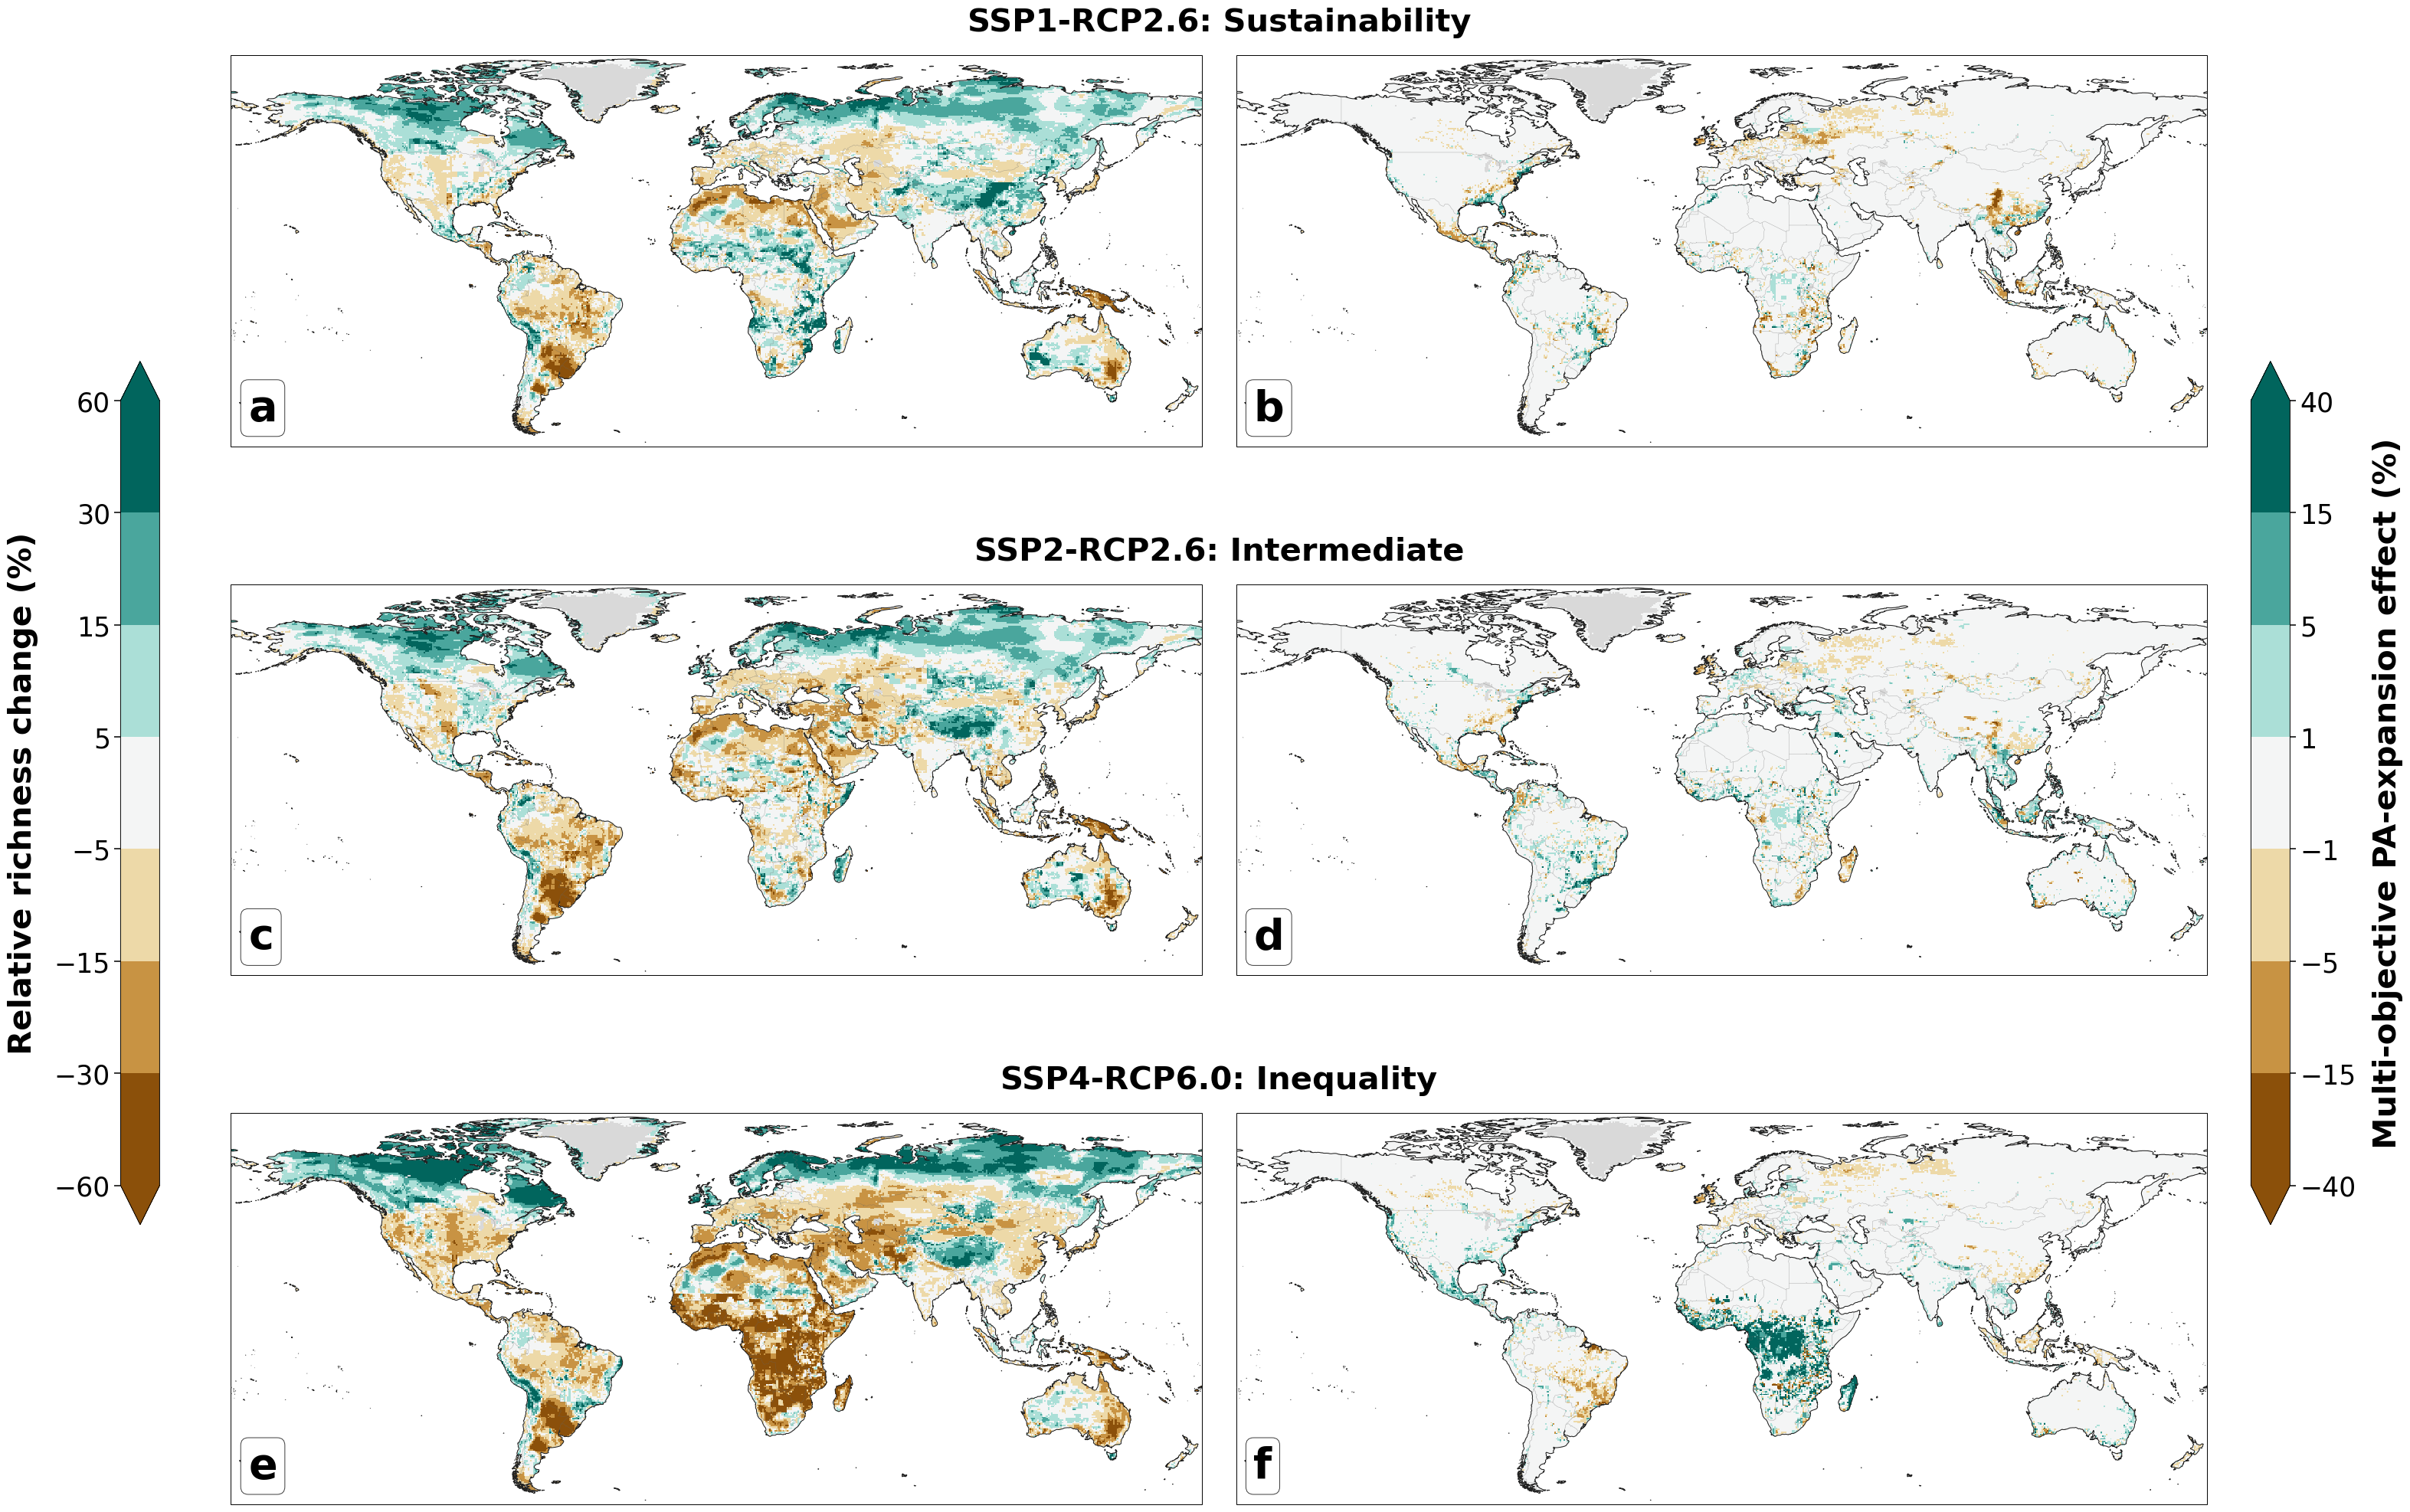


Figure saved successfully:
  PNG:  /capacity/occr_davin/mguzman/chari_P2_review/Global/New_results/Figures/Supplementary_F2_species_richness_full-eff_multi_objective.png
  TIFF: /capacity/occr_davin/mguzman/chari_P2_review/Global/New_results/Figures/Supplementary_F2_species_richness_full-eff_multi_objective.tiff
  PDF:  /capacity/occr_davin/mguzman/chari_P2_review/Global/New_results/Figures/Supplementary_F2_species_richness_full-eff_multi_objective.pdf


In [9]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Create the multi-objective version of Figure 1 from revised ensemble outputs.

Rows:
    1. Sustainability: SSP1 land use + RCP2.6 climate
    2. Intermediate: SSP2-RCP4.5 land use + RCP2.6 climate
    3. Inequality: SSP4 land use + RCP6.0 climate

Columns:
    1. Relative richness change under the existing 17%-PA network:
       PA17 complete retention in 2080 relative to historical 2015.

    2. Marginal effect of 30% multi-objective PA expansion:
       PA30 multi-objective complete retention relative to
       PA17 complete retention in 2080.

Map conventions:
    - Brown indicates projected richness loss.
    - Off-white indicates little or no change.
    - Green indicates projected richness gain.
    - Grey indicates terrestrial cells outside the analysis domain.
    - Ocean cells are white.
    - Greenland is retained wherever model data are valid.

Outputs:
    - PNG at 600 dpi
    - LZW-compressed TIFF at 600 dpi
    - PDF with vector text and rasterized map layers
"""

import os
import string
import warnings

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
import numpy as np
import xarray as xr

from shapely.geometry import Point
from shapely.ops import unary_union
from shapely.prepared import prep

warnings.filterwarnings("ignore", category=RuntimeWarning)


# =====================================================================
# 1. PATHS
# =====================================================================

BASE_PATH = (
    "/capacity/occr_davin/mguzman/chari_P2_review/"
    "Global/PA_scenarios/Sumprob_revised"
)

ENSEMBLE_ROOT = os.path.join(BASE_PATH, "Ensembles")

HIST_FILE = os.path.join(
    ENSEMBLE_ROOT,
    "Historical",
    "total_richness_historical_2015_ensemble.nc",
)

PA17_DIR = os.path.join(
    ENSEMBLE_ROOT,
    "PA17",
    "complete",
)

PA30_BCW_DIR = os.path.join(
    ENSEMBLE_ROOT,
    "PA30_BCW",
    "complete",
)

OUTPUT_DIR = (
    "/capacity/occr_davin/mguzman/"
    "chari_P2_review/Global/New_results/Figures"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

OUTPUT_PNG = os.path.join(
    OUTPUT_DIR,
    "Supplementary_F2_species_richness_full-eff_multi_objective.png",
)

OUTPUT_TIFF = os.path.join(
    OUTPUT_DIR,
    "Supplementary_F2_species_richness_full-eff_multi_objective.tiff",
)

OUTPUT_PDF = os.path.join(
    OUTPUT_DIR,
    "Supplementary_F2_species_richness_full-eff_multi_objective.pdf",
)


# =====================================================================
# 2. DATA SETTINGS
# =====================================================================

VARIABLE = "prob_clim_disp_luf"
YEAR_FUTURE = "2080"
REFERENCE_THRESHOLD = 0.01
CLIP_LIMIT = 100.0

MAP_EXTENT = [
    -180,
    180,
    -60,
    85,
]


# =====================================================================
# 3. SCENARIO SETTINGS
# =====================================================================

SCENARIOS = [
    "rcp26",
    "rcp45",
    "rcp60",
]

SCENARIO_TITLES = {
    "rcp26": "SSP1-RCP2.6: Sustainability",
    "rcp45": "SSP2-RCP2.6: Intermediate",
    "rcp60": "SSP4-RCP6.0: Inequality",
}

COMPARISON_DESCRIPTIONS = {
    0: (
        "Existing 17%-PA network: "
        "2080 relative to 2015"
    ),
    1: (
        "30% multi-objective expansion: "
        "difference from 17%-PA in 2080"
    ),
}

PANEL_LABELS = list(string.ascii_lowercase)


# =====================================================================
# 4. FIGURE SETTINGS
# =====================================================================

FIGURE_WIDTH = 30
FIGURE_HEIGHT = 23

SCENARIO_FONT_SIZE = 30
PANEL_FONT_SIZE = 40
COLORBAR_LABEL_SIZE = 30
COLORBAR_TICK_SIZE = 25

COASTLINE_WIDTH = 0.75
BORDER_WIDTH = 0.35
OUTPUT_DPI = 600


# =====================================================================
# 5. TYPOGRAPHY
# =====================================================================

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": [
            "Arial",
            "Helvetica",
            "DejaVu Sans",
        ],
        "font.size": 24,
        "axes.linewidth": 0.7,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "savefig.facecolor": "white",
        "savefig.edgecolor": "white",
    }
)


# =====================================================================
# 6. BACKGROUND COLORS
# =====================================================================

OCEAN_COLOR = "#FFFFFF"
NO_DATA_COLOR = "#D9D9D9"
TRANSPARENT_COLOR = (1.0, 1.0, 1.0, 0.0)


# =====================================================================
# 7. DISCRETE BrBG COLOR SCALES
# =====================================================================

# PA17 in 2080 relative to 2015.
LEFT_BOUNDARIES = [
    -60,
    -30,
    -15,
    -5,
    5,
    15,
    30,
    60,
]

# Multi-objective PA30 relative to PA17 in 2080.
# These thresholds match the biodiversity-only figure for direct visual
# comparison between the two PA-expansion strategies.
RIGHT_BOUNDARIES = [
    -40,
    -15,
    -5,
    -1,
    1,
    5,
    15,
    40,
]

BRBG_BASE = plt.get_cmap("BrBG")

BRBG_POSITIONS = [
    0.10,
    0.23,
    0.36,
    0.50,
    0.64,
    0.77,
    0.90,
]

BRBG_COLORS = [
    BRBG_BASE(position)
    for position in BRBG_POSITIONS
]

LEFT_CMAP = ListedColormap(
    BRBG_COLORS,
    name="muted_BrBG_left",
)

RIGHT_CMAP = ListedColormap(
    BRBG_COLORS,
    name="muted_BrBG_right_multi_objective",
)

LEFT_CMAP.set_bad(TRANSPARENT_COLOR)
RIGHT_CMAP.set_bad(TRANSPARENT_COLOR)

LEFT_CMAP.set_under(BRBG_COLORS[0])
LEFT_CMAP.set_over(BRBG_COLORS[-1])
RIGHT_CMAP.set_under(BRBG_COLORS[0])
RIGHT_CMAP.set_over(BRBG_COLORS[-1])

LEFT_NORM = BoundaryNorm(
    LEFT_BOUNDARIES,
    LEFT_CMAP.N,
    clip=False,
)

RIGHT_NORM = BoundaryNorm(
    RIGHT_BOUNDARIES,
    RIGHT_CMAP.N,
    clip=False,
)


# =====================================================================
# 8. INPUT FILE FUNCTIONS
# =====================================================================


def pa17_file(scenario):
    """Return one PA17 complete-retention ensemble path."""

    filename = (
        f"total_richness_pa17_complete_"
        f"{scenario}_{YEAR_FUTURE}_ensemble.nc"
    )

    return os.path.join(PA17_DIR, filename)



def pa30_bcw_file(scenario):
    """Return one multi-objective PA30 complete-retention ensemble path."""

    filename = (
        f"total_richness_pa30_bcw_complete_"
        f"{scenario}_{YEAR_FUTURE}_ensemble.nc"
    )

    return os.path.join(PA30_BCW_DIR, filename)


# =====================================================================
# 9. DATA-LOADING FUNCTIONS
# =====================================================================


def standardize_coordinates(data_array):
    """Standardize latitude and longitude coordinate names and order."""

    rename_dict = {}

    if (
        "latitude" in data_array.coords
        or "latitude" in data_array.dims
    ):
        rename_dict["latitude"] = "lat"

    if (
        "longitude" in data_array.coords
        or "longitude" in data_array.dims
    ):
        rename_dict["longitude"] = "lon"

    if rename_dict:
        data_array = data_array.rename(rename_dict)

    if (
        "lat" not in data_array.coords
        or "lon" not in data_array.coords
    ):
        raise ValueError(
            "Input data do not contain recognizable latitude and "
            "longitude coordinates."
        )

    if float(data_array["lon"].max()) > 180:
        data_array = data_array.assign_coords(
            lon=((data_array["lon"] + 180) % 360) - 180
        )

    return data_array.sortby("lon").sortby("lat")



def load_richness(file_path):
    """Load and validate one ensemble-richness raster."""

    if not os.path.isfile(file_path):
        raise FileNotFoundError(
            f"Input file not found:\n{file_path}"
        )

    if os.path.getsize(file_path) == 0:
        raise ValueError(
            f"Input file is empty:\n{file_path}"
        )

    with xr.open_dataset(
        file_path,
        decode_times=False,
    ) as dataset:

        if VARIABLE not in dataset.data_vars:
            raise KeyError(
                f"Variable {VARIABLE!r} was not found in:\n"
                f"{file_path}\n"
                f"Available variables: {list(dataset.data_vars)}"
            )

        richness = (
            dataset[VARIABLE]
            .squeeze(drop=True)
            .load()
        )

    richness = standardize_coordinates(richness)

    return richness.astype(np.float32)



def align_exact(first, second, description):
    """Validate that two rasters have identical coordinates."""

    try:
        first_aligned, second_aligned = xr.align(
            first,
            second,
            join="exact",
        )

    except ValueError as error:
        raise ValueError(
            f"Grid mismatch while calculating {description}."
        ) from error

    return first_aligned, second_aligned



def relative_change(future, reference, description):
    """Calculate percentage change relative to a reference raster."""

    future, reference = align_exact(
        future,
        reference,
        description,
    )

    valid_reference = reference.where(
        np.isfinite(reference)
        & (reference > REFERENCE_THRESHOLD)
    )

    change = (
        (future - valid_reference)
        / valid_reference
    ) * 100.0

    change = change.where(np.isfinite(change))

    return change.clip(
        min=-CLIP_LIMIT,
        max=CLIP_LIMIT,
    )



def print_summary(data_array, scenario, comparison):
    """Print summary statistics for one plotted raster."""

    finite_values = data_array.values[
        np.isfinite(data_array.values)
    ]

    if finite_values.size == 0:
        print(
            f"[WARNING] No finite values: {scenario} | {comparison}"
        )
        return

    print(
        f"[{scenario}] {comparison}\n"
        f"    Valid cells: {finite_values.size:,}\n"
        f"    Minimum: {np.min(finite_values):.2f}%\n"
        f"    1st percentile: "
        f"{np.quantile(finite_values, 0.01):.2f}%\n"
        f"    Median: {np.median(finite_values):.2f}%\n"
        f"    99th percentile: "
        f"{np.quantile(finite_values, 0.99):.2f}%\n"
        f"    Maximum: {np.max(finite_values):.2f}%"
    )


# =====================================================================
# 10. BUILD NATURAL EARTH LAND MASK
# =====================================================================


def build_land_mask(template):
    """
    Build a land mask at raster grid-cell centres.

    Marine cells are excluded. Greenland and other terrestrial areas are
    retained wherever historical richness exceeds the threshold.
    """

    longitude_values = template["lon"].values
    latitude_values = template["lat"].values

    longitude_grid, latitude_grid = np.meshgrid(
        longitude_values,
        latitude_values,
    )

    land_shapefile = shpreader.natural_earth(
        resolution="50m",
        category="physical",
        name="land",
    )

    land_geometries = list(
        shpreader.Reader(land_shapefile).geometries()
    )

    combined_land_geometry = unary_union(land_geometries)
    prepared_land_geometry = prep(combined_land_geometry)

    land_values = np.zeros(
        longitude_grid.shape,
        dtype=bool,
    )

    for latitude_index in range(latitude_grid.shape[0]):
        for longitude_index in range(longitude_grid.shape[1]):

            point = Point(
                float(
                    longitude_grid[
                        latitude_index,
                        longitude_index,
                    ]
                ),
                float(
                    latitude_grid[
                        latitude_index,
                        longitude_index,
                    ]
                ),
            )

            land_values[
                latitude_index,
                longitude_index,
            ] = prepared_land_geometry.covers(point)

    return xr.DataArray(
        land_values,
        coords={
            "lat": template["lat"],
            "lon": template["lon"],
        },
        dims=["lat", "lon"],
        name="land_mask",
    )


# =====================================================================
# 11. LOAD HISTORICAL DATA AND DEFINE ANALYSIS DOMAIN
# =====================================================================

print("Loading historical ensemble:")
print(f"  {HIST_FILE}")

historical = load_richness(HIST_FILE)

print("Building Natural Earth land mask...")

LAND_MASK = build_land_mask(historical)

ANALYSIS_MASK = (
    np.isfinite(historical)
    & (historical > REFERENCE_THRESHOLD)
    & LAND_MASK
)

land_cell_count = int(LAND_MASK.sum().item())
analysis_cell_count = int(ANALYSIS_MASK.sum().item())

print(f"Natural Earth land cells: {land_cell_count:,}")
print(f"Final analysis cells: {analysis_cell_count:,}")

if analysis_cell_count == 0:
    raise RuntimeError(
        "The final analysis mask contains no valid cells."
    )


# =====================================================================
# 12. FIGURE SETUP
# =====================================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(FIGURE_WIDTH, FIGURE_HEIGHT),
    facecolor=OCEAN_COLOR,
    subplot_kw={
        "projection": ccrs.PlateCarree(),
    },
)

plt.subplots_adjust(
    left=0.070,
    right=0.930,
    top=0.925,
    bottom=0.070,
    hspace=0.18,
    wspace=0.035,
)

left_image = None
right_image = None


# =====================================================================
# 13. PROCESS AND PLOT EACH SCENARIO
# =====================================================================

for row_index, scenario in enumerate(SCENARIOS):

    file_17pa = pa17_file(scenario)
    file_pa30_bcw = pa30_bcw_file(scenario)

    print("")
    print(f"Loading scenario: {scenario}")
    print(f"  PA17: {file_17pa}")
    print(f"  PA30 multi-objective: {file_pa30_bcw}")

    richness_17pa = load_richness(file_17pa)
    richness_pa30_bcw = load_richness(file_pa30_bcw)

    # Left column: PA17 in 2080 relative to historical 2015.
    change_17pa = relative_change(
        future=richness_17pa,
        reference=historical,
        description=(
            f"PA17 2080 versus 2015 for {scenario}"
        ),
    )

    # Right column: PA30 multi-objective relative to PA17 in 2080.
    change_pa30_bcw = relative_change(
        future=richness_pa30_bcw,
        reference=richness_17pa,
        description=(
            f"PA30 multi-objective versus PA17 for {scenario}"
        ),
    )

    change_17pa = change_17pa.where(
        ANALYSIS_MASK,
        other=np.nan,
    )

    change_pa30_bcw = change_pa30_bcw.where(
        ANALYSIS_MASK,
        other=np.nan,
    )

    print_summary(
        change_17pa,
        scenario,
        COMPARISON_DESCRIPTIONS[0],
    )

    print_summary(
        change_pa30_bcw,
        scenario,
        COMPARISON_DESCRIPTIONS[1],
    )

    row_data = [
        change_17pa,
        change_pa30_bcw,
    ]

    for column_index, plot_data in enumerate(row_data):

        axis = axes[row_index, column_index]

        if column_index == 0:
            current_cmap = LEFT_CMAP
            current_norm = LEFT_NORM
        else:
            current_cmap = RIGHT_CMAP
            current_norm = RIGHT_NORM

        axis.set_extent(
            MAP_EXTENT,
            crs=ccrs.PlateCarree(),
        )

        axis.set_facecolor(OCEAN_COLOR)

        axis.add_feature(
            cfeature.LAND.with_scale("50m"),
            facecolor=NO_DATA_COLOR,
            edgecolor="none",
            zorder=0,
        )

        masked_values = np.ma.masked_invalid(
            plot_data.values
        )

        image = axis.pcolormesh(
            plot_data["lon"],
            plot_data["lat"],
            masked_values,
            transform=ccrs.PlateCarree(),
            cmap=current_cmap,
            norm=current_norm,
            shading="auto",
            rasterized=True,
            zorder=1,
        )

        if column_index == 0:
            left_image = image
        else:
            right_image = image

        axis.coastlines(
            resolution="50m",
            color="#222222",
            linewidth=COASTLINE_WIDTH,
            zorder=3,
        )

        axis.add_feature(
            cfeature.BORDERS.with_scale("50m"),
            edgecolor="#666666",
            linewidth=BORDER_WIDTH,
            alpha=0.50,
            zorder=3,
        )

        panel_index = row_index * 2 + column_index

        axis.text(
            0.018,
            0.045,
            PANEL_LABELS[panel_index],
            transform=axis.transAxes,
            fontsize=PANEL_FONT_SIZE,
            fontweight="bold",
            ha="left",
            va="bottom",
            zorder=5,
            bbox={
                "facecolor": OCEAN_COLOR,
                "edgecolor": "#333333",
                "linewidth": 0.7,
                "alpha": 0.96,
                "boxstyle": "round,pad=0.18",
            },
        )

    left_position = axes[row_index, 0].get_position()
    right_position = axes[row_index, 1].get_position()

    scenario_x = (
        left_position.x0
        + right_position.x1
    ) / 2

    scenario_y = left_position.y1 + 0.010

    fig.text(
        scenario_x,
        scenario_y,
        SCENARIO_TITLES[scenario],
        fontsize=SCENARIO_FONT_SIZE,
        fontweight="bold",
        ha="center",
        va="bottom",
    )


# =====================================================================
# 14. COLOR BARS
# =====================================================================

if left_image is None:
    raise RuntimeError(
        "No image was created for the left column."
    )

if right_image is None:
    raise RuntimeError(
        "No image was created for the right column."
    )

left_colorbar_axis = fig.add_axes(
    [
        0.022,
        0.245,
        0.017,
        0.49,
    ]
)

left_colorbar = fig.colorbar(
    left_image,
    cax=left_colorbar_axis,
    orientation="vertical",
    ticks=LEFT_BOUNDARIES,
    boundaries=LEFT_BOUNDARIES,
    spacing="uniform",
    extend="both",
)

left_colorbar.set_label(
    "Relative richness change (%)",
    fontsize=COLORBAR_LABEL_SIZE,
    fontweight="semibold",
    labelpad=15,
)

left_colorbar.ax.tick_params(
    labelsize=COLORBAR_TICK_SIZE,
    width=1.1,
    length=6,
)

left_colorbar.ax.yaxis.set_ticks_position("left")
left_colorbar.ax.yaxis.set_label_position("left")

right_colorbar_axis = fig.add_axes(
    [
        0.949,
        0.245,
        0.017,
        0.49,
    ]
)

right_colorbar = fig.colorbar(
    right_image,
    cax=right_colorbar_axis,
    orientation="vertical",
    ticks=RIGHT_BOUNDARIES,
    boundaries=RIGHT_BOUNDARIES,
    spacing="uniform",
    extend="both",
)

right_colorbar.set_label(
    "Multi-objective PA-expansion effect (%)",
    fontsize=COLORBAR_LABEL_SIZE,
    fontweight="semibold",
    labelpad=15,
)

right_colorbar.ax.tick_params(
    labelsize=COLORBAR_TICK_SIZE,
    width=1.1,
    length=6,
)


# =====================================================================
# 15. SAVE FIGURE
# =====================================================================

png_metadata = {
    "Title": (
        "Projected vertebrate richness changes under alternative "
        "SSP-RCP and multi-objective protected-area scenarios"
    ),
    "Description": (
        "Projected relative richness change under the existing "
        "protected-area network and the additional effect of "
        "multi-objective protected-area expansion."
    ),
}

pdf_metadata = {
    "Title": png_metadata["Title"],
    "Subject": png_metadata["Description"],
}

fig.savefig(
    OUTPUT_PNG,
    dpi=OUTPUT_DPI,
    bbox_inches="tight",
    pad_inches=0.05,
    facecolor=OCEAN_COLOR,
    edgecolor=OCEAN_COLOR,
    transparent=False,
    metadata=png_metadata,
)

fig.savefig(
    OUTPUT_TIFF,
    format="tiff",
    dpi=OUTPUT_DPI,
    bbox_inches="tight",
    pad_inches=0.05,
    facecolor=OCEAN_COLOR,
    edgecolor=OCEAN_COLOR,
    transparent=False,
    pil_kwargs={
        "compression": "tiff_lzw",
    },
)

fig.savefig(
    OUTPUT_PDF,
    format="pdf",
    dpi=OUTPUT_DPI,
    bbox_inches="tight",
    pad_inches=0.05,
    facecolor=OCEAN_COLOR,
    edgecolor=OCEAN_COLOR,
    transparent=False,
    metadata=pdf_metadata,
)

plt.show()

# For a non-interactive cluster job, replace plt.show() with:
# plt.close(fig)

print("")
print("Figure saved successfully:")
print(f"  PNG:  {OUTPUT_PNG}")
print(f"  TIFF: {OUTPUT_TIFF}")
print(f"  PDF:  {OUTPUT_PDF}")


FIGURE 2

30%-PA "biodiversity-only". Optimization scenario from Jung et al. (2021).

Loading historical ensemble:
  /capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob_revised/Ensembles/Historical/total_richness_historical_2015_ensemble.nc
Historical analysis cells: 59,642
Area-weighted historical richness: 151.774649

Loading scenario: rcp26
  Climate only: /capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob_revised/Ensembles/Climate_Only/total_richness_climate_only_rcp26_2080_ensemble.nc
  Existing 17%-PA network: /capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob_revised/Ensembles/PA17/complete/total_richness_pa17_complete_rcp26_2080_ensemble.nc
  Biodiversity-only 30%-PA expansion: /capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob_revised/Ensembles/PA30_Bio/complete/total_richness_pa30_bio_complete_rcp26_2080_ensemble.nc

Loading scenario: rcp45
  Climate only: /capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob_revised/Ensembles/Climate_Only/total_richness_c

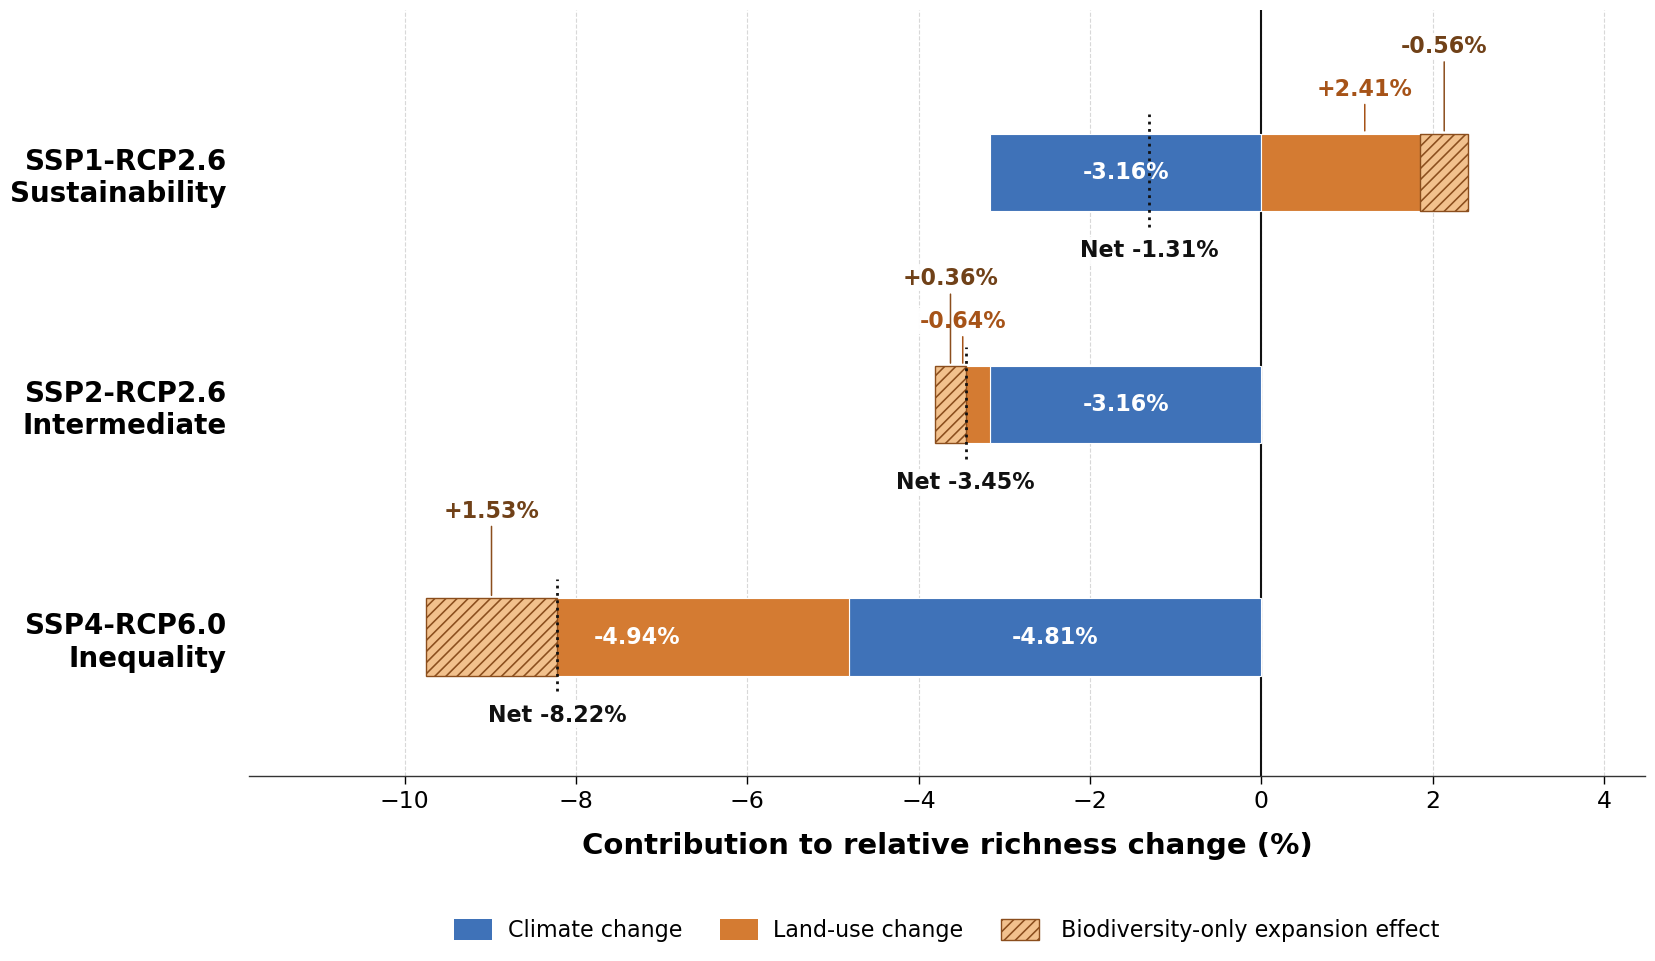


Outputs saved successfully:
  PNG:  /capacity/occr_davin/mguzman/chari_P2_review/Global/New_results/Figures/F2_richness_contributions_biodiversity_only.png
  TIFF: /capacity/occr_davin/mguzman/chari_P2_review/Global/New_results/Figures/F2_richness_contributions_biodiversity_only.tiff
  PDF:  /capacity/occr_davin/mguzman/chari_P2_review/Global/New_results/Figures/F2_richness_contributions_biodiversity_only.pdf
  CSV:  /capacity/occr_davin/mguzman/chari_P2_review/Global/New_results/Figures/F2_richness_contributions_biodiversity_only.csv


In [10]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Create a contribution plot showing the area-weighted contributions of:

    1. Climate change
    2. Land-use change
    3. Additional effect of biodiversity-only PA expansion
       from 17% to 30%

The decomposition is calculated relative to the harmonized historical
2015 ensemble:

    Climate contribution
        = Climate-only 2080 - Historical 2015

    Land-use contribution
        = PA17 complete retention 2080 - Climate-only 2080

    PA-expansion contribution
        = PA30 biodiversity-only complete retention 2080
          - PA17 complete retention 2080

Each component is expressed as a percentage of the area-weighted
historical 2015 richness estimate.

The three components sum exactly to:

    PA30 biodiversity-only 2080 - Historical 2015

Interpretation of the land-use components:

    Solid orange
        = projected land-use contribution under the existing
          17% PA network

    Hatched pale orange
        = additional land-use-mediated contribution associated
          with PA expansion from 17% to 30%

    Solid orange + hatched pale orange
        = total land-use-mediated contribution under the 30%
          biodiversity-only PA configuration

Visual conventions:

    - Blue represents climate change.
    - Solid orange represents land-use change.
    - Hatched pale orange represents the additional effect of
      PA expansion.
    - Internal numerical labels are white.
    - External labels and connector lines use component-matched colors.
    - Dotted black markers show net projected changes.
    - Component names are shown only in the legend to avoid repetition.

Outputs:

    - PNG at 600 dpi
    - TIFF with LZW compression at 600 dpi
    - PDF with embedded fonts and vector text/bar elements
    - CSV containing the plotted values
"""

import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from matplotlib.patches import Patch


warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
)


# =====================================================================
# 1. PATHS
# =====================================================================

BASE_PATH = (
    "/capacity/occr_davin/mguzman/chari_P2_review/"
    "Global/PA_scenarios/Sumprob_revised"
)

ENSEMBLE_ROOT = os.path.join(
    BASE_PATH,
    "Ensembles",
)

HIST_FILE = os.path.join(
    ENSEMBLE_ROOT,
    "Historical",
    "total_richness_historical_2015_ensemble.nc",
)

CLIMATE_ONLY_DIR = os.path.join(
    ENSEMBLE_ROOT,
    "Climate_Only",
)

PA17_DIR = os.path.join(
    ENSEMBLE_ROOT,
    "PA17",
    "complete",
)

PA30_BIO_DIR = os.path.join(
    ENSEMBLE_ROOT,
    "PA30_Bio",
    "complete",
)

OUTPUT_DIR = (
    "/capacity/occr_davin/mguzman/chari_P2_review/Global/New_results/Figures"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True,
)

OUTPUT_PNG = os.path.join(
    OUTPUT_DIR,
    "F2_richness_contributions_biodiversity_only.png",
)

OUTPUT_TIFF = os.path.join(
    OUTPUT_DIR,
    "F2_richness_contributions_biodiversity_only.tiff",
)

OUTPUT_PDF = os.path.join(
    OUTPUT_DIR,
    "F2_richness_contributions_biodiversity_only.pdf",
)

OUTPUT_CSV = os.path.join(
    OUTPUT_DIR,
    "F2_richness_contributions_biodiversity_only.csv",
)


# =====================================================================
# 2. DATA SETTINGS
# =====================================================================

VARIABLE = "prob_clim_disp_luf"

REFERENCE_THRESHOLD = 0.01

YEAR_FUTURE = "2080"


# =====================================================================
# 3. SCENARIO SETTINGS
# =====================================================================

SCENARIOS = [
    "rcp26",
    "rcp45",
    "rcp60",
]

SCENARIO_LABELS = {
    "rcp26": (
        "SSP1-RCP2.6\n"
        "Sustainability"
    ),
    "rcp45": (
        "SSP2-RCP2.6\n"
        "Intermediate"
    ),
    "rcp60": (
        "SSP4-RCP6.0\n"
        "Inequality"
    ),
}


# =====================================================================
# 4. INPUT FILE FUNCTIONS
# =====================================================================

def climate_only_file(
    scenario,
):
    """
    Return one revised climate-only ensemble path.
    """

    filename = (
        f"total_richness_climate_only_"
        f"{scenario}_{YEAR_FUTURE}_ensemble.nc"
    )

    return os.path.join(
        CLIMATE_ONLY_DIR,
        filename,
    )


def pa17_file(
    scenario,
):
    """
    Return one revised PA17 complete-retention ensemble path.
    """

    filename = (
        f"total_richness_pa17_complete_"
        f"{scenario}_{YEAR_FUTURE}_ensemble.nc"
    )

    return os.path.join(
        PA17_DIR,
        filename,
    )


def pa30_bio_file(
    scenario,
):
    """
    Return one revised biodiversity-only PA30 ensemble path.
    """

    filename = (
        f"total_richness_pa30_bio_complete_"
        f"{scenario}_{YEAR_FUTURE}_ensemble.nc"
    )

    return os.path.join(
        PA30_BIO_DIR,
        filename,
    )


# =====================================================================
# 5. DATA-LOADING FUNCTIONS
# =====================================================================

def standardize_coordinates(
    data_array,
):
    """
    Standardize latitude and longitude coordinate names and ordering.
    """

    rename_dict = {}

    if (
        "latitude" in data_array.coords
        or "latitude" in data_array.dims
    ):
        rename_dict["latitude"] = "lat"

    if (
        "longitude" in data_array.coords
        or "longitude" in data_array.dims
    ):
        rename_dict["longitude"] = "lon"

    if rename_dict:
        data_array = data_array.rename(
            rename_dict
        )

    if (
        "lat" not in data_array.coords
        or "lon" not in data_array.coords
    ):
        raise ValueError(
            "The input does not contain recognizable "
            "latitude and longitude coordinates."
        )

    if float(
        data_array["lon"].max()
    ) > 180:

        data_array = data_array.assign_coords(
            lon=(
                (
                    data_array["lon"]
                    + 180
                )
                % 360
            )
            - 180
        )

    return (
        data_array
        .sortby("lon")
        .sortby("lat")
    )


def load_richness(
    file_path,
):
    """
    Load and validate one richness ensemble.
    """

    if not os.path.isfile(
        file_path
    ):
        raise FileNotFoundError(
            f"Input file not found:\n{file_path}"
        )

    if os.path.getsize(
        file_path
    ) == 0:
        raise ValueError(
            f"Input file is empty:\n{file_path}"
        )

    with xr.open_dataset(
        file_path,
        decode_times=False,
    ) as dataset:

        if VARIABLE not in dataset.data_vars:
            raise KeyError(
                f"Variable {VARIABLE!r} was not found in:\n"
                f"{file_path}\n"
                f"Available variables: "
                f"{list(dataset.data_vars)}"
            )

        richness = (
            dataset[VARIABLE]
            .squeeze(drop=True)
            .load()
        )

    richness = standardize_coordinates(
        richness
    )

    richness = richness.astype(
        np.float64
    )

    finite_values = richness.values[
        np.isfinite(
            richness.values
        )
    ]

    if finite_values.size == 0:

        raise ValueError(
            f"No finite richness values were found in:\n"
            f"{file_path}"
        )

    if not np.any(
        finite_values > 0
    ):

        raise ValueError(
            f"No positive richness values were found in:\n"
            f"{file_path}"
        )

    return richness


def align_exact(
    first,
    second,
    description,
):
    """
    Validate that two arrays use identical coordinates.
    """

    try:

        first_aligned, second_aligned = xr.align(
            first,
            second,
            join="exact",
        )

    except ValueError as error:

        raise ValueError(
            f"Grid mismatch while comparing {description}."
        ) from error

    return (
        first_aligned,
        second_aligned,
    )


# =====================================================================
# 6. AREA-WEIGHTED MEANS
# =====================================================================

def create_area_weights(
    template,
):
    """
    Create latitude-based grid-cell weights.

    On a regular longitude-latitude grid, grid-cell area is
    proportional to cos(latitude).
    """

    latitude_weights = np.cos(
        np.deg2rad(
            template["lat"]
        )
    )

    latitude_weights = xr.DataArray(
        latitude_weights,
        coords={
            "lat": template["lat"],
        },
        dims=[
            "lat",
        ],
        name="latitude_weight",
    )

    weights_2d = latitude_weights.broadcast_like(
        template
    )

    return weights_2d.astype(
        np.float64
    )


def get_weighted_mean(
    data_array,
    weights,
    analysis_mask,
):
    """
    Calculate an area-weighted global mean over a common domain.
    """

    data_array, weights = align_exact(
        data_array,
        weights,
        "richness and area weights",
    )

    data_array, analysis_mask = align_exact(
        data_array,
        analysis_mask,
        "richness and analysis mask",
    )

    valid_mask = (
        analysis_mask
        & np.isfinite(data_array)
    )

    valid_data = data_array.where(
        valid_mask
    )

    valid_weights = weights.where(
        valid_mask
    )

    denominator = valid_weights.sum(
        dim=[
            "lat",
            "lon",
        ],
        skipna=True,
    )

    denominator_value = float(
        denominator.item()
    )

    if (
        not np.isfinite(
            denominator_value
        )
        or denominator_value <= 0
    ):

        raise ValueError(
            "The weighted-mean denominator is zero or invalid."
        )

    numerator = (
        valid_data
        * valid_weights
    ).sum(
        dim=[
            "lat",
            "lon",
        ],
        skipna=True,
    )

    weighted_mean = (
        numerator
        / denominator
    )

    weighted_mean_value = float(
        weighted_mean.item()
    )

    if not np.isfinite(
        weighted_mean_value
    ):

        raise ValueError(
            "The area-weighted mean is not finite."
        )

    return weighted_mean_value


# =====================================================================
# 7. LOAD HISTORICAL DATA
# =====================================================================

print(
    "Loading historical ensemble:"
)

print(
    f"  {HIST_FILE}"
)

historical = load_richness(
    HIST_FILE
)


# Use the same historical analysis domain for every experiment.

ANALYSIS_MASK = (
    np.isfinite(historical)
    & (
        historical
        > REFERENCE_THRESHOLD
    )
)


analysis_cell_count = int(
    ANALYSIS_MASK.sum().item()
)

if analysis_cell_count == 0:

    raise ValueError(
        "The common historical analysis mask contains no valid cells."
    )


area_weights = create_area_weights(
    historical
)


historical_mean = get_weighted_mean(
    data_array=historical,
    weights=area_weights,
    analysis_mask=ANALYSIS_MASK,
)


print(
    f"Historical analysis cells: "
    f"{analysis_cell_count:,}"
)

print(
    f"Area-weighted historical richness: "
    f"{historical_mean:.6f}"
)


# =====================================================================
# 8. CALCULATE CONTRIBUTIONS
# =====================================================================

results = []


for scenario in SCENARIOS:

    climate_path = climate_only_file(
        scenario
    )

    pa17_path = pa17_file(
        scenario
    )

    pa30_path = pa30_bio_file(
        scenario
    )


    print("")
    print(
        f"Loading scenario: {scenario}"
    )

    print(
        f"  Climate only: {climate_path}"
    )

    print(
        f"  Existing 17%-PA network: {pa17_path}"
    )

    print(
        f"  Biodiversity-only 30%-PA expansion: "
        f"{pa30_path}"
    )


    climate_only = load_richness(
        climate_path
    )

    pa17 = load_richness(
        pa17_path
    )

    pa30_bio = load_richness(
        pa30_path
    )


    climate_only, historical_aligned = align_exact(
        climate_only,
        historical,
        f"climate-only and historical data for {scenario}",
    )

    pa17, climate_only = align_exact(
        pa17,
        climate_only,
        f"PA17 and climate-only data for {scenario}",
    )

    pa30_bio, pa17 = align_exact(
        pa30_bio,
        pa17,
        f"PA30 and PA17 data for {scenario}",
    )


    climate_mean = get_weighted_mean(
        data_array=climate_only,
        weights=area_weights,
        analysis_mask=ANALYSIS_MASK,
    )

    pa17_mean = get_weighted_mean(
        data_array=pa17,
        weights=area_weights,
        analysis_mask=ANALYSIS_MASK,
    )

    pa30_mean = get_weighted_mean(
        data_array=pa30_bio,
        weights=area_weights,
        analysis_mask=ANALYSIS_MASK,
    )


    climate_contribution = (
        (
            climate_mean
            - historical_mean
        )
        / historical_mean
    ) * 100.0


    land_use_contribution = (
        (
            pa17_mean
            - climate_mean
        )
        / historical_mean
    ) * 100.0


    pa_expansion_contribution = (
        (
            pa30_mean
            - pa17_mean
        )
        / historical_mean
    ) * 100.0


    total_land_use_contribution = (
        land_use_contribution
        + pa_expansion_contribution
    )


    net_change = (
        (
            pa30_mean
            - historical_mean
        )
        / historical_mean
    ) * 100.0


    component_sum = (
        climate_contribution
        + land_use_contribution
        + pa_expansion_contribution
    )


    closure_error = (
        component_sum
        - net_change
    )


    results.append(
        {
            "Scenario": scenario,
            "Label": SCENARIO_LABELS[
                scenario
            ],
            "Historical_mean": historical_mean,
            "Climate_only_mean": climate_mean,
            "PA17_mean": pa17_mean,
            "PA30_biodiversity_mean": pa30_mean,
            "Climate": climate_contribution,
            "Land_use_under_17PA": (
                land_use_contribution
            ),
            "PA_expansion_increment": (
                pa_expansion_contribution
            ),
            "Total_land_use_under_30PA": (
                total_land_use_contribution
            ),
            "Net_change": net_change,
            "Component_sum": component_sum,
            "Closure_error": closure_error,
        }
    )


df = pd.DataFrame(
    results
)


# =====================================================================
# 9. VALIDATE DECOMPOSITION
# =====================================================================

MAXIMUM_CLOSURE_ERROR = 1e-8


for _, row in df.iterrows():

    print("")
    print(
        f"{row['Scenario']}:"
    )

    print(
        f"  Climate contribution: "
        f"{row['Climate']:+.4f}%"
    )

    print(
        f"  Land-use contribution under 17% PA: "
        f"{row['Land_use_under_17PA']:+.4f}%"
    )

    print(
        f"  Additional PA-expansion contribution: "
        f"{row['PA_expansion_increment']:+.4f}%"
    )

    print(
        f"  Total land-use contribution under 30% PA: "
        f"{row['Total_land_use_under_30PA']:+.4f}%"
    )

    print(
        f"  Net change: "
        f"{row['Net_change']:+.4f}%"
    )

    print(
        f"  Closure error: "
        f"{row['Closure_error']:+.12f}"
    )


    if abs(
        row["Closure_error"]
    ) > MAXIMUM_CLOSURE_ERROR:

        raise ValueError(
            "The decomposition does not close for "
            f"{row['Scenario']}. "
            f"Closure error: {row['Closure_error']}"
        )


df.to_csv(
    OUTPUT_CSV,
    index=False,
    float_format="%.10f",
)


# =====================================================================
# 10. FIGURE SETTINGS
# =====================================================================

FIGURE_WIDTH = 19
FIGURE_HEIGHT = 10.5

OUTPUT_DPI = 600

BAR_HEIGHT = 0.50

SCENARIO_LABEL_SIZE = 20
AXIS_LABEL_SIZE = 21
AXIS_TICK_SIZE = 17
VALUE_LABEL_SIZE = 16
NET_LABEL_SIZE = 16
LEGEND_FONT_SIZE = 16


plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": [
            "Arial",
            "Helvetica",
            "DejaVu Sans",
        ],
        "font.size": 17,
        "axes.labelsize": AXIS_LABEL_SIZE,
        "xtick.labelsize": AXIS_TICK_SIZE,
        "ytick.labelsize": SCENARIO_LABEL_SIZE,
        "legend.fontsize": LEGEND_FONT_SIZE,
        "axes.linewidth": 0.8,
        "hatch.linewidth": 1.15,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "savefig.facecolor": "white",
        "savefig.edgecolor": "white",
    }
)


# =====================================================================
# 11. COLORS AND HATCH
# =====================================================================

# Bar fills.

COLORS = {
    "Climate": "#3F72B8",
    "Land_use": "#D47B32",
    "PA_expansion": "#F2C18D",
}


# Darker component-matched colors for external labels.

LABEL_COLORS = {
    "Climate": "#245493",
    "Land_use": "#A65318",
    "PA_expansion": "#704118",
}


# Component-matched connector colors.

CONNECTOR_COLORS = {
    "Climate": "#245493",
    "Land_use": "#A65318",
    "PA_expansion": "#8B4E1D",
}


# PA expansion is represented as a hatched land-use-related component.

PA_HATCH = "///"

PA_EDGE_COLOR = "#8B4E1D"

GRID_COLOR = "#B8B8B8"

NET_COLOR = "#111111"


# =====================================================================
# 12. NUMERICAL LABEL FUNCTIONS
# =====================================================================

def add_internal_value(
    axis,
    start,
    value,
    y_position,
):
    """
    Place a numerical value inside a sufficiently wide segment.

    Internal labels remain white for contrast against the colored fills.
    Component identity is communicated by color, hatching, and legend.
    """

    midpoint = (
        start
        + value / 2.0
    )

    axis.text(
        midpoint,
        y_position,
        f"{value:+.2f}%",
        ha="center",
        va="center",
        fontsize=VALUE_LABEL_SIZE,
        fontweight="semibold",
        color="#FFFFFF",
        zorder=10,
    )


def add_external_value(
    axis,
    start,
    value,
    y_position,
    component,
    vertical_level,
):
    """
    Place a numerical value outside a narrow segment.

    External font and connector colors match the component:

        dark blue
            climate

        dark orange
            land-use change

        dark brown
            additional PA-expansion effect

    Separate vertical levels reduce overlap between land-use and
    PA-expansion values.
    """

    midpoint = (
        start
        + value / 2.0
    )


    if vertical_level == 1:

        label_y = (
            y_position
            + BAR_HEIGHT * 0.93
        )


    elif vertical_level == 2:

        label_y = (
            y_position
            + BAR_HEIGHT * 1.48
        )


    else:

        raise ValueError(
            f"Unsupported label level: {vertical_level}"
        )


    axis.annotate(
        f"{value:+.2f}%",
        xy=(
            midpoint,
            y_position
            + BAR_HEIGHT / 2.0
        ),
        xytext=(
            midpoint,
            label_y
        ),
        ha="center",
        va="bottom",
        fontsize=VALUE_LABEL_SIZE,
        fontweight="bold",
        color=LABEL_COLORS[
            component
        ],
        arrowprops={
            "arrowstyle": "-",
            "color": CONNECTOR_COLORS[
                component
            ],
            "linewidth": 1.1,
            "shrinkA": 2,
            "shrinkB": 2,
        },
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.94,
            "pad": 1.0,
        },
        zorder=12,
        annotation_clip=False,
    )


def label_climate_value(
    axis,
    start,
    value,
    y_position,
):
    """
    Label the climate contribution numerically.
    """

    if abs(
        value
    ) >= 2.3:

        add_internal_value(
            axis=axis,
            start=start,
            value=value,
            y_position=y_position,
        )


    else:

        add_external_value(
            axis=axis,
            start=start,
            value=value,
            y_position=y_position,
            component="Climate",
            vertical_level=1,
        )


def label_land_use_value(
    axis,
    start,
    value,
    y_position,
):
    """
    Label the solid land-use contribution numerically.
    """

    if abs(
        value
    ) >= 2.6:

        add_internal_value(
            axis=axis,
            start=start,
            value=value,
            y_position=y_position,
        )


    else:

        add_external_value(
            axis=axis,
            start=start,
            value=value,
            y_position=y_position,
            component="Land_use",
            vertical_level=1,
        )


def label_pa_value(
    axis,
    start,
    value,
    y_position,
):
    """
    Label the hatched PA-expansion contribution numerically.

    The PA-expansion value is always placed externally because those
    segments are generally narrow. Dark-brown text and connectors match
    the hatch outline.
    """

    add_external_value(
        axis=axis,
        start=start,
        value=value,
        y_position=y_position,
        component="PA_expansion",
        vertical_level=2,
    )


# =====================================================================
# 13. PLOTTING
# =====================================================================

fig, axis = plt.subplots(
    figsize=(
        FIGURE_WIDTH,
        FIGURE_HEIGHT,
    ),
    facecolor="white",
)


# Top-to-bottom order:
# SSP1, SSP2, SSP4.

y_positions = np.array(
    [
        3.0,
        1.5,
        0.0,
    ]
)


for row_index, row in df.iterrows():

    y_position = y_positions[
        row_index
    ]


    climate_value = float(
        row["Climate"]
    )

    land_use_value = float(
        row["Land_use_under_17PA"]
    )

    pa_value = float(
        row["PA_expansion_increment"]
    )

    net_value = float(
        row["Net_change"]
    )


    # -----------------------------------------------------------------
    # Climate contribution
    # -----------------------------------------------------------------

    climate_start = 0.0


    axis.barh(
        y=y_position,
        width=climate_value,
        left=climate_start,
        height=BAR_HEIGHT,
        color=COLORS["Climate"],
        edgecolor="white",
        linewidth=0.8,
        zorder=3,
    )


    label_climate_value(
        axis=axis,
        start=climate_start,
        value=climate_value,
        y_position=y_position,
    )


    # -----------------------------------------------------------------
    # Land-use contribution under the existing 17% PA network
    #
    # Retain the zero-anchored display logic:
    #
    #     negative land-use contributions follow a negative
    #     climate contribution;
    #
    #     positive land-use contributions begin at zero.
    # -----------------------------------------------------------------

    land_use_start = (
        climate_value
        if land_use_value < 0
        else 0.0
    )


    axis.barh(
        y=y_position,
        width=land_use_value,
        left=land_use_start,
        height=BAR_HEIGHT,
        color=COLORS["Land_use"],
        edgecolor="white",
        linewidth=0.8,
        zorder=3,
    )


    label_land_use_value(
        axis=axis,
        start=land_use_start,
        value=land_use_value,
        y_position=y_position,
    )


    # -----------------------------------------------------------------
    # Additional PA-expansion contribution
    #
    # The pale-orange fill and hatch show that this is an additional
    # land-use-mediated effect rather than an independent driver.
    # -----------------------------------------------------------------

    pa_start = (
        land_use_start
        + land_use_value
    )


    axis.barh(
        y=y_position,
        width=pa_value,
        left=pa_start,
        height=BAR_HEIGHT,
        color=COLORS["PA_expansion"],
        edgecolor=PA_EDGE_COLOR,
        linewidth=1.0,
        hatch=PA_HATCH,
        zorder=4,
    )


    label_pa_value(
        axis=axis,
        start=pa_start,
        value=pa_value,
        y_position=y_position,
    )


    # -----------------------------------------------------------------
    # Net-change marker and label
    # -----------------------------------------------------------------

    axis.vlines(
        x=net_value,
        ymin=(
            y_position
            - BAR_HEIGHT * 0.70
        ),
        ymax=(
            y_position
            + BAR_HEIGHT * 0.75
        ),
        color=NET_COLOR,
        linestyle=":",
        linewidth=2.0,
        zorder=8,
    )


    axis.text(
        net_value,
        y_position
        - BAR_HEIGHT * 0.86,
        f"Net {net_value:+.2f}%",
        ha="center",
        va="top",
        fontsize=NET_LABEL_SIZE,
        fontweight="bold",
        color=NET_COLOR,
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.92,
            "pad": 1.4,
        },
        zorder=13,
    )


# =====================================================================
# 14. DETERMINE AXIS LIMITS
# =====================================================================

plotted_values = [
    0.0,
]


for _, row in df.iterrows():

    climate_value = float(
        row["Climate"]
    )

    land_use_value = float(
        row["Land_use_under_17PA"]
    )

    pa_value = float(
        row["PA_expansion_increment"]
    )

    net_value = float(
        row["Net_change"]
    )


    land_use_start = (
        climate_value
        if land_use_value < 0
        else 0.0
    )


    pa_start = (
        land_use_start
        + land_use_value
    )


    plotted_values.extend(
        [
            climate_value,
            land_use_start,
            land_use_start
            + land_use_value,
            pa_start,
            pa_start
            + pa_value,
            net_value,
        ]
    )


minimum_value = min(
    plotted_values
)

maximum_value = max(
    plotted_values
)

data_range = (
    maximum_value
    - minimum_value
)

if data_range <= 0:

    data_range = 1.0


horizontal_margin = max(
    1.5,
    data_range * 0.17,
)


axis.set_xlim(
    minimum_value
    - horizontal_margin,
    maximum_value
    + horizontal_margin,
)


axis.set_ylim(
    y_positions.min()
    - 0.90,
    y_positions.max()
    + 1.05,
)


# =====================================================================
# 15. AXIS APPEARANCE
# =====================================================================

axis.axvline(
    x=0,
    color="#111111",
    linewidth=1.5,
    zorder=2,
)


axis.set_yticks(
    y_positions
)


axis.set_yticklabels(
    df["Label"],
    fontsize=SCENARIO_LABEL_SIZE,
    fontweight="semibold",
)


axis.set_xlabel(
    "Contribution to relative richness change (%)",
    fontsize=AXIS_LABEL_SIZE,
    fontweight="semibold",
    labelpad=14,
)


axis.tick_params(
    axis="x",
    labelsize=AXIS_TICK_SIZE,
    width=1.0,
    length=6,
)


axis.tick_params(
    axis="y",
    length=0,
    pad=16,
)


axis.grid(
    axis="x",
    linestyle="--",
    linewidth=0.8,
    color=GRID_COLOR,
    alpha=0.55,
    zorder=0,
)


axis.spines["top"].set_visible(
    False
)

axis.spines["right"].set_visible(
    False
)

axis.spines["left"].set_visible(
    False
)

axis.spines["bottom"].set_color(
    "#333333"
)

axis.spines["bottom"].set_linewidth(
    1.0
)


# =====================================================================
# 16. LEGEND
# =====================================================================

legend_elements = [
    Patch(
        facecolor=COLORS["Climate"],
        edgecolor="none",
        label="Climate change",
    ),
    Patch(
        facecolor=COLORS["Land_use"],
        edgecolor="none",
        label="Land-use change",
    ),
    Patch(
        facecolor=COLORS["PA_expansion"],
        edgecolor=PA_EDGE_COLOR,
        linewidth=1.0,
        hatch=PA_HATCH,
        label=" Biodiversity-only expansion effect",
    ),
]


axis.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        -0.16,
    ),
    ncol=3,
    frameon=False,
    fontsize=LEGEND_FONT_SIZE,
    handlelength=1.7,
    handleheight=1.1,
    handletextpad=0.7,
    columnspacing=1.7,
)


plt.subplots_adjust(
    left=0.25,
    right=0.985,
    top=0.98,
    bottom=0.25,
)


# =====================================================================
# 17. SAVE OUTPUTS
# =====================================================================

png_metadata = {
    "Title": (
        "Contributions of climate, land-use change, and "
        "biodiversity-only PA expansion to projected richness change"
    ),
    "Description": (
        "Area-weighted decomposition of projected vertebrate richness "
        "change into climate, land-use, and additional PA-expansion "
        "components."
    ),
}


pdf_metadata = {
    "Title": (
        "Contributions of climate, land-use change, and "
        "biodiversity-only PA expansion to projected richness change"
    ),
    "Subject": (
        "Area-weighted decomposition of projected vertebrate richness "
        "change into climate, land-use, and additional PA-expansion "
        "components."
    ),
}


fig.savefig(
    OUTPUT_PNG,
    dpi=OUTPUT_DPI,
    bbox_inches="tight",
    pad_inches=0.08,
    facecolor="white",
    edgecolor="white",
    transparent=False,
    metadata=png_metadata,
)


fig.savefig(
    OUTPUT_TIFF,
    format="tiff",
    dpi=OUTPUT_DPI,
    bbox_inches="tight",
    pad_inches=0.08,
    facecolor="white",
    edgecolor="white",
    transparent=False,
    pil_kwargs={
        "compression": "tiff_lzw",
    },
)


fig.savefig(
    OUTPUT_PDF,
    format="pdf",
    dpi=OUTPUT_DPI,
    bbox_inches="tight",
    pad_inches=0.08,
    facecolor="white",
    edgecolor="white",
    transparent=False,
    metadata=pdf_metadata,
)


plt.show()

# For non-interactive cluster execution, replace plt.show() with:
# plt.close(fig)


print("")
print(
    "Outputs saved successfully:"
)

print(
    f"  PNG:  {OUTPUT_PNG}"
)

print(
    f"  TIFF: {OUTPUT_TIFF}"
)

print(
    f"  PDF:  {OUTPUT_PDF}"
)

print(
    f"  CSV:  {OUTPUT_CSV}"
)

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Quantify uncertainty in the contributions of climate change, land-use
change, and biodiversity-only protected-area expansion to projected
vertebrate richness change.

The script uses the revised taxon-specific summed-probability files
generated under:

    Sumprob_revised/

For each scenario and ensemble-member configuration, the contributions
are calculated as:

    Climate contribution
        = Climate-only 2080 - Historical 2015

    Land-use contribution under the existing 17% PA network
        = PA17 complete retention 2080 - Climate-only 2080

    Additional PA-expansion contribution
        = PA30 biodiversity-only complete retention 2080
          - PA17 complete retention 2080

All contributions are expressed as percentages of the area-weighted
historical richness estimate for the corresponding SDM configuration.

The components close algebraically:

    Climate
    + Land use under 17% PA
    + Additional PA expansion
    = PA30 biodiversity-only 2080 - Historical 2015

Model availability:
    - Amphibians: GAM and GBM
    - Mammals: GAM and GBM
    - Birds: GAM oand GBM

Each configuration is paired with four GCMs, producing eight
ensemble-member estimates per scenario.

Outputs:
    1. Scenario-level summary CSV
    2. Printed summary table
"""

import os
import warnings

import numpy as np
import pandas as pd
import xarray as xr


warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
)


# =====================================================================
# 1. PATHS
# =====================================================================

BASE_PATH = (
    "/capacity/occr_davin/mguzman/chari_P2_review/"
    "Global/PA_scenarios/Sumprob_revised"
)

HISTORICAL_DIR = os.path.join(
    BASE_PATH,
    "WDPA",
    "Historical",
)

CLIMATE_ONLY_DIR = os.path.join(
    BASE_PATH,
    "WDPA",
    "Climate_Only",
)

PA17_DIR = os.path.join(
    BASE_PATH,
    "PA17",
    "complete",
)

PA30_BIO_DIR = os.path.join(
    BASE_PATH,
    "PA30_Bio",
    "complete",
)

OUTPUT_DIR = os.path.join(
    BASE_PATH,
    "Analysis",
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True,
)


SUMMARY_OUTPUT_CSV = os.path.join(
    OUTPUT_DIR,
    "richness_contributions_summary_biodiversity_only.csv",
)


# =====================================================================
# 2. DATA SETTINGS
# =====================================================================

VARIABLE = "prob_clim_disp_luf"

REFERENCE_THRESHOLD = 0.01

HISTORICAL_GCM_LABEL = "EWEMBI"

HISTORICAL_YEAR = "2015"

FUTURE_YEAR = "2080"

MAXIMUM_CLOSURE_ERROR = 1e-8


# =====================================================================
# 3. TAXON AND MODEL SETTINGS
# =====================================================================

TAXA = [
    "Amphibians",
    "Bird",
    "Mammals",
]

GCMS = [
    "GFDL-ESM2M",
    "IPSL-CM5A-LR",
    "HadGEM2-ES",
    "MIROC5",
]

SDM_CONFIGURATIONS = {
    "GAM": {
        "Amphibians": "GAM",
        "Bird": "GAM",
        "Mammals": "GAM",
    },
    "GBM_Amphibians_Mammals_GAM_Bird": {
        "Amphibians": "GBM",
        "Bird": "GBM",
        "Mammals": "GBM",
    },
}


# =====================================================================
# 4. SCENARIO SETTINGS
# =====================================================================

SCENARIOS = [
    "rcp26",
    "rcp45",
    "rcp60",
]

SCENARIO_NAMES = {
    "rcp26": "Sustainability",
    "rcp45": "Intermediate",
    "rcp60": "Inequality",
}

SCENARIO_DESCRIPTIONS = {
    "rcp26": "SSP1–RCP2.6",
    "rcp45": "SSP2 land use–RCP2.6 climate",
    "rcp60": "SSP4–RCP6.0",
}


# =====================================================================
# 5. FILE-PATH FUNCTIONS
# =====================================================================

def historical_file(
    taxon,
    sdm,
):
    """
    Return one revised raw historical summed-probability file.
    """

    filename = (
        f"summed_prob_{taxon}_{sdm}_"
        f"{HISTORICAL_GCM_LABEL}_"
        f"{HISTORICAL_YEAR}_baseline_2015.nc"
    )

    return os.path.join(
        HISTORICAL_DIR,
        filename,
    )


def climate_only_file(
    taxon,
    sdm,
    gcm,
    scenario,
):
    """
    Return one revised climate-only summed-probability file.
    """

    filename = (
        f"summed_prob_{taxon}_{sdm}_{gcm}_"
        f"{scenario}_{FUTURE_YEAR}_climate_only.nc"
    )

    return os.path.join(
        CLIMATE_ONLY_DIR,
        filename,
    )


def pa17_file(
    taxon,
    sdm,
    gcm,
    scenario,
):
    """
    Return one revised PA17 complete-retention file.
    """

    filename = (
        f"summed_prob_{taxon}_{sdm}_{gcm}_"
        f"{scenario}_{FUTURE_YEAR}_pa17_complete.nc"
    )

    return os.path.join(
        PA17_DIR,
        filename,
    )


def pa30_bio_file(
    taxon,
    sdm,
    gcm,
    scenario,
):
    """
    Return one revised biodiversity-only PA30 complete-retention file.
    """

    filename = (
        f"summed_prob_{taxon}_{sdm}_{gcm}_"
        f"{scenario}_{FUTURE_YEAR}_pa30_bio_complete.nc"
    )

    return os.path.join(
        PA30_BIO_DIR,
        filename,
    )


# =====================================================================
# 6. DATA-LOADING FUNCTIONS
# =====================================================================

def standardize_coordinates(
    data_array,
):
    """
    Standardize latitude and longitude coordinate names and ordering.
    """

    rename_dict = {}

    if (
        "latitude" in data_array.coords
        or "latitude" in data_array.dims
    ):
        rename_dict["latitude"] = "lat"

    if (
        "longitude" in data_array.coords
        or "longitude" in data_array.dims
    ):
        rename_dict["longitude"] = "lon"

    if rename_dict:
        data_array = data_array.rename(
            rename_dict
        )

    if (
        "lat" not in data_array.coords
        or "lon" not in data_array.coords
    ):
        raise ValueError(
            "The input does not contain recognizable "
            "latitude and longitude coordinates."
        )

    if float(
        data_array["lon"].max()
    ) > 180:

        data_array = data_array.assign_coords(
            lon=(
                (
                    data_array["lon"]
                    + 180
                )
                % 360
            )
            - 180
        )

    return (
        data_array
        .sortby("lon")
        .sortby("lat")
    )


def load_variable(
    file_path,
):
    """
    Load and validate the selected richness variable.
    """

    if not os.path.isfile(
        file_path
    ):
        raise FileNotFoundError(
            f"Input file not found:\n{file_path}"
        )

    if os.path.getsize(
        file_path
    ) == 0:
        raise ValueError(
            f"Input file is empty:\n{file_path}"
        )

    with xr.open_dataset(
        file_path,
        decode_times=False,
    ) as dataset:

        if VARIABLE not in dataset.data_vars:
            raise KeyError(
                f"Variable {VARIABLE!r} was not found in:\n"
                f"{file_path}\n"
                f"Available variables: "
                f"{list(dataset.data_vars)}"
            )

        data_array = (
            dataset[VARIABLE]
            .squeeze(drop=True)
            .load()
        )

    data_array = standardize_coordinates(
        data_array
    )

    data_array = data_array.astype(
        np.float64
    )

    finite_values = data_array.values[
        np.isfinite(
            data_array.values
        )
    ]

    if finite_values.size == 0:

        raise ValueError(
            f"No finite values were found in:\n{file_path}"
        )

    if not np.any(
        finite_values > 0
    ):

        raise ValueError(
            f"No positive values were found in:\n{file_path}"
        )

    return data_array


def align_exact(
    first,
    second,
    description,
):
    """
    Validate that two arrays use exactly the same grid.
    """

    try:

        first_aligned, second_aligned = xr.align(
            first,
            second,
            join="exact",
        )

    except ValueError as error:

        raise ValueError(
            f"Grid mismatch while aligning {description}."
        ) from error

    return (
        first_aligned,
        second_aligned,
    )


def sum_taxon_files(
    file_paths,
    description,
):
    """
    Sum taxon-specific richness rasters into one vertebrate total.

    Every requested taxon file must exist and pass validation.
    """

    if not file_paths:

        raise ValueError(
            f"No files were provided for {description}."
        )

    combined = None

    for taxon, file_path in file_paths.items():

        taxon_data = load_variable(
            file_path
        )

        if combined is None:

            combined = taxon_data.copy(
                deep=True
            )

        else:

            combined, taxon_data = align_exact(
                combined,
                taxon_data,
                (
                    f"{description}: combined richness and "
                    f"{taxon}"
                ),
            )

            combined = (
                combined
                + taxon_data
            )

    combined = combined.astype(
        np.float64
    )

    finite_values = combined.values[
        np.isfinite(
            combined.values
        )
    ]

    if finite_values.size == 0:

        raise ValueError(
            f"No finite combined values were produced for "
            f"{description}."
        )

    if not np.any(
        finite_values > 0
    ):

        raise ValueError(
            f"No positive combined values were produced for "
            f"{description}."
        )

    return combined


# =====================================================================
# 7. AREA-WEIGHTED MEAN FUNCTIONS
# =====================================================================

def create_area_weights(
    template,
):
    """
    Create latitude-based grid-cell weights.

    For a regular longitude-latitude grid, grid-cell area is
    proportional to cos(latitude).
    """

    latitude_weights = np.cos(
        np.deg2rad(
            template["lat"]
        )
    )

    latitude_weights = xr.DataArray(
        latitude_weights,
        coords={
            "lat": template["lat"],
        },
        dims=[
            "lat",
        ],
        name="latitude_weight",
    )

    return latitude_weights.broadcast_like(
        template
    ).astype(
        np.float64
    )


def get_weighted_mean(
    data_array,
    weights,
    analysis_mask,
):
    """
    Calculate an area-weighted mean over a common analysis domain.
    """

    data_array, weights = align_exact(
        data_array,
        weights,
        "richness and area weights",
    )

    data_array, analysis_mask = align_exact(
        data_array,
        analysis_mask,
        "richness and analysis mask",
    )

    valid_mask = (
        analysis_mask
        & np.isfinite(data_array)
    )

    valid_data = data_array.where(
        valid_mask
    )

    valid_weights = weights.where(
        valid_mask
    )

    denominator = valid_weights.sum(
        dim=[
            "lat",
            "lon",
        ],
        skipna=True,
    )

    denominator_value = float(
        denominator.item()
    )

    if (
        not np.isfinite(
            denominator_value
        )
        or denominator_value <= 0
    ):

        raise ValueError(
            "The area-weight denominator is zero or invalid."
        )

    numerator = (
        valid_data
        * valid_weights
    ).sum(
        dim=[
            "lat",
            "lon",
        ],
        skipna=True,
    )

    weighted_mean = float(
        (
            numerator
            / denominator
        ).item()
    )

    if not np.isfinite(
        weighted_mean
    ):

        raise ValueError(
            "The area-weighted mean is not finite."
        )

    return weighted_mean


# =====================================================================
# 8. LOAD HISTORICAL CONFIGURATIONS
# =====================================================================

historical_by_configuration = {}

historical_mask_by_configuration = {}

weights_by_configuration = {}

historical_mean_by_configuration = {}


for (
    configuration_name,
    taxon_models,
) in SDM_CONFIGURATIONS.items():

    print("")
    print(
        "=" * 72
    )

    print(
        f"Loading historical SDM configuration: "
        f"{configuration_name}"
    )

    print(
        "=" * 72
    )


    historical_paths = {}

    for taxon in TAXA:

        sdm = taxon_models[
            taxon
        ]

        file_path = historical_file(
            taxon=taxon,
            sdm=sdm,
        )

        historical_paths[
            taxon
        ] = file_path

        print(
            f"  {taxon} | {sdm}: "
            f"{file_path}"
        )


    historical_total = sum_taxon_files(
        file_paths=historical_paths,
        description=(
            f"historical {configuration_name}"
        ),
    )


    analysis_mask = (
        np.isfinite(
            historical_total
        )
        & (
            historical_total
            > REFERENCE_THRESHOLD
        )
    )


    analysis_cell_count = int(
        analysis_mask.sum().item()
    )


    if analysis_cell_count == 0:

        raise ValueError(
            "No valid historical analysis cells were found for "
            f"{configuration_name}."
        )


    area_weights = create_area_weights(
        historical_total
    )


    historical_mean = get_weighted_mean(
        data_array=historical_total,
        weights=area_weights,
        analysis_mask=analysis_mask,
    )


    historical_by_configuration[
        configuration_name
    ] = historical_total


    historical_mask_by_configuration[
        configuration_name
    ] = analysis_mask


    weights_by_configuration[
        configuration_name
    ] = area_weights


    historical_mean_by_configuration[
        configuration_name
    ] = historical_mean


    print(
        f"  Valid historical cells: "
        f"{analysis_cell_count:,}"
    )

    print(
        f"  Area-weighted historical richness: "
        f"{historical_mean:.6f}"
    )


# =====================================================================
# 9. CALCULATE MEMBER-LEVEL CONTRIBUTIONS
# =====================================================================

member_results = []

skipped_members = []


for scenario in SCENARIOS:

    for (
        configuration_name,
        taxon_models,
    ) in SDM_CONFIGURATIONS.items():

        historical_total = (
            historical_by_configuration[
                configuration_name
            ]
        )

        analysis_mask = (
            historical_mask_by_configuration[
                configuration_name
            ]
        )

        area_weights = (
            weights_by_configuration[
                configuration_name
            ]
        )

        historical_mean = (
            historical_mean_by_configuration[
                configuration_name
            ]
        )


        for gcm in GCMS:

            member_label = (
                f"{scenario} | "
                f"{configuration_name} | "
                f"{gcm}"
            )

            print("")
            print(
                f"Processing member: {member_label}"
            )


            climate_paths = {}

            pa17_paths = {}

            pa30_paths = {}


            for taxon in TAXA:

                sdm = taxon_models[
                    taxon
                ]


                climate_paths[
                    taxon
                ] = climate_only_file(
                    taxon=taxon,
                    sdm=sdm,
                    gcm=gcm,
                    scenario=scenario,
                )


                pa17_paths[
                    taxon
                ] = pa17_file(
                    taxon=taxon,
                    sdm=sdm,
                    gcm=gcm,
                    scenario=scenario,
                )


                pa30_paths[
                    taxon
                ] = pa30_bio_file(
                    taxon=taxon,
                    sdm=sdm,
                    gcm=gcm,
                    scenario=scenario,
                )


            required_paths = (
                list(
                    climate_paths.values()
                )
                + list(
                    pa17_paths.values()
                )
                + list(
                    pa30_paths.values()
                )
            )


            missing_paths = [
                path
                for path in required_paths
                if not os.path.isfile(
                    path
                )
            ]


            if missing_paths:

                print(
                    "  WARNING: Member skipped because required "
                    "files are missing."
                )

                for missing_path in missing_paths:

                    print(
                        f"    Missing: {missing_path}"
                    )


                skipped_members.append(
                    {
                        "Scenario": scenario,
                        "SDM_configuration": (
                            configuration_name
                        ),
                        "GCM": gcm,
                        "Reason": (
                            "Missing one or more required files"
                        ),
                        "Missing_files": " | ".join(
                            missing_paths
                        ),
                    }
                )

                continue


            climate_total = sum_taxon_files(
                file_paths=climate_paths,
                description=(
                    f"climate-only {member_label}"
                ),
            )


            pa17_total = sum_taxon_files(
                file_paths=pa17_paths,
                description=(
                    f"PA17 {member_label}"
                ),
            )


            pa30_total = sum_taxon_files(
                file_paths=pa30_paths,
                description=(
                    f"PA30 biodiversity-only {member_label}"
                ),
            )


            climate_total, historical_aligned = align_exact(
                climate_total,
                historical_total,
                (
                    f"climate-only and historical data for "
                    f"{member_label}"
                ),
            )


            pa17_total, climate_total = align_exact(
                pa17_total,
                climate_total,
                (
                    f"PA17 and climate-only data for "
                    f"{member_label}"
                ),
            )


            pa30_total, pa17_total = align_exact(
                pa30_total,
                pa17_total,
                (
                    f"PA30 and PA17 data for "
                    f"{member_label}"
                ),
            )


            climate_mean = get_weighted_mean(
                data_array=climate_total,
                weights=area_weights,
                analysis_mask=analysis_mask,
            )


            pa17_mean = get_weighted_mean(
                data_array=pa17_total,
                weights=area_weights,
                analysis_mask=analysis_mask,
            )


            pa30_mean = get_weighted_mean(
                data_array=pa30_total,
                weights=area_weights,
                analysis_mask=analysis_mask,
            )


            climate_contribution = (
                (
                    climate_mean
                    - historical_mean
                )
                / historical_mean
            ) * 100.0


            land_use_contribution = (
                (
                    pa17_mean
                    - climate_mean
                )
                / historical_mean
            ) * 100.0


            pa_expansion_contribution = (
                (
                    pa30_mean
                    - pa17_mean
                )
                / historical_mean
            ) * 100.0


            total_land_use_contribution = (
                land_use_contribution
                + pa_expansion_contribution
            )


            net_change = (
                (
                    pa30_mean
                    - historical_mean
                )
                / historical_mean
            ) * 100.0


            component_sum = (
                climate_contribution
                + land_use_contribution
                + pa_expansion_contribution
            )


            closure_error = (
                component_sum
                - net_change
            )


            if abs(
                closure_error
            ) > MAXIMUM_CLOSURE_ERROR:

                raise ValueError(
                    "The decomposition does not close for "
                    f"{member_label}. "
                    f"Closure error: {closure_error}"
                )


            member_results.append(
                {
                    "Scenario": scenario,
                    "Scenario_name": (
                        SCENARIO_NAMES[
                            scenario
                        ]
                    ),
                    "Scenario_description": (
                        SCENARIO_DESCRIPTIONS[
                            scenario
                        ]
                    ),
                    "SDM_configuration": (
                        configuration_name
                    ),
                    "Amphibians_SDM": (
                        taxon_models[
                            "Amphibians"
                        ]
                    ),
                    "Bird_SDM": (
                        taxon_models[
                            "Bird"
                        ]
                    ),
                    "Mammals_SDM": (
                        taxon_models[
                            "Mammals"
                        ]
                    ),
                    "GCM": gcm,
                    "Historical_mean": historical_mean,
                    "Climate_only_mean": climate_mean,
                    "PA17_mean": pa17_mean,
                    "PA30_biodiversity_mean": (
                        pa30_mean
                    ),
                    "Climate_contribution": (
                        climate_contribution
                    ),
                    "Land_use_under_17PA": (
                        land_use_contribution
                    ),
                    "PA_expansion_increment": (
                        pa_expansion_contribution
                    ),
                    "Total_land_use_under_30PA": (
                        total_land_use_contribution
                    ),
                    "Net_change": net_change,
                    "Component_sum": component_sum,
                    "Closure_error": closure_error,
                }
            )


            print(
                f"  Climate: "
                f"{climate_contribution:+.4f}%"
            )

            print(
                f"  Land use under 17% PA: "
                f"{land_use_contribution:+.4f}%"
            )

            print(
                f"  Additional PA expansion: "
                f"{pa_expansion_contribution:+.4f}%"
            )

            print(
                f"  Total land use under 30% PA: "
                f"{total_land_use_contribution:+.4f}%"
            )

            print(
                f"  Net: "
                f"{net_change:+.4f}%"
            )


# =====================================================================
# 10. SUMMARY STATISTICS
# =====================================================================

SUMMARY_COMPONENTS = {
    "Climate": "Climate_contribution",
    "Land_use_17PA": "Land_use_under_17PA",
    "PA_expansion_increment": "PA_expansion_increment",
    "Total_land_use_30PA": "Total_land_use_under_30PA",
    "Net_change": "Net_change",
}


summary_rows = []


for scenario in SCENARIOS:

    scenario_data = member_df.loc[
        member_df["Scenario"]
        == scenario
    ]


    if scenario_data.empty:

        print(
            f"WARNING: No complete members found for {scenario}."
        )

        continue


    summary_row = {
        "Scenario": scenario,
        "Scenario_name": (
            SCENARIO_NAMES[
                scenario
            ]
        ),
        "Scenario_description": (
            SCENARIO_DESCRIPTIONS[
                scenario
            ]
        ),
    }


    for (
        output_name,
        column_name,
    ) in SUMMARY_COMPONENTS.items():

        values = scenario_data[
            column_name
        ].astype(float)


        sample_size = int(
            values.notna().sum()
        )


        mean_value = float(
            values.mean()
        )


        if sample_size > 1:

            standard_deviation = float(
                values.std(
                    ddof=1
                )
            )

            standard_error = float(
                values.sem(
                    ddof=1
                )
            )

        else:

            standard_deviation = np.nan

            standard_error = np.nan


        summary_row[
            f"{output_name}_Mean"
        ] = mean_value


        summary_row[
            f"{output_name}_SD"
        ] = standard_deviation


        summary_row[
            f"{output_name}_SE"
        ] = standard_error


        summary_row[
            f"{output_name}_N"
        ] = sample_size


    summary_rows.append(
        summary_row
    )


summary_df = pd.DataFrame(
    summary_rows
)


summary_df.to_csv(
    SUMMARY_OUTPUT_CSV,
    index=False,
    float_format="%.10f",
)


# =====================================================================
# 12. PRINT SUMMARY
# =====================================================================

display_columns = [
    "Scenario",
    "Climate_Mean",
    "Climate_SE",
    "Land_use_17PA_Mean",
    "Land_use_17PA_SE",
    "PA_expansion_increment_Mean",
    "PA_expansion_increment_SE",
    "Total_land_use_30PA_Mean",
    "Total_land_use_30PA_SE",
    "Net_change_Mean",
    "Net_change_SE",
]


print("")
print(
    "=" * 120
)

print(
    "SCENARIO-LEVEL CONTRIBUTION SUMMARY"
)

print(
    "=" * 120
)


with pd.option_context(
    "display.max_columns",
    None,
    "display.width",
    220,
    "display.float_format",
    "{:.4f}".format,
):

    print(
        summary_df[
            display_columns
        ].to_string(
            index=False
        )
    )


print("")
print(
    "Outputs saved successfully:"
)

print(
    f"  Scenario summaries: "
    f"{SUMMARY_OUTPUT_CSV}"
)


Loading historical SDM configuration: GAM
  Amphibians | GAM: /capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob_revised/WDPA/Historical/summed_prob_Amphibians_GAM_EWEMBI_2015_baseline_2015.nc
  Bird | GAM: /capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob_revised/WDPA/Historical/summed_prob_Bird_GAM_EWEMBI_2015_baseline_2015.nc
  Mammals | GAM: /capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob_revised/WDPA/Historical/summed_prob_Mammals_GAM_EWEMBI_2015_baseline_2015.nc
  Valid historical cells: 59,640
  Area-weighted historical richness: 150.361147

Loading historical SDM configuration: GBM_Amphibians_Mammals_GAM_Bird
  Amphibians | GBM: /capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob_revised/WDPA/Historical/summed_prob_Amphibians_GBM_EWEMBI_2015_baseline_2015.nc
  Bird | GAM: /capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob_revised/WDPA/Historical/summed_prob_Bird_GAM

Figure 3. Relative species richenss change per taxonomic group and PA configuration

Loading historical reference: Amphibians | GAM
  /capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob_revised/WDPA/Historical/summed_prob_Amphibians_GAM_EWEMBI_2015_baseline_2015.nc
  Valid cells: 58,598
  Historical mean: 11.000164
Loading historical reference: Amphibians | GBM
  /capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob_revised/WDPA/Historical/summed_prob_Amphibians_GBM_EWEMBI_2015_baseline_2015.nc
  Valid cells: 59,113
  Historical mean: 11.313250
Loading historical reference: Bird | GAM
  /capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob_revised/WDPA/Historical/summed_prob_Bird_GAM_EWEMBI_2015_baseline_2015.nc
  Valid cells: 59,639
  Historical mean: 104.463821
Loading historical reference: Mammals | GAM
  /capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob_revised/WDPA/Historical/summed_prob_Mammals_GAM_EWEMBI_2015_baseline_2015.nc
  Valid cells: 59,602
  Historical mean: 34.983634
Loadi

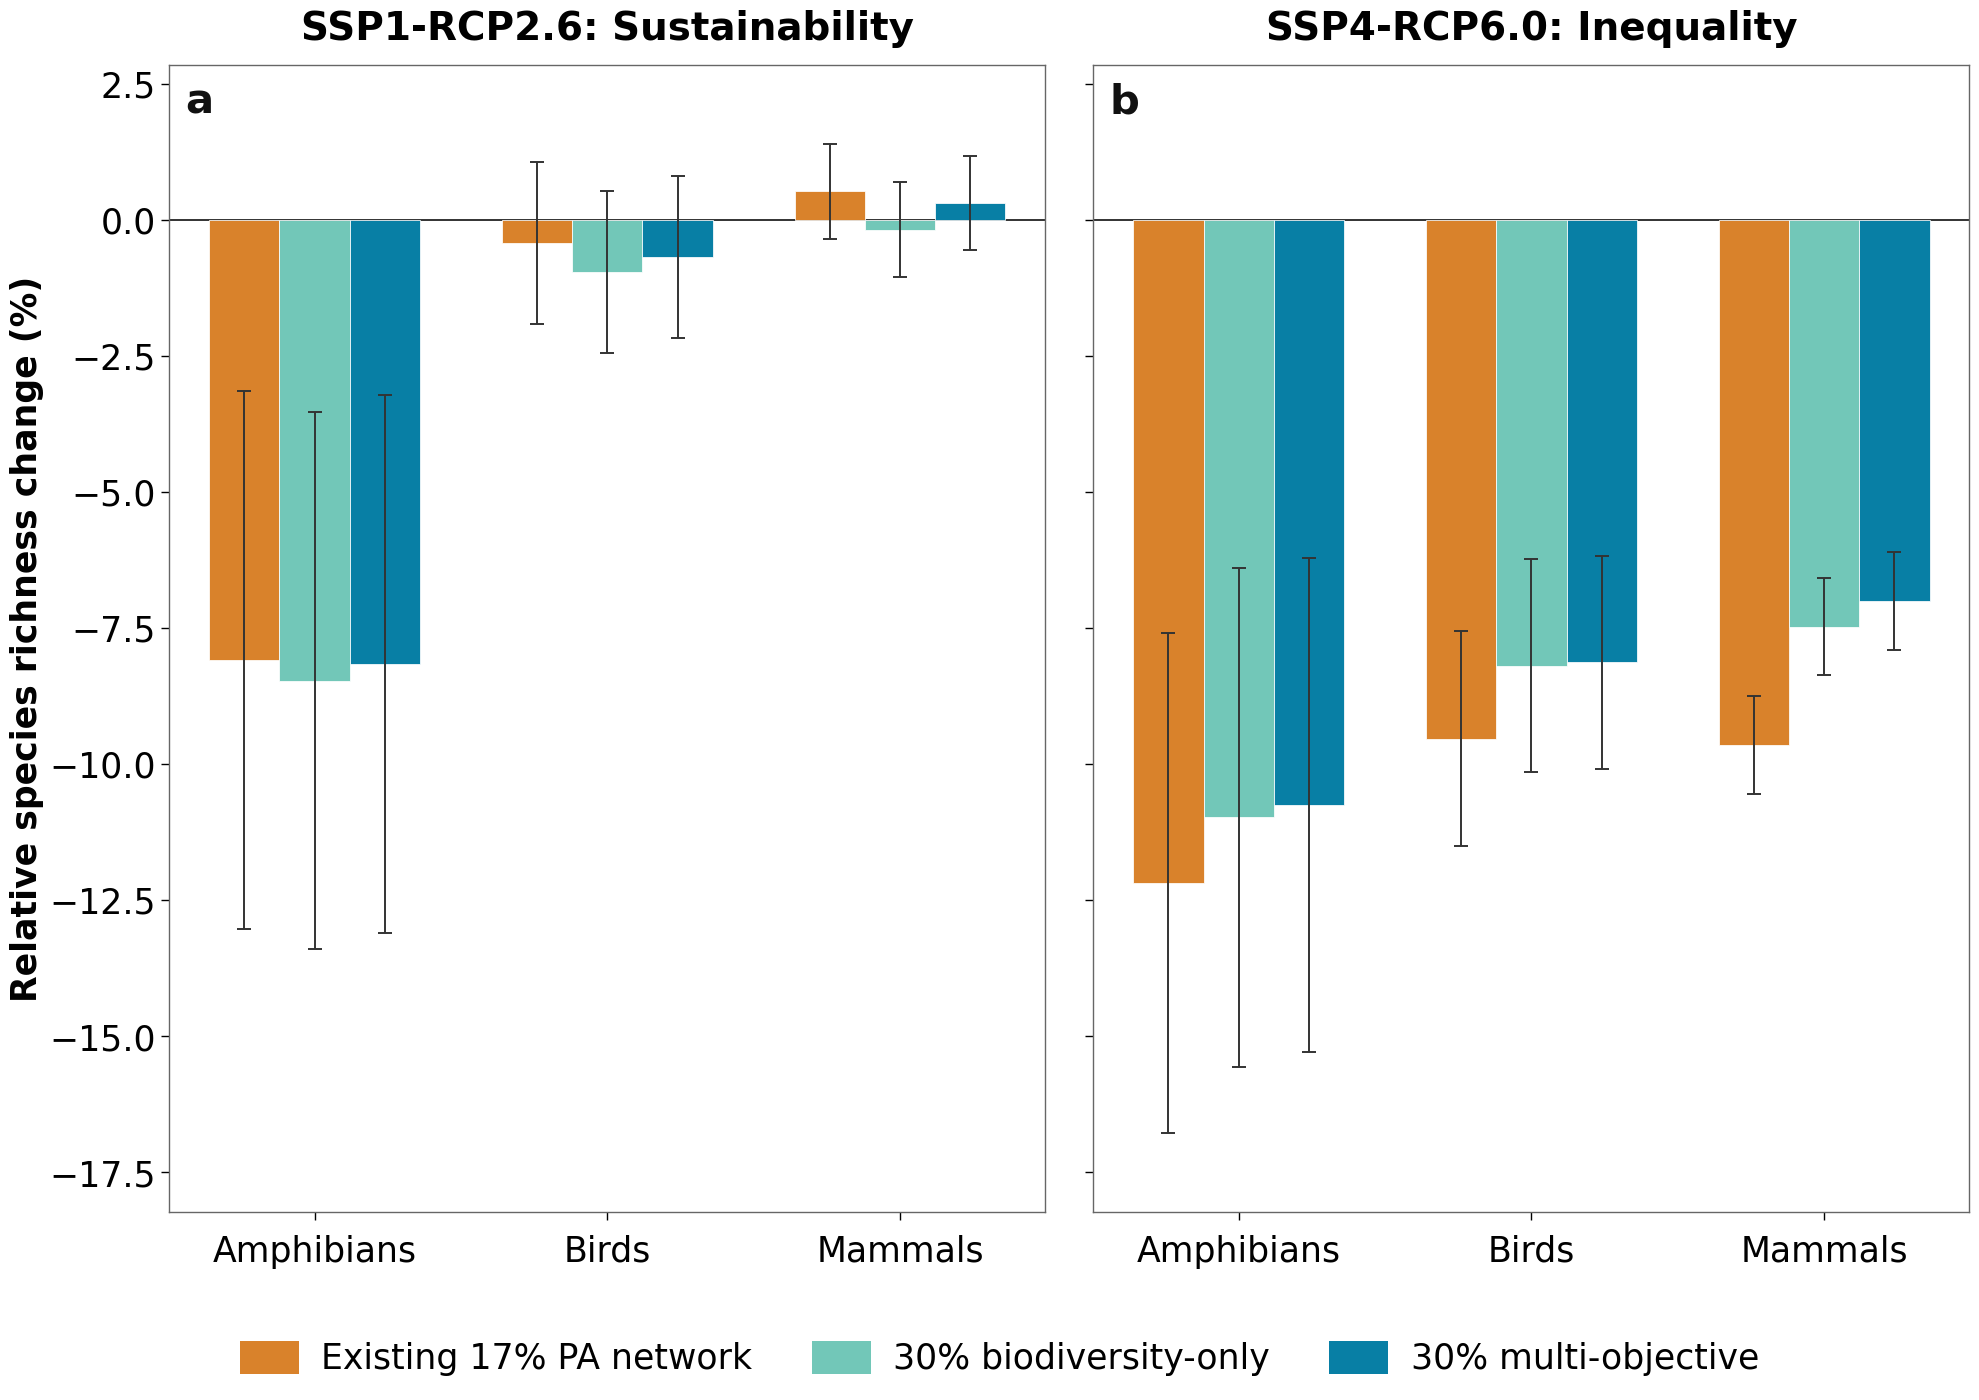


Outputs saved successfully:
  PDF:     /capacity/occr_davin/mguzman/chari_P2_review/Global/New_results/Figures/F3_taxon_specific_richness_full-eff.pdf
  SVG:     /capacity/occr_davin/mguzman/chari_P2_review/Global/New_results/Figures/F3_taxon_specific_richness_full-eff.svg
  PNG:     /capacity/occr_davin/mguzman/chari_P2_review/Global/New_results/Figures/F3_taxon_specific_richness_full-eff.png
  Summary: /capacity/occr_davin/mguzman/chari_P2_review/Global/New_results/Figures/F3_taxon_specific_richness_full-eff_summary.csv


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""Taxon-specific projected vertebrate-richness change.

Calculates area-weighted global changes relative to the matching historical
2015 reference for every available taxon, SDM, GCM, PA configuration and
scenario. Bars show the ensemble mean and error bars show +/- 1 sample SD.

"""

import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.patches import Patch

warnings.filterwarnings("ignore", category=RuntimeWarning)

# =====================================================================
# 1. PATHS
# =====================================================================

BASE_PATH = (
    "/capacity/occr_davin/mguzman/chari_P2_review/"
    "Global/PA_scenarios/Sumprob_revised"
)
HISTORICAL_DIR = os.path.join(BASE_PATH, "WDPA", "Historical")
FUTURE_DIRECTORIES = {
    "pa17": os.path.join(BASE_PATH, "PA17", "complete"),
    "pa30_bio": os.path.join(BASE_PATH, "PA30_Bio", "complete"),
    "pa30_bcw": os.path.join(BASE_PATH, "PA30_BCW", "complete"),
}
OUTPUT_DIR = (
    "/capacity/occr_davin/mguzman/chari_P2_review/"
    "Global/New_results/Figures"
)
os.makedirs(OUTPUT_DIR, exist_ok=True)

OUTPUT_PDF = os.path.join(
    OUTPUT_DIR,
    "F3_taxon_specific_richness_full-eff.pdf",
)
OUTPUT_SVG = os.path.join(
    OUTPUT_DIR,
    "F3_taxon_specific_richness_full-eff.svg",
)
OUTPUT_PNG = os.path.join(
    OUTPUT_DIR,
    "F3_taxon_specific_richness_full-eff.png",
)
OUTPUT_CSV = os.path.join(
    OUTPUT_DIR,
    "F3_taxon_specific_richness_full-eff_summary.csv",
)


# =====================================================================
# 2. DATA SETTINGS
# =====================================================================

VARIABLE = "prob_clim_disp_luf"
REFERENCE_THRESHOLD = 0.01
HISTORICAL_GCM_LABEL = "EWEMBI"
HISTORICAL_YEAR = "2015"
FUTURE_YEAR = "2080"
OUTPUT_DPI = 600

TAXA = ["Amphibians", "Bird", "Mammals"]
TAXON_LABELS = {
    "Amphibians": "Amphibians",
    "Bird": "Birds",
    "Mammals": "Mammals",
}
TAXON_SDMS = {
    "Amphibians": ["GAM", "GBM"],
    "Bird": ["GAM", "GBM"],
    "Mammals": ["GAM", "GBM"],
}
GCMS = [
    "GFDL-ESM2M",
    "IPSL-CM5A-LR",
    "HadGEM2-ES",
    "MIROC5",
]
SCENARIOS = ["rcp26", "rcp60"]
SCENARIO_TITLES = {
    "rcp26": "SSP1-RCP2.6: Sustainability",
    "rcp60": "SSP4-RCP6.0: Inequality",
}
PA_CONFIGURATIONS = {
    "pa17": {
        "label": "Existing 17% PA network",
        "filename_suffix": "pa17_complete",
    },
    "pa30_bio": {
        "label": "30% biodiversity-only",
        "filename_suffix": "pa30_bio_complete",
    },
    "pa30_bcw": {
        "label": "30% multi-objective",
        "filename_suffix": "pa30_bcw_complete",
    },
}
PA_ORDER = ["pa17", "pa30_bio", "pa30_bcw"]

# =====================================================================
# 3. FILE-PATH FUNCTIONS
# =====================================================================


def historical_file(taxon, sdm):
    """Return one historical taxon-SDM file."""
    filename = (
        f"summed_prob_{taxon}_{sdm}_{HISTORICAL_GCM_LABEL}_"
        f"{HISTORICAL_YEAR}_baseline_2015.nc"
    )
    return os.path.join(HISTORICAL_DIR, filename)


def future_file(taxon, sdm, gcm, scenario, pa_configuration):
    """Return one future complete-retention file."""
    suffix = PA_CONFIGURATIONS[pa_configuration]["filename_suffix"]
    filename = (
        f"summed_prob_{taxon}_{sdm}_{gcm}_{scenario}_"
        f"{FUTURE_YEAR}_{suffix}.nc"
    )
    return os.path.join(FUTURE_DIRECTORIES[pa_configuration], filename)

# =====================================================================
# 4. DATA HELPERS
# =====================================================================


def standardize_coordinates(data_array):
    """Standardize coordinate names and longitude convention."""
    rename_dictionary = {}
    if "latitude" in data_array.coords or "latitude" in data_array.dims:
        rename_dictionary["latitude"] = "lat"
    if "longitude" in data_array.coords or "longitude" in data_array.dims:
        rename_dictionary["longitude"] = "lon"
    if rename_dictionary:
        data_array = data_array.rename(rename_dictionary)
    if "lat" not in data_array.coords or "lon" not in data_array.coords:
        raise ValueError("Input lacks recognizable latitude/longitude coordinates.")
    if float(data_array["lon"].max()) > 180:
        data_array = data_array.assign_coords(
            lon=((data_array["lon"] + 180) % 360) - 180
        )
    return data_array.sortby("lon").sortby("lat")


def load_richness(file_path):
    """Load and validate one richness raster."""
    if not os.path.isfile(file_path):
        raise FileNotFoundError(f"Input file not found:\n{file_path}")
    if os.path.getsize(file_path) == 0:
        raise ValueError(f"Input file is empty:\n{file_path}")
    with xr.open_dataset(file_path, decode_times=False) as dataset:
        if VARIABLE not in dataset.data_vars:
            raise KeyError(
                f"Variable {VARIABLE!r} was not found in:\n{file_path}\n"
                f"Available variables: {list(dataset.data_vars)}"
            )
        richness = dataset[VARIABLE].squeeze(drop=True).load()
    richness = standardize_coordinates(richness).astype(np.float64)
    finite_values = richness.values[np.isfinite(richness.values)]
    if finite_values.size == 0:
        raise ValueError(f"No finite values were found in:\n{file_path}")
    if not np.any(finite_values > 0):
        raise ValueError(f"No positive values were found in:\n{file_path}")
    return richness


def align_exact(first, second, description):
    """Require identical coordinates."""
    try:
        return xr.align(first, second, join="exact")
    except ValueError as error:
        raise ValueError(f"Grid mismatch while aligning {description}.") from error


def create_area_weights(template):
    """Create area weights proportional to cosine of latitude."""
    latitude_weights = xr.DataArray(
        np.cos(np.deg2rad(template["lat"])),
        coords={"lat": template["lat"]},
        dims=["lat"],
    )
    return latitude_weights.broadcast_like(template).astype(np.float64)


def area_weighted_mean(data_array, weights, analysis_mask):
    """Calculate an area-weighted global mean over a common domain."""
    data_array, weights = align_exact(
        data_array, weights, "richness and area weights"
    )
    data_array, analysis_mask = align_exact(
        data_array, analysis_mask, "richness and historical mask"
    )
    valid_mask = analysis_mask & np.isfinite(data_array)
    valid_weights = weights.where(valid_mask)
    denominator = valid_weights.sum(dim=["lat", "lon"], skipna=True)
    denominator_value = float(denominator.item())
    if not np.isfinite(denominator_value) or denominator_value <= 0:
        raise ValueError("The area-weight denominator is zero or invalid.")
    numerator = (
        data_array.where(valid_mask) * valid_weights
    ).sum(dim=["lat", "lon"], skipna=True)
    weighted_mean = float((numerator / denominator).item())
    if not np.isfinite(weighted_mean):
        raise ValueError("The area-weighted mean is not finite.")
    return weighted_mean

# =====================================================================
# 5. HISTORICAL REFERENCES
# =====================================================================

historical_data = {}
historical_means = {}
historical_masks = {}
area_weights = {}
skipped_rows = []

for taxon in TAXA:
    historical_data[taxon] = {}
    historical_means[taxon] = {}
    historical_masks[taxon] = {}
    area_weights[taxon] = {}

    for sdm in TAXON_SDMS[taxon]:
        path = historical_file(taxon=taxon, sdm=sdm)
        print(f"Loading historical reference: {taxon} | {sdm}")
        print(f"  {path}")

        historical = load_richness(path)
        mask = np.isfinite(historical) & (historical > REFERENCE_THRESHOLD)
        valid_cells = int(mask.sum().item())
        if valid_cells == 0:
            raise ValueError(f"No valid historical cells for {taxon} | {sdm}.")

        weights = create_area_weights(historical)
        historical_mean = area_weighted_mean(
            data_array=historical,
            weights=weights,
            analysis_mask=mask,
        )

        historical_data[taxon][sdm] = historical
        historical_masks[taxon][sdm] = mask
        area_weights[taxon][sdm] = weights
        historical_means[taxon][sdm] = historical_mean

        print(f"  Valid cells: {valid_cells:,}")
        print(f"  Historical mean: {historical_mean:.6f}")

# =====================================================================
# 6. MEMBER-LEVEL FUTURE CHANGES
# =====================================================================

member_rows = []

for scenario in SCENARIOS:
    print("\n" + "=" * 72)
    print(f"Processing scenario: {scenario}")
    print("=" * 72)

    for taxon in TAXA:
        for sdm in TAXON_SDMS[taxon]:
            historical = historical_data[taxon][sdm]
            historical_mean = historical_means[taxon][sdm]
            mask = historical_masks[taxon][sdm]
            weights = area_weights[taxon][sdm]

            for gcm in GCMS:
                for pa_key in PA_ORDER:
                    path = future_file(
                        taxon=taxon,
                        sdm=sdm,
                        gcm=gcm,
                        scenario=scenario,
                        pa_configuration=pa_key,
                    )

                    if not os.path.isfile(path):
                        skipped_rows.append(
                            {
                                "Scenario": scenario,
                                "Taxon": taxon,
                                "SDM": sdm,
                                "GCM": gcm,
                                "PA_configuration": pa_key,
                                "Missing_file": path,
                            }
                        )
                        print(f"WARNING: Missing file: {path}")
                        continue

                    future = load_richness(path)
                    future, historical_aligned = align_exact(
                        future,
                        historical,
                        f"{scenario} | {taxon} | {sdm} | {gcm} | {pa_key}",
                    )

                    future_mean = area_weighted_mean(
                        data_array=future,
                        weights=weights,
                        analysis_mask=mask,
                    )
                    relative_change = (
                        (future_mean - historical_mean) / historical_mean
                    ) * 100.0

                    member_rows.append(
                        {
                            "Scenario": scenario,
                            "Taxon": taxon,
                            "Taxon_label": TAXON_LABELS[taxon],
                            "SDM": sdm,
                            "GCM": gcm,
                            "PA_configuration": pa_key,
                            "PA_label": PA_CONFIGURATIONS[pa_key]["label"],
                            "Historical_mean": historical_mean,
                            "Future_mean": future_mean,
                            "Relative_change": relative_change,
                        }
                    )

member_df = pd.DataFrame(member_rows)
if member_df.empty:
    raise RuntimeError("No complete taxon-specific members were available.")


# =====================================================================
# 7. SUMMARY STATISTICS
# =====================================================================

# Counts of members, GCMs and SDMs are intentionally excluded.
summary_df = (
    member_df
    .groupby(
        [
            "Scenario",
            "Taxon",
            "Taxon_label",
            "PA_configuration",
            "PA_label",
        ],
        as_index=False,
    )
    .agg(
        Mean_change=("Relative_change", "mean"),
        Median_change=("Relative_change", "median"),
        SD_change=(
            "Relative_change",
            lambda values: values.std(ddof=1) if len(values) > 1 else np.nan,
        ),
        SE_change=(
            "Relative_change",
            lambda values: values.sem(ddof=1) if len(values) > 1 else np.nan,
        ),
    )
)

summary_df.to_csv(
    OUTPUT_CSV,
    index=False,
    float_format="%.10f",
)

print("\n" + "=" * 100)
print("TAXON-SPECIFIC SUMMARY: MEAN CHANGE +/- SAMPLE STANDARD DEVIATION")
print("=" * 100)

with pd.option_context(
    "display.max_columns", None,
    "display.width", 180,
    "display.float_format", "{:.3f}".format,
):
    print(
        summary_df[
            [
                "Scenario",
                "Taxon_label",
                "PA_label",
                "Mean_change",
                "SD_change",
            ]
        ].to_string(index=False)
    )

# =====================================================================
# 8. FIGURE SETTINGS
# =====================================================================

FIGURE_WIDTH = 20
FIGURE_HEIGHT = 15
PANEL_LABEL_SIZE = 30
TITLE_SIZE = 28
AXIS_LABEL_SIZE = 25
TICK_LABEL_SIZE = 25
LEGEND_SIZE = 25

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 17,
        "axes.labelsize": AXIS_LABEL_SIZE,
        "axes.titlesize": TITLE_SIZE,
        "xtick.labelsize": TICK_LABEL_SIZE,
        "ytick.labelsize": TICK_LABEL_SIZE,
        "legend.fontsize": LEGEND_SIZE,
        "axes.linewidth": 1.0,
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,
        "xtick.major.size": 6.0,
        "ytick.major.size": 6.0,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
        "savefig.facecolor": "white",
        "savefig.edgecolor": "white",
    }
)

COLORS = {
    "pa17": "#D9822B",
    "pa30_bio": "#72C7B8",
    "pa30_bcw": "#087FA5",
}

# =====================================================================
# 9. PLOTTING
# =====================================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(FIGURE_WIDTH, FIGURE_HEIGHT),
    sharey=True,
    facecolor="white",
)

x_positions = np.arange(len(TAXA))
bar_width = 0.24
bar_offsets = {
    "pa17": -bar_width,
    "pa30_bio": 0.0,
    "pa30_bcw": bar_width,
}
panel_labels = ["a", "b"]

# Common y-axis range uses mean +/- SD only.
y_bounds = [0.0]
for _, row in summary_df.iterrows():
    sd = float(row["SD_change"]) if np.isfinite(row["SD_change"]) else 0.0
    y_bounds.extend(
        [
            float(row["Mean_change"]) - sd,
            float(row["Mean_change"]) + sd,
        ]
    )

y_minimum = min(y_bounds)
y_maximum = max(y_bounds)
y_range = max(y_maximum - y_minimum, 1.0)
y_margin = max(1.0, y_range * 0.08)
COMMON_Y_LIMITS = (
    y_minimum - y_margin,
    y_maximum + y_margin,
)

for panel_index, scenario in enumerate(SCENARIOS):
    axis = axes[panel_index]
    scenario_data = summary_df.loc[summary_df["Scenario"] == scenario]

    for pa_key in PA_ORDER:
        configuration_data = scenario_data.loc[
            scenario_data["PA_configuration"] == pa_key
        ].set_index("Taxon")

        values = np.array(
            [
                configuration_data.loc[taxon, "Mean_change"]
                if taxon in configuration_data.index
                else np.nan
                for taxon in TAXA
            ],
            dtype=float,
        )
        errors = np.array(
            [
                configuration_data.loc[taxon, "SD_change"]
                if (
                    taxon in configuration_data.index
                    and np.isfinite(
                        configuration_data.loc[taxon, "SD_change"]
                    )
                )
                else 0.0
                for taxon in TAXA
            ],
            dtype=float,
        )
        valid = np.isfinite(values)

        axis.bar(
            x_positions[valid] + bar_offsets[pa_key],
            values[valid],
            width=bar_width,
            color=COLORS[pa_key],
            edgecolor="white",
            linewidth=0.55,
            yerr=errors[valid],
            error_kw={
                "ecolor": "#333333",
                "elinewidth": 1.4,
                "capsize": 5.0,
                "capthick": 1.4,
            },
            zorder=3,
        )

    axis.axhline(
        y=0,
        color="#333333",
        linewidth=1.4,
        zorder=2,
    )
    axis.set_title(
        SCENARIO_TITLES[scenario],
        fontsize=TITLE_SIZE,
        fontweight="bold",
        pad=18,
    )
    axis.set_xticks(x_positions)
    axis.set_xticklabels(
        [TAXON_LABELS[taxon] for taxon in TAXA],
        fontsize=TICK_LABEL_SIZE,
    )
    axis.set_ylim(COMMON_Y_LIMITS)
    axis.tick_params(axis="x", pad=10)
    axis.tick_params(axis="y", labelsize=TICK_LABEL_SIZE)

    for spine in ["top", "right", "bottom", "left"]:
        axis.spines[spine].set_visible(True)
        axis.spines[spine].set_color("#666666")
        axis.spines[spine].set_linewidth(1.0)

    axis.text(
        0.018,
        0.985,
        panel_labels[panel_index],
        transform=axis.transAxes,
        fontsize=PANEL_LABEL_SIZE,
        fontweight="bold",
        fontstyle="normal",
        ha="left",
        va="top",
        color="#111111",
        clip_on=True,
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.90,
            "pad": 1.5,
        },
        zorder=10,
    )

axes[0].set_ylabel(
    "Relative species richness change (%)",
    fontsize=AXIS_LABEL_SIZE,
    fontweight="semibold",
)

# =====================================================================
# 10. LEGEND
# =====================================================================

legend_handles = [
    Patch(
        facecolor=COLORS[pa_key],
        edgecolor="none",
        label=PA_CONFIGURATIONS[pa_key]["label"],
    )
    for pa_key in PA_ORDER
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.025),
    ncol=3,
    frameon=False,
    fontsize=LEGEND_SIZE,
    handlelength=1.70,
    handleheight=1.10,
    handletextpad=0.65,
    columnspacing=1.70,
)

plt.subplots_adjust(
    left=0.085,
    right=0.985,
    top=0.920,
    bottom=0.155,
    wspace=0.055,
)

# =====================================================================
# 11. SAVE OUTPUTS
# =====================================================================

pdf_metadata = {
    "Title": (
        "Taxon-specific projected vertebrate-richness change under "
        "alternative protected-area configurations"
    ),
    "Subject": (
        "Area-weighted ensemble means and standard deviations under "
        "complete land-use retention"
    ),
}
png_metadata = {
    "Title": pdf_metadata["Title"],
    "Description": pdf_metadata["Subject"],
}

fig.savefig(
    OUTPUT_PDF,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.03,
    facecolor="white",
    edgecolor="white",
    transparent=False,
    metadata=pdf_metadata,
)
fig.savefig(
    OUTPUT_SVG,
    format="svg",
    bbox_inches="tight",
    pad_inches=0.03,
    facecolor="white",
    edgecolor="white",
    transparent=False,
)
fig.savefig(
    OUTPUT_PNG,
    format="png",
    dpi=OUTPUT_DPI,
    bbox_inches="tight",
    pad_inches=0.03,
    facecolor="white",
    edgecolor="white",
    transparent=False,
    metadata=png_metadata,
)

plt.show()
# For a non-interactive cluster job, replace plt.show() with:
# plt.close(fig)

print("\nOutputs saved successfully:")
print(f"  PDF:     {OUTPUT_PDF}")
print(f"  SVG:     {OUTPUT_SVG}")
print(f"  PNG:     {OUTPUT_PNG}")
print(f"  Summary: {OUTPUT_CSV}")


Figure 4, Supplementary Table 1 and Supplemantry Table 2. Subregional analysis (complete and funding-constrained LU retention)

PA scenarios: 17% PA, 30%-PA biodiversity-only and 30%-PA multi-objective under SSP1-RCP2.6, SSP2-RCP2.6 and SSP4-RCP6.0. Results for the 17 IPBES Subregions. The figure is focused in the Sustainability and the Inequality scneario while the Supplementary Table 1 also contains the results for the Intermediate pathway.


Loading historical configuration: GAM
  Amphibians | GAM: /capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob_revised/WDPA/Historical/summed_prob_Amphibians_GAM_EWEMBI_2015_baseline_2015.nc
  Bird | GAM: /capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob_revised/WDPA/Historical/summed_prob_Bird_GAM_EWEMBI_2015_baseline_2015.nc
  Mammals | GAM: /capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob_revised/WDPA/Historical/summed_prob_Mammals_GAM_EWEMBI_2015_baseline_2015.nc
  Valid historical cells: 59,640

Loading historical configuration: Mixed_GBM
  Amphibians | GBM: /capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob_revised/WDPA/Historical/summed_prob_Amphibians_GBM_EWEMBI_2015_baseline_2015.nc
  Bird | GAM: /capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob_revised/WDPA/Historical/summed_prob_Bird_GAM_EWEMBI_2015_baseline_2015.nc
  Mammals | GBM: /capacity/occr_davin/mguzman/ch

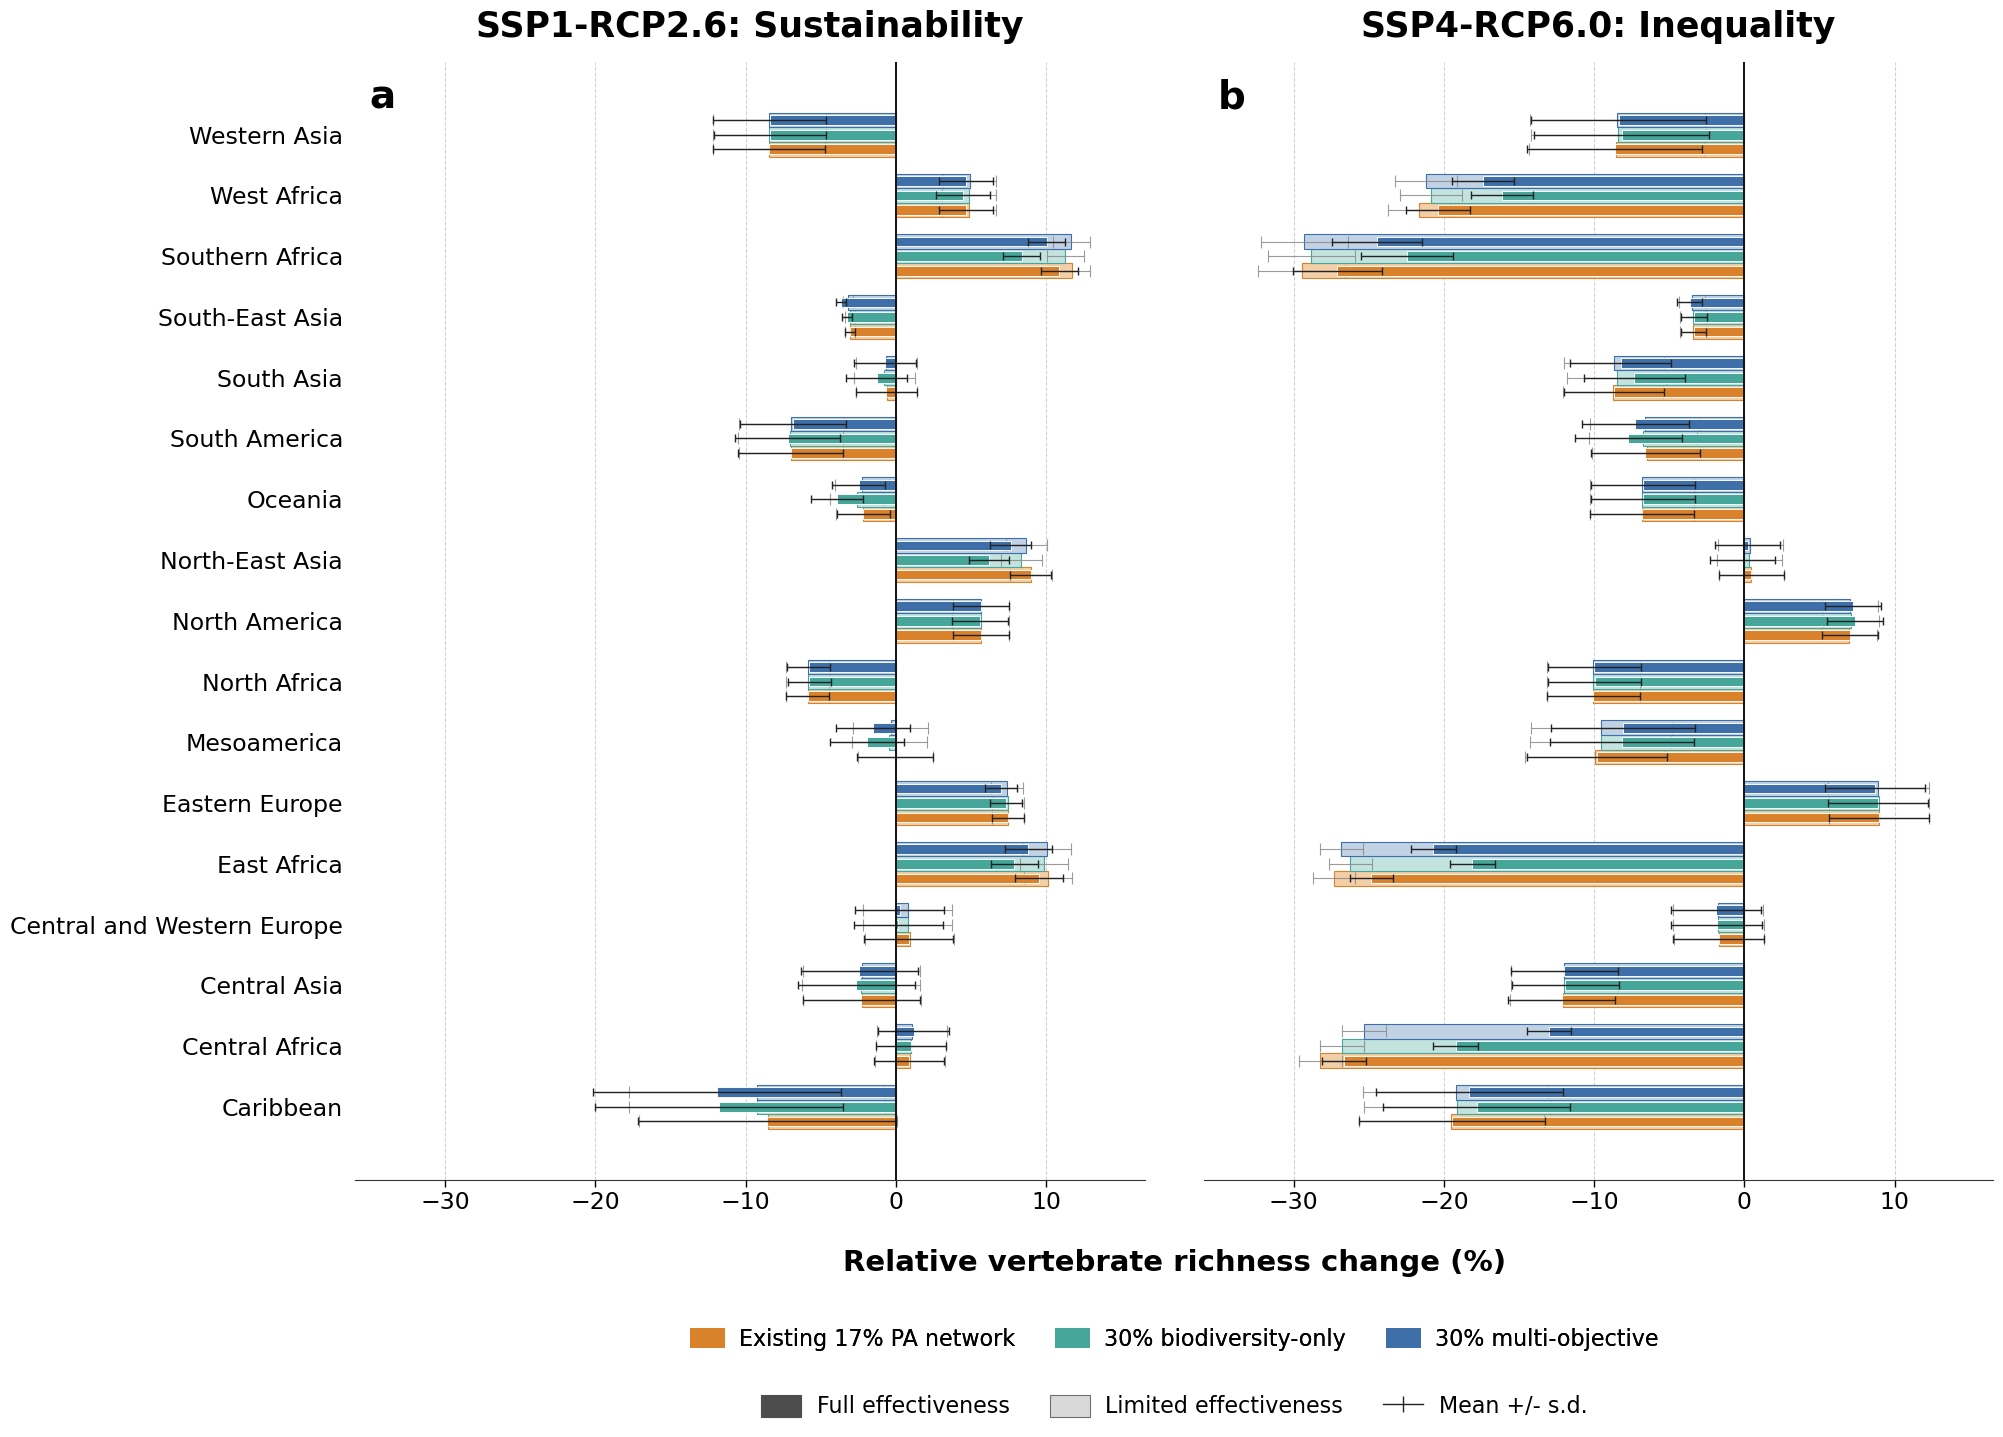


All outputs saved successfully:
  Figure PNG:             /capacity/occr_davin/mguzman/chari_P2_review/Global/New_results/Figures/F4_regional_richness_PA_effectiveness_comparison.png
  Figure TIFF:            /capacity/occr_davin/mguzman/chari_P2_review/Global/New_results/Figures/F4_regional_richness_PA_effectiveness_comparison.tiff
  Figure PDF:             /capacity/occr_davin/mguzman/chari_P2_review/Global/New_results/Figures/F4_regional_richness_PA_effectiveness_comparison.pdf
  Regional summaries:     /capacity/occr_davin/mguzman/chari_P2_review/Global/New_results/Figures/regional_richness_PA_effectiveness_summary.csv
  Paired-effect summary:  /capacity/occr_davin/mguzman/chari_P2_review/Global/New_results/Figures/regional_richness_paired_effectiveness_summary.csv
  Supplementary Table 1:  /capacity/occr_davin/mguzman/chari_P2_review/Global/New_results/Figures/Supplementary_Table_1_full-eff.csv
  Supplementary Table 2:  /capacity/occr_davin/mguzman/chari_P2_review/Global/New_resu

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""Regional vertebrate-richness changes by PA configuration and retention.

The script performs one consistent analysis for:
    1. Figure 4, showing Sustainability and Inequality.
    2. Supplementary Table 1, showing complete retention (full effectiveness).
    3. Supplementary Table 2, showing funding-constrained retention
       (limited effectiveness).

Regional values are area-weighted percentage changes relative to matching
historical 2015 totals. Means and sample SDs are calculated independently
for complete and funding-constrained retention across matched GCM-SDM
members. The intermediate pathway is analysed for the supplementary tables
but is not shown in the two-panel main figure.
"""

import os
import string
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from rasterio import features
from rasterio.transform import from_origin

warnings.filterwarnings("ignore", category=RuntimeWarning)

# =====================================================================
# 1. PATHS
# =====================================================================

BASE_PATH = (
    "/capacity/occr_davin/mguzman/chari_P2_review/Global/PA_scenarios/Sumprob_revised"
)
HISTORICAL_DIR = os.path.join(BASE_PATH, "WDPA", "Historical")
PA_ROOTS = {
    "pa17": os.path.join(BASE_PATH, "PA17"),
    "pa30_bio": os.path.join(BASE_PATH, "PA30_Bio"),
    "pa30_bcw": os.path.join(BASE_PATH, "PA30_BCW"),
}
SHAPEFILE_PATH = (
    "/capacity/occr_davin/chari/P1/IPBES_subregions/IPBES_Regions_Subregions2.shp"
)
OUTPUT_DIR = (
    "/capacity/occr_davin/mguzman/chari_P2_review/Global/New_results/Figures"
)
os.makedirs(OUTPUT_DIR, exist_ok=True)

OUTPUT_PNG = os.path.join(
    OUTPUT_DIR,
    "F4_regional_richness_PA_effectiveness_comparison.png",
)
OUTPUT_TIFF = os.path.join(
    OUTPUT_DIR,
    "F4_regional_richness_PA_effectiveness_comparison.tiff",
)
OUTPUT_PDF = os.path.join(
    OUTPUT_DIR,
    "F4_regional_richness_PA_effectiveness_comparison.pdf",
)

SUMMARY_CSV = os.path.join(
    OUTPUT_DIR,
    "regional_richness_PA_effectiveness_summary.csv",
)

PAIRED_SUMMARY_CSV = os.path.join(
    OUTPUT_DIR,
    "regional_richness_paired_effectiveness_summary.csv",
)


SUPPLEMENTARY_TABLE_1_CSV = os.path.join(
    OUTPUT_DIR,
    "Supplementary_Table_1_full-eff.csv",
)

SUPPLEMENTARY_TABLE_2_CSV = os.path.join(
    OUTPUT_DIR,
    "Supplementary_Table_2_lim-eff.csv",
)


# =====================================================================
# 2. SETTINGS
# =====================================================================

VARIABLE = "prob_clim_disp_luf"
REFERENCE_THRESHOLD = 0.01
HISTORICAL_GCM = "EWEMBI"
HISTORICAL_YEAR = "2015"
FUTURE_YEAR = "2080"
OUTPUT_DPI = 600

# All three pathways are analysed for the supplementary tables.
ANALYSIS_SCENARIOS = ["rcp26", "rcp45", "rcp60"]

# Only the two contrasting pathways are shown in the main figure.
PLOT_SCENARIOS = ["rcp26", "rcp60"]

SCENARIO_TITLES = {
    "rcp26": "SSP1-RCP2.6: Sustainability",
    "rcp45": "SSP2 land use-RCP2.6 climate: Intermediate",
    "rcp60": "SSP4-RCP6.0: Inequality",
}
SCENARIO_TABLE_LABELS = {
    "rcp26": "Sustainability (SSP1-RCP2.6)",
    "rcp45": "Intermediate (SSP2 land use-RCP2.6 climate)",
    "rcp60": "Inequality (SSP4-RCP6.0)",
}

TAXA = ["Amphibians", "Bird", "Mammals"]
GCMS = ["GFDL-ESM2M", "IPSL-CM5A-LR", "HadGEM2-ES", "MIROC5"]

SDM_CONFIGS = {
    "GAM": {
        "Amphibians": "GAM",
        "Bird": "GAM",
        "Mammals": "GAM",
    },
    "Mixed_GBM": {
        "Amphibians": "GBM",
        "Bird": "GBM",
        "Mammals": "GBM",
    },
}

PA_CONFIGS = {
    "pa17": {
        "label": "Existing 17% PA network",
        "table_label": "17% PA",
        "suffix": "pa17",
    },
    "pa30_bio": {
        "label": "30% biodiversity-only",
        "table_label": "30% biodiversity-only",
        "suffix": "pa30_bio",
    },
    "pa30_bcw": {
        "label": "30% multi-objective",
        "table_label": "30% multi-objective",
        "suffix": "pa30_bcw",
    },
}
PA_ORDER = ["pa17", "pa30_bio", "pa30_bcw"]

RETENTIONS = ["complete", "funding_constrained"]
RETENTION_LABELS = {
    "complete": "Complete retention",
    "funding_constrained": "Funding-constrained retention",
}

REGION_MAPPING = {
    "Caribbean": "Caribbean",
    "Central Africa": "Central Africa",
    "Central and Western Europe": "Central and Western Europe",
    "Central Asia": "Central Asia",
    "East Africa and adjacent islands": "East Africa",
    "Eastern Europe": "Eastern Europe",
    "Mesoamerica": "Mesoamerica",
    "North Africa": "North Africa",
    "North America": "North America",
    "North-East Asia": "North-East Asia",
    "Oceania": "Oceania",
    "South America": "South America",
    "South Asia": "South Asia",
    "South-East Asia": "South-East Asia",
    "Southern Africa": "Southern Africa",
    "West Africa": "West Africa",
    "Western Asia": "Western Asia",
}

# =====================================================================
# 3. FILE-PATH FUNCTIONS
# =====================================================================


def historical_file(taxon, sdm):
    """Return one matching historical taxon-SDM file."""
    filename = (
        f"summed_prob_{taxon}_{sdm}_{HISTORICAL_GCM}_"
        f"{HISTORICAL_YEAR}_baseline_2015.nc"
    )
    return os.path.join(HISTORICAL_DIR, filename)


def future_file(taxon, sdm, gcm, scenario, pa_key, retention):
    """Return one revised future taxon file."""
    suffix = PA_CONFIGS[pa_key]["suffix"]
    filename = (
        f"summed_prob_{taxon}_{sdm}_{gcm}_{scenario}_"
        f"{FUTURE_YEAR}_{suffix}_{retention}.nc"
    )
    return os.path.join(PA_ROOTS[pa_key], retention, filename)

# =====================================================================
# 4. DATA HELPERS
# =====================================================================


def standardize_coordinates(data_array):
    """Standardize coordinate names and longitude convention."""
    rename = {}
    if "latitude" in data_array.coords or "latitude" in data_array.dims:
        rename["latitude"] = "lat"
    if "longitude" in data_array.coords or "longitude" in data_array.dims:
        rename["longitude"] = "lon"
    if rename:
        data_array = data_array.rename(rename)
    if "lat" not in data_array.coords or "lon" not in data_array.coords:
        raise ValueError("Input lacks latitude/longitude coordinates.")
    if float(data_array.lon.max()) > 180:
        data_array = data_array.assign_coords(
            lon=((data_array.lon + 180) % 360) - 180
        )
    return data_array.sortby("lon").sortby("lat")


def load_variable(path):
    """Load and validate one NetCDF variable."""
    if not os.path.isfile(path):
        raise FileNotFoundError(path)
    if os.path.getsize(path) == 0:
        raise ValueError(f"Empty file: {path}")
    with xr.open_dataset(path, decode_times=False) as dataset:
        if VARIABLE not in dataset.data_vars:
            raise KeyError(
                f"{VARIABLE!r} absent from {path}; "
                f"found {list(dataset.data_vars)}"
            )
        data_array = dataset[VARIABLE].squeeze(drop=True).load()
    data_array = standardize_coordinates(data_array).astype(np.float64)
    values = data_array.values[np.isfinite(data_array.values)]
    if values.size == 0 or not np.any(values > 0):
        raise ValueError(f"No finite positive values: {path}")
    return data_array


def align_exact(first, second, description):
    """Require identical grids."""
    try:
        return xr.align(first, second, join="exact")
    except ValueError as error:
        raise ValueError(f"Grid mismatch: {description}") from error


def sum_taxa(paths, description):
    """Sum amphibian, bird and mammal richness for one member."""
    total = None
    for taxon in TAXA:
        data_array = load_variable(paths[taxon])
        if total is None:
            total = data_array.copy(deep=True)
        else:
            total, data_array = align_exact(
                total,
                data_array,
                f"{description}: {taxon}",
            )
            total = total + data_array
    return total.astype(np.float64)

# =====================================================================
# 5. HISTORICAL CONFIGURATIONS
# =====================================================================

historical_by_config = {}
mask_by_config = {}
weights_by_config = {}

for config, models in SDM_CONFIGS.items():
    print("\n" + "=" * 72)
    print(f"Loading historical configuration: {config}")
    print("=" * 72)

    paths = {
        taxon: historical_file(taxon, models[taxon])
        for taxon in TAXA
    }
    for taxon in TAXA:
        print(f"  {taxon} | {models[taxon]}: {paths[taxon]}")

    historical = sum_taxa(paths, f"historical {config}")
    historical_mask = (
        np.isfinite(historical)
        & (historical > REFERENCE_THRESHOLD)
    )
    valid_cells = int(historical_mask.sum().item())
    if valid_cells == 0:
        raise ValueError(f"No valid historical cells for {config}")

    latitude_weight = xr.DataArray(
        np.cos(np.deg2rad(historical.lat)),
        coords={"lat": historical.lat},
        dims=["lat"],
    )
    weights = latitude_weight.broadcast_like(historical).astype(np.float64)

    historical_by_config[config] = historical
    mask_by_config[config] = historical_mask
    weights_by_config[config] = weights
    print(f"  Valid historical cells: {valid_cells:,}")

# =====================================================================
# 6. REGIONAL MASKS
# =====================================================================

template = next(iter(historical_by_config.values()))
longitude = template.lon.values
latitude = template.lat.values
longitude_resolution = abs(float(longitude[1] - longitude[0]))
latitude_resolution = abs(float(latitude[1] - latitude[0]))
transform = from_origin(
    float(longitude.min()) - longitude_resolution / 2,
    float(latitude.max()) + latitude_resolution / 2,
    longitude_resolution,
    latitude_resolution,
)

print(f"\nLoading regional shapefile: {SHAPEFILE_PATH}")
regions = gpd.read_file(SHAPEFILE_PATH)
if regions.crs is None:
    raise ValueError("Regional shapefile has no CRS")
regions = regions.to_crs("EPSG:4326")
if "Sub_Region" not in regions.columns:
    raise KeyError("Missing Sub_Region field")

regions["Plot_region"] = regions["Sub_Region"].map(REGION_MAPPING)
regions = regions.loc[regions.Plot_region.notna()].copy()
unique_regions = sorted(regions.Plot_region.unique())
if not unique_regions:
    raise ValueError("No mapped regions found")

region_masks = {}
for region in unique_regions:
    geometries = regions.loc[
        regions.Plot_region == region,
        "geometry",
    ]
    north_to_south = features.rasterize(
        (
            (geometry, 1)
            for geometry in geometries
            if geometry is not None and not geometry.is_empty
        ),
        out_shape=template.shape,
        transform=transform,
        fill=0,
        default_value=1,
        dtype="uint8",
        all_touched=False,
    ).astype(bool)
    south_to_north = np.flipud(north_to_south)
    region_masks[region] = xr.DataArray(
        south_to_north,
        coords={"lat": template.lat, "lon": template.lon},
        dims=["lat", "lon"],
    )

print(f"Regional masks created: {len(unique_regions)}")


def regional_weighted_change(
    future,
    historical,
    historical_mask,
    weights,
    region_mask,
):
    """Calculate one region's area-weighted cell-level percentage change."""
    future, historical = align_exact(
        future, historical, "future/historical"
    )
    future, historical_mask = align_exact(
        future, historical_mask, "future/mask"
    )
    future, weights = align_exact(
        future, weights, "future/weights"
    )
    future, region_mask = align_exact(
        future, region_mask, "future/region"
    )

    valid = (
        region_mask
        & historical_mask
        & np.isfinite(future)
        & np.isfinite(historical)
    )
    valid_cells = int(valid.sum().item())
    if valid_cells == 0:
        return np.nan, 0

    change = ((future - historical) / historical) * 100.0
    regional_weights = weights.where(valid)
    denominator = float(
        regional_weights.sum(dim=["lat", "lon"], skipna=True).item()
    )
    if not np.isfinite(denominator) or denominator <= 0:
        return np.nan, valid_cells

    numerator = (
        change.where(valid) * regional_weights
    ).sum(dim=["lat", "lon"], skipna=True)

    return float((numerator / denominator).item()), valid_cells

# =====================================================================
# 7. MEMBER RESULTS
# =====================================================================

member_rows = []
skipped_rows = []

for scenario in ANALYSIS_SCENARIOS:
    print("\n" + "=" * 72)
    print(f"Processing scenario: {scenario}")
    print("=" * 72)

    for config, models in SDM_CONFIGS.items():
        historical = historical_by_config[config]
        historical_mask = mask_by_config[config]
        weights = weights_by_config[config]

        for gcm in GCMS:
            for pa_key in PA_ORDER:
                for retention in RETENTIONS:
                    member = (
                        f"{scenario} | {config} | {gcm} | "
                        f"{pa_key} | {retention}"
                    )
                    paths = {
                        taxon: future_file(
                            taxon,
                            models[taxon],
                            gcm,
                            scenario,
                            pa_key,
                            retention,
                        )
                        for taxon in TAXA
                    }
                    missing = [
                        path for path in paths.values()
                        if not os.path.isfile(path)
                    ]
                    if missing:
                        skipped_rows.append(
                            {
                                "Scenario": scenario,
                                "SDM_configuration": config,
                                "GCM": gcm,
                                "PA_configuration": pa_key,
                                "Retention": retention,
                                "Missing_files": " | ".join(missing),
                            }
                        )
                        continue

                    future = sum_taxa(paths, member)
                    future, historical_aligned = align_exact(
                        future,
                        historical,
                        member,
                    )

                    for region in unique_regions:
                        value, valid_cells = regional_weighted_change(
                            future,
                            historical_aligned,
                            historical_mask,
                            weights,
                            region_masks[region],
                        )
                        if np.isfinite(value):
                            member_rows.append(
                                {
                                    "Scenario": scenario,
                                    "Scenario_title": SCENARIO_TITLES[scenario],
                                    "SDM_configuration": config,
                                    "GCM": gcm,
                                    "PA_configuration": pa_key,
                                    "PA_label": PA_CONFIGS[pa_key]["label"],
                                    "Retention": retention,
                                    "Retention_label": RETENTION_LABELS[retention],
                                    "Region": region,
                                    "Relative_change": value,
                                    "Valid_cells": valid_cells,
                                }
                            )

member_df = pd.DataFrame(member_rows)
if member_df.empty:
    raise RuntimeError("No valid regional results")

# =====================================================================
# 8. SUMMARY STATISTICS
# =====================================================================

summary_df = (
    member_df
    .groupby(
        [
            "Scenario",
            "PA_configuration",
            "PA_label",
            "Retention",
            "Retention_label",
            "Region",
        ],
        as_index=False,
    )
    .agg(
        Mean_change=("Relative_change", "mean"),
        SD_change=(
            "Relative_change",
            lambda values: (
                values.std(ddof=1) if len(values) > 1 else np.nan
            ),
        ),
        SE_change=(
            "Relative_change",
            lambda values: (
                values.sem(ddof=1) if len(values) > 1 else np.nan
            ),
        ),
    )
)
summary_df.to_csv(
    SUMMARY_CSV,
    index=False,
    float_format="%.10f",
)

# Compare retention-specific SDs.
sd_comparison = summary_df.pivot_table(
    index=["Scenario", "PA_configuration", "PA_label", "Region"],
    columns="Retention",
    values="SD_change",
    aggfunc="first",
).reset_index()

if {"complete", "funding_constrained"}.issubset(sd_comparison.columns):
    sd_comparison["SD_difference"] = (
        sd_comparison["complete"]
        - sd_comparison["funding_constrained"]
    )
    sd_comparison["Absolute_SD_difference"] = (
        sd_comparison["SD_difference"].abs()
    )
    sd_comparison["SDs_numerically_identical"] = np.isclose(
        sd_comparison["complete"],
        sd_comparison["funding_constrained"],
        rtol=1e-10,
        atol=1e-12,
        equal_nan=True,
    )
    
    identical = int(sd_comparison.SDs_numerically_identical.sum())
    print("\nRetention-specific SD comparison")
    print(
        f"Numerically identical SD pairs: {identical:,} "
        f"of {len(sd_comparison):,}"
    )
    print(
        "Median absolute SD difference: "
        f"{sd_comparison.Absolute_SD_difference.median():.6f}"
    )
    print(
        "Maximum absolute SD difference: "
        f"{sd_comparison.Absolute_SD_difference.max():.6f}"
    )

# Paired retention effects for matched members.
paired = member_df.pivot_table(
    index=[
        "Scenario",
        "SDM_configuration",
        "GCM",
        "PA_configuration",
        "PA_label",
        "Region",
    ],
    columns="Retention",
    values="Relative_change",
    aggfunc="first",
).reset_index()

if not {"complete", "funding_constrained"}.issubset(paired.columns):
    raise RuntimeError("Retention outputs could not be paired")

paired["Retention_effect"] = (
    paired["complete"]
    - paired["funding_constrained"]
)

paired_summary = (
    paired
    .groupby(
        ["Scenario", "PA_configuration", "PA_label", "Region"],
        as_index=False,
    )
    .agg(
        Mean_retention_effect=("Retention_effect", "mean"),
        SD_retention_effect=(
            "Retention_effect",
            lambda values: (
                values.std(ddof=1) if len(values) > 1 else np.nan
            ),
        ),
        SE_retention_effect=(
            "Retention_effect",
            lambda values: (
                values.sem(ddof=1) if len(values) > 1 else np.nan
            ),
        ),
        N_paired_members=("Retention_effect", "count"),
    )
)
paired_summary.to_csv(
    PAIRED_SUMMARY_CSV,
    index=False,
    float_format="%.10f",
)

# =====================================================================
# 9. SUPPLEMENTARY TABLES 1 AND 2
# =====================================================================

# These tables intentionally report only mean +/- sample SD. Counts remain
# available in SUMMARY_CSV for quality control but are not displayed in the
# publication-ready supplementary tables.

PA_TABLE_ORDER = {
    PA_CONFIGS[pa_key]["table_label"]: index
    for index, pa_key in enumerate(PA_ORDER)
}
REGION_TABLE_ORDER = {
    region: index
    for index, region in enumerate(unique_regions)
}
SCENARIO_COLUMN_ORDER = [
    SCENARIO_TABLE_LABELS[scenario]
    for scenario in ANALYSIS_SCENARIOS
]


def build_supplementary_table(retention):
    """Create one wide, publication-ready retention table."""
    table_data = summary_df.loc[
        summary_df["Retention"] == retention
    ].copy()

    table_data["PA configuration"] = table_data[
        "PA_configuration"
    ].map(
        {
            key: value["table_label"]
            for key, value in PA_CONFIGS.items()
        }
    )
    table_data["Scenario column"] = table_data["Scenario"].map(
        SCENARIO_TABLE_LABELS
    )
    table_data["Mean +/- s.d. (%)"] = table_data.apply(
        lambda row: (
            f"{row['Mean_change']:.2f} +/- {row['SD_change']:.2f}"
            if np.isfinite(row["SD_change"])
            else f"{row['Mean_change']:.2f} +/- N/A"
        ),
        axis=1,
    )

    table = (
        table_data
        .pivot_table(
            index=["Region", "PA configuration"],
            columns="Scenario column",
            values="Mean +/- s.d. (%)",
            aggfunc="first",
        )
        .reset_index()
    )
    table.columns.name = None

    table["_region_order"] = table["Region"].map(REGION_TABLE_ORDER)
    table["_pa_order"] = table["PA configuration"].map(PA_TABLE_ORDER)
    table = (
        table
        .sort_values(["_region_order", "_pa_order"])
        .drop(columns=["_region_order", "_pa_order"])
        .reset_index(drop=True)
    )

    expected_columns = [
        "Region",
        "PA configuration",
        *SCENARIO_COLUMN_ORDER,
    ]
    missing_columns = [
        column for column in expected_columns
        if column not in table.columns
    ]
    if missing_columns:
        raise RuntimeError(
            f"Supplementary table for {retention} is missing columns: "
            f"{missing_columns}"
        )

    return table[expected_columns]


supplementary_table_1 = build_supplementary_table("complete")
supplementary_table_2 = build_supplementary_table("funding_constrained")

supplementary_table_1.to_csv(
    SUPPLEMENTARY_TABLE_1_CSV,
    index=False,
)

supplementary_table_2.to_csv(
    SUPPLEMENTARY_TABLE_2_CSV,
    index=False,
)

# Sanity checks: 17 regions x 3 PA configurations = 51 rows per table.
expected_rows = len(unique_regions) * len(PA_ORDER)
for table_name, table in [
    ("Supplementary Table 1", supplementary_table_1),
    ("Supplementary Table 2", supplementary_table_2),
]:
    if len(table) != expected_rows:
        raise RuntimeError(
            f"{table_name} has {len(table)} rows; "
            f"expected {expected_rows}."
        )

print("\nSupplementary tables saved successfully:")
print(f"  Table 1 CSV:      {SUPPLEMENTARY_TABLE_1_CSV}")
print(f"  Table 2 CSV:      {SUPPLEMENTARY_TABLE_2_CSV}")

# =====================================================================
# 10. FIGURE SETTINGS
# =====================================================================

FIGURE_WIDTH = 21
FIGURE_HEIGHT = 15
TITLE_SIZE = 25
PANEL_SIZE = 28
REGION_SIZE = 17
AXIS_LABEL_SIZE = 21
TICK_SIZE = 17
LEGEND_SIZE = 16
BAR_GROUP_SPACING = 1.25
BAR_HEIGHT_FUNDING = 0.30
BAR_HEIGHT_COMPLETE = 0.20
CONFIG_OFFSET = 0.30

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 17,
        "axes.labelsize": AXIS_LABEL_SIZE,
        "axes.titlesize": TITLE_SIZE,
        "xtick.labelsize": TICK_SIZE,
        "ytick.labelsize": REGION_SIZE,
        "legend.fontsize": LEGEND_SIZE,
        "axes.linewidth": 0.8,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "savefig.facecolor": "white",
        "savefig.edgecolor": "white",
    }
)

COLORS = {
    "pa17": "#D9822B",
    "pa30_bio": "#45A699",
    "pa30_bcw": "#3E6FA8",
}
PALE = {
    "pa17": "#F3CFA8",
    "pa30_bio": "#C2E3DE",
    "pa30_bcw": "#C2D2E5",
}
OFFSETS = {
    "pa17": -CONFIG_OFFSET,
    "pa30_bio": 0.0,
    "pa30_bcw": CONFIG_OFFSET,
}

# Limits use only the two scenarios displayed in the figure.
plot_summary = summary_df.loc[
    summary_df["Scenario"].isin(PLOT_SCENARIOS)
].copy()

bounds = []
for _, row in plot_summary.iterrows():
    standard_deviation = (
        float(row.SD_change)
        if np.isfinite(row.SD_change)
        else 0.0
    )
    bounds.extend(
        [
            float(row.Mean_change) - standard_deviation,
            float(row.Mean_change) + standard_deviation,
        ]
    )

if not bounds:
    raise RuntimeError("No summary values are available for the figure")

lower_bound = min(bounds)
upper_bound = max(bounds)
range_width = max(upper_bound - lower_bound, 1.0)
axis_margin = max(2.0, 0.08 * range_width)
X_LIMITS = (
    lower_bound - axis_margin,
    upper_bound + axis_margin,
)

# =====================================================================
# 11. PLOT
# =====================================================================

fig, axes = plt.subplots(
    1,
    len(PLOT_SCENARIOS),
    figsize=(FIGURE_WIDTH, FIGURE_HEIGHT),
    sharey=True,
    facecolor="white",
)

if len(PLOT_SCENARIOS) == 1:
    axes = np.atleast_1d(axes)

y_regions = np.arange(len(unique_regions)) * BAR_GROUP_SPACING
panel_labels = list(string.ascii_lowercase)

for panel_index, scenario in enumerate(PLOT_SCENARIOS):
    axis = axes[panel_index]
    panel_data = summary_df.loc[summary_df.Scenario == scenario]

    for pa_key in PA_ORDER:
        y_positions = y_regions + OFFSETS[pa_key]

        funding_data = panel_data.loc[
            (panel_data.PA_configuration == pa_key)
            & (panel_data.Retention == "funding_constrained")
        ].set_index("Region")

        complete_data = panel_data.loc[
            (panel_data.PA_configuration == pa_key)
            & (panel_data.Retention == "complete")
        ].set_index("Region")

        funding_means = np.array(
            [
                funding_data.loc[region, "Mean_change"]
                if region in funding_data.index
                else np.nan
                for region in unique_regions
            ],
            dtype=float,
        )
        funding_sd = np.array(
            [
                funding_data.loc[region, "SD_change"]
                if (
                    region in funding_data.index
                    and np.isfinite(
                        funding_data.loc[region, "SD_change"]
                    )
                )
                else 0.0
                for region in unique_regions
            ],
            dtype=float,
        )
        funding_valid = np.isfinite(funding_means)

        complete_means = np.array(
            [
                complete_data.loc[region, "Mean_change"]
                if region in complete_data.index
                else np.nan
                for region in unique_regions
            ],
            dtype=float,
        )
        complete_sd = np.array(
            [
                complete_data.loc[region, "SD_change"]
                if (
                    region in complete_data.index
                    and np.isfinite(
                        complete_data.loc[region, "SD_change"]
                    )
                )
                else 0.0
                for region in unique_regions
            ],
            dtype=float,
        )
        complete_valid = np.isfinite(complete_means)

        # Wider pale bar: funding-constrained retention.
        axis.barh(
            y_positions[funding_valid],
            funding_means[funding_valid],
            height=BAR_HEIGHT_FUNDING,
            color=PALE[pa_key],
            edgecolor=COLORS[pa_key],
            linewidth=0.8,
            zorder=2,
        )
        axis.errorbar(
            funding_means[funding_valid],
            y_positions[funding_valid],
            xerr=funding_sd[funding_valid],
            fmt="none",
            ecolor="#8A8A8A",
            elinewidth=0.8,
            capsize=4.2,
            capthick=0.8,
            alpha=0.85,
            zorder=3,
        )

        # Narrower dark bar: complete retention.
        axis.barh(
            y_positions[complete_valid],
            complete_means[complete_valid],
            height=BAR_HEIGHT_COMPLETE,
            color=COLORS[pa_key],
            edgecolor="white",
            linewidth=0.65,
            zorder=4,
        )
        axis.errorbar(
            complete_means[complete_valid],
            y_positions[complete_valid],
            xerr=complete_sd[complete_valid],
            fmt="none",
            ecolor="#222222",
            elinewidth=1.0,
            capsize=3.0,
            capthick=1.0,
            alpha=1.0,
            zorder=5,
        )

    axis.axvline(0, color="#111111", linewidth=1.4, zorder=6)
    axis.set_xlim(X_LIMITS)
    axis.set_yticks(y_regions)
    if panel_index == 0:
        axis.set_yticklabels(unique_regions, fontsize=REGION_SIZE)
    axis.invert_yaxis()
    axis.set_title(
        SCENARIO_TITLES[scenario],
        fontsize=TITLE_SIZE,
        fontweight="bold",
        pad=18,
    )
    axis.tick_params(
        axis="x",
        labelsize=TICK_SIZE,
        width=1.0,
        length=5,
    )
    axis.tick_params(axis="y", length=0, pad=9)
    axis.grid(
        axis="x",
        linestyle="--",
        linewidth=0.75,
        color="#BDBDBD",
        alpha=0.70,
        zorder=0,
    )
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.spines["left"].set_visible(False)
    axis.spines["bottom"].set_color("#333333")
    axis.text(
        0.018,
        0.985,
        panel_labels[panel_index],
        transform=axis.transAxes,
        fontsize=PANEL_SIZE,
        fontweight="bold",
        ha="left",
        va="top",
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.92,
            "pad": 1.5,
        },
        zorder=10,
    )

# =====================================================================
# 12. SHARED LABEL AND LEGENDS
# =====================================================================

LEFT_MARGIN = 0.205
RIGHT_MARGIN = 0.985
PLOT_CENTER = (LEFT_MARGIN + RIGHT_MARGIN) / 2.0

fig.supxlabel(
    "Relative vertebrate richness change (%)",
    fontsize=AXIS_LABEL_SIZE,
    fontweight="semibold",
    x=PLOT_CENTER,
    y=0.125,
)

configuration_handles = [
    Patch(
        facecolor=COLORS[pa_key],
        edgecolor="none",
        label=PA_CONFIGS[pa_key]["label"],
    )
    for pa_key in PA_ORDER
]

configuration_legend = fig.legend(
    handles=configuration_handles,
    loc="lower center",
    bbox_to_anchor=(PLOT_CENTER, 0.070),
    ncol=3,
    frameon=False,
    fontsize=LEGEND_SIZE,
    handlelength=1.55,
    handleheight=1.0,
    handletextpad=0.65,
    columnspacing=1.8,
    borderaxespad=0.0,
)
fig.add_artist(configuration_legend)

retention_handles = [
    Patch(
        facecolor="#4D4D4D",
        edgecolor="#4D4D4D",
        linewidth=0.8,
        label="Full effectiveness",
    ),
    Patch(
        facecolor="#D9D9D9",
        edgecolor="#6F6F6F",
        linewidth=0.8,
        label="Limited effectiveness",
    ),
    Line2D(
        [0],
        [0],
        color="#222222",
        linewidth=1.0,
        marker="|",
        markeredgewidth=1.0,
        markersize=11,
        label="Mean +/- s.d.",
    ),
]

fig.legend(
    handles=retention_handles,
    loc="lower center",
    bbox_to_anchor=(PLOT_CENTER, 0.025),
    ncol=3,
    frameon=False,
    fontsize=LEGEND_SIZE,
    handlelength=1.8,
    handleheight=1.15,
    handletextpad=0.70,
    columnspacing=1.8,
    borderaxespad=0.0,
)

plt.subplots_adjust(
    left=LEFT_MARGIN,
    right=RIGHT_MARGIN,
    top=0.935,
    bottom=0.190,
    wspace=0.075,
)

# =====================================================================
# 13. SAVE FIGURE
# =====================================================================

png_metadata = {
    "Title": (
        "Regional vertebrate richness changes under alternative "
        "protected-area configurations and retention assumptions"
    ),
    "Description": (
        "Regional ensemble means and standard deviations under complete "
        "and funding-constrained retention."
    ),
}
pdf_metadata = {
    "Title": png_metadata["Title"],
    "Subject": png_metadata["Description"],
}

fig.savefig(
    OUTPUT_PNG,
    dpi=OUTPUT_DPI,
    bbox_inches="tight",
    pad_inches=0.08,
    facecolor="white",
    edgecolor="white",
    transparent=False,
    metadata=png_metadata,
)
fig.savefig(
    OUTPUT_TIFF,
    format="tiff",
    dpi=OUTPUT_DPI,
    bbox_inches="tight",
    pad_inches=0.08,
    facecolor="white",
    edgecolor="white",
    transparent=False,
    pil_kwargs={"compression": "tiff_lzw"},
)
fig.savefig(
    OUTPUT_PDF,
    format="pdf",
    dpi=OUTPUT_DPI,
    bbox_inches="tight",
    pad_inches=0.08,
    facecolor="white",
    edgecolor="white",
    transparent=False,
    metadata=pdf_metadata,
)

plt.show()
# For a non-interactive cluster job, replace plt.show() with:
# plt.close(fig)

print("\nAll outputs saved successfully:")
print(f"  Figure PNG:             {OUTPUT_PNG}")
print(f"  Figure TIFF:            {OUTPUT_TIFF}")
print(f"  Figure PDF:             {OUTPUT_PDF}")

print(f"  Regional summaries:     {SUMMARY_CSV}")


print(f"  Paired-effect summary:  {PAIRED_SUMMARY_CSV}")
print(f"  Supplementary Table 1:  {SUPPLEMENTARY_TABLE_1_CSV}")
print(f"  Supplementary Table 2:  {SUPPLEMENTARY_TABLE_2_CSV}")



Figure 5. Methods diagram

2x2 Pannel explanaition of PA-adjusted land-use change and land-use filtered probability of occurrence for SDMs

In [89]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""Create Figure 5 as a compact 2 x 2 Methods workflow.

Step 1:
    Projected LUH2 change x fraction of change allowed
    = realized land-use change.

Step 2:
    Present-day land use + realized land-use change
    = PA-adjusted future land use.

Step 3:
    Species-specific habitat-LU crosswalk x PA-adjusted future land use
    = suitable land-use fraction.

Step 4:
    Suitable land-use fraction x climate- and dispersal-constrained
    probability = land-use-filtered probability of occurrence.

Each quadrant contains one operation and one equals sign. Numbered
steps establish the calculation sequence, while compact named tokens
identify outputs from preceding steps that are reused as inputs.
"""

from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch


# =====================================================================
# 1. OUTPUTS
# =====================================================================

OUTPUT_DIR = Path(
    "/capacity/occr_davin/mguzman/chari_P2_review/"
    "Global/New_results/Figures"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_TIFF = OUTPUT_DIR / "F5_PA_LUF_methods_2x2.tiff"
OUTPUT_PNG = OUTPUT_DIR / "F5_PA_LUF_methods_2x2.png"
OUTPUT_PDF = OUTPUT_DIR / "F5_PA_LUF_methods_2x2.pdf"
OUTPUT_DPI = 600


# =====================================================================
# 2. FIGURE SETTINGS
# =====================================================================

FIGURE_WIDTH = 30
FIGURE_HEIGHT = 20

STEP_LABEL_SIZE = 50
GRID_TITLE_SIZE = 23
CELL_VALUE_SIZE = 21
OPERATOR_SIZE = 62
TOKEN_SIZE = 25
LEGEND_SIZE = 25

TEXT_COLOR = "#1A1A1A"
OPERATOR_COLOR = "#3F3F3F"

PA_COLOR = "#E67E00"
PANEL_BORDER_COLOR = "#D2D2D2"

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 19,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "savefig.facecolor": "white",
        "savefig.edgecolor": "white",
    }
)


# =====================================================================
# 3. ILLUSTRATIVE DATA
# =====================================================================

PA_FRACTION = np.array(
    [
        [0.0, 0.0, 0.0],
        [0.0, 0.9, 0.0],
        [0.0, 0.6, 0.0],
    ],
    dtype=float,
)

RETENTION_FRACTION = 1.0
CHANGE_ALLOWED = 1.0 - PA_FRACTION * RETENTION_FRACTION

PRESENT_DAY_LAND_USE = np.array(
    [
        [0.20, 1.00, 0.80],
        [1.00, 0.90, 0.70],
        [0.50, 0.40, 0.10],
    ],
    dtype=float,
)

PROJECTED_LUH2_CHANGE = np.array(
    [
        [0.04, -0.30, -0.20],
        [-0.40, -0.35, 0.14],
        [-0.10, -0.15, -0.05],
    ],
    dtype=float,
)

REALIZED_LAND_USE_CHANGE = PROJECTED_LUH2_CHANGE * CHANGE_ALLOWED

PA_ADJUSTED_FUTURE_LAND_USE = np.clip(
    PRESENT_DAY_LAND_USE + REALIZED_LAND_USE_CHANGE,
    0.0,
    1.0,
)

SPECIES_HABITAT_LU_CROSSWALK = np.array(
    [
        [1, 1, 0],
        [1, 1, 1],
        [0, 1, 0],
    ],
    dtype=float,
)

SUITABLE_LAND_USE_FRACTION = (
    PA_ADJUSTED_FUTURE_LAND_USE
    * SPECIES_HABITAT_LU_CROSSWALK
)

CLIMATE_DISPERSAL_PROBABILITY = np.array(
    [
        [0.80, 0.50, 0.20],
        [0.90, 0.60, 0.30],
        [0.70, 0.40, 0.10],
    ],
    dtype=float,
)

LUF_PROBABILITY = (
    SUITABLE_LAND_USE_FRACTION
    * CLIMATE_DISPERSAL_PROBABILITY
)

NORM_FRACTION = mcolors.Normalize(vmin=0.0, vmax=1.0)
NORM_BINARY = mcolors.Normalize(vmin=0.0, vmax=1.0)
NORM_DELTA = mcolors.TwoSlopeNorm(
    vmin=-0.5,
    vcenter=0.0,
    vmax=0.5,
)


# =====================================================================
# 4. DRAWING HELPERS
# =====================================================================


def choose_text_color(cmap_name, normalized_value):
    """Return a legible colour for one cell value."""

    if cmap_name == "RdBu":
        return "#222222" if 0.25 < normalized_value < 0.75 else "white"
    if cmap_name in {"Purples", "Greys"}:
        return "#222222" if normalized_value < 0.40 else "white"
    return "white" if normalized_value > 0.52 else "#222222"



def draw_matrix(
    axis,
    data,
    title,
    colormap,
    normalization,
    cmap_name,
    value_format="fraction",
    show_pa=False,
):
    """Draw one square 3 x 3 matrix with an aligned title."""

    axis.set_aspect("equal")
    axis.set_xlim(-0.5, 2.5)
    axis.set_ylim(2.5, -0.5)
    axis.set_xticks([])
    axis.set_yticks([])
    axis.set_facecolor("white")

    for spine in axis.spines.values():
        spine.set_visible(False)

    for row_index in range(data.shape[0]):
        for column_index in range(data.shape[1]):
            value = float(data[row_index, column_index])
            normalized_value = float(normalization(value))

            cell = plt.Rectangle(
                (column_index - 0.5, row_index - 0.5),
                1.0,
                1.0,
                facecolor=colormap(normalized_value),
                edgecolor="#333333",
                linewidth=1.40,
                zorder=1,
            )
            axis.add_patch(cell)

            if value_format == "change":
                label = f"{value:+.2f}"
            elif value_format == "binary":
                label = f"{int(value)}"
            else:
                label = f"{value:.2f}"

            label_color = choose_text_color(cmap_name, normalized_value)
            text = axis.text(
                column_index,
                row_index,
                label,
                ha="center",
                va="center",
                fontsize=CELL_VALUE_SIZE,
                fontweight="bold",
                color=label_color,
                zorder=4,
            )

            stroke_color = "white" if label_color != "white" else "black"
            text.set_path_effects(
                [
                    path_effects.withStroke(
                        linewidth=1.2,
                        foreground=stroke_color,
                        alpha=0.16,
                    )
                ]
            )

            if show_pa and PA_FRACTION[row_index, column_index] > 0.01:
                outline = plt.Rectangle(
                    (column_index - 0.47, row_index - 0.47),
                    0.94,
                    0.94,
                    facecolor="none",
                    edgecolor=PA_COLOR,
                    linewidth=4.0,
                    zorder=5,
                )
                outline.set_path_effects(
                    [
                        path_effects.withStroke(
                            linewidth=6.8,
                            foreground="white",
                        )
                    ]
                )
                axis.add_patch(outline)

    axis.set_title(
        title,
        fontsize=GRID_TITLE_SIZE,
        fontweight="bold",
        pad=11,
        color=TEXT_COLOR,
        linespacing=1.08,
    )



def add_operator(fig, x, y, symbol):
    """Place a large operator outside matrices and tokens."""

    fig.text(
        x,
        y,
        symbol,
        ha="center",
        va="center",
        fontsize=OPERATOR_SIZE,
        fontweight="bold",
        color=OPERATOR_COLOR,
        zorder=30,
    )



def add_token(fig, x, y, text, width=0.090, height=0.047):
    """Add a compact named token representing an upstream matrix."""

    token = FancyBboxPatch(
        (x - width / 2, y - height / 2),
        width,
        height,
        transform=fig.transFigure,
        boxstyle="round,pad=0.004,rounding_size=0.006",
        facecolor="#F4F4F4",
        edgecolor="#666666",
        linewidth=1.4,
        zorder=20,
    )
    fig.add_artist(token)

    fig.text(
        x,
        y,
        text,
        ha="center",
        va="center",
        fontsize=TOKEN_SIZE,
        fontweight="semibold",
        color=TEXT_COLOR,
        zorder=21,
    )

def add_step_label(fig, x, y, label):
    """Add a bold upright lowercase panel label."""

    fig.text(
        x,
        y,
        label,
        ha="left",
        va="top",
        fontsize=STEP_LABEL_SIZE,
        fontweight="bold",
        fontstyle="normal",
        color="#1A1A1A",
        zorder=40,
    )


# =====================================================================
# 5. CREATE 2 x 2 METHODS FIGURE
# =====================================================================


def create_methods_figure():
    """Create and export the four-step 2 x 2 workflow."""

    fig = plt.figure(
        figsize=(FIGURE_WIDTH, FIGURE_HEIGHT),
        dpi=OUTPUT_DPI,
        facecolor="white",
    )

    # Quadrant separators.
    fig.add_artist(
        Line2D(
            [0.5, 0.5],
            [0.07, 0.95],
            transform=fig.transFigure,
            color=PANEL_BORDER_COLOR,
            linewidth=1.2,
            zorder=0,
        )
    )
    fig.add_artist(
        Line2D(
            [0.025, 0.975],
            [0.51, 0.51],
            transform=fig.transFigure,
            color=PANEL_BORDER_COLOR,
            linewidth=1.2,
            zorder=0,
        )
    )

    # Step markers establish the reading order.
    add_step_label(fig, 0.040, 0.945, "a")
    add_step_label(fig, 0.520, 0.945, "b")
    add_step_label(fig, 0.040, 0.485, "c")
    add_step_label(fig, 0.520, 0.485, "d")


    # -----------------------------------------------------------------
    # Step 1: projected change x fraction allowed = realized change
    # -----------------------------------------------------------------

    step_1_y = 0.625
    matrix_w = 0.120
    matrix_h = 0.225

    raw_axis = fig.add_axes([0.055, step_1_y, matrix_w, matrix_h])
    allowed_axis = fig.add_axes([0.215, step_1_y, matrix_w, matrix_h])
    realized_axis = fig.add_axes([0.375, step_1_y, matrix_w, matrix_h])

    draw_matrix(
        raw_axis,
        PROJECTED_LUH2_CHANGE,
        "Projected land-use (LU)\n change\n" + r"$\Delta LUH2_{2080-2015}$",
        plt.cm.RdBu,
        NORM_DELTA,
        "RdBu",
        value_format="change",
    )
    draw_matrix(
        allowed_axis,
        CHANGE_ALLOWED,
        "Fraction of change allowed\n" + r"$1-PA_{frac}\times F$",
        plt.cm.Purples,
        NORM_FRACTION,
        "Purples",
    )
    draw_matrix(
        realized_axis,
        REALIZED_LAND_USE_CHANGE,
        "Realized LU change\n" + r"$\Delta LUH2_{realized}$",
        plt.cm.RdBu,
        NORM_DELTA,
        "RdBu",
        value_format="change",
        show_pa=True,
    )

    add_operator(fig, 0.195, 0.735, "×")
    add_operator(fig, 0.355, 0.735, "=")

    # -----------------------------------------------------------------
    # Step 2: present day + realized token = PA-adjusted future
    # -----------------------------------------------------------------

    present_axis = fig.add_axes([0.545, step_1_y, 0.135, matrix_h])
    adjusted_axis = fig.add_axes([0.825, step_1_y, 0.135, matrix_h])

    draw_matrix(
        present_axis,
        PRESENT_DAY_LAND_USE,
        "Present-day LU\n" + r"$LU_{2015}$",
        plt.cm.YlGn,
        NORM_FRACTION,
        "YlGn",
    )
    draw_matrix(
        adjusted_axis,
        PA_ADJUSTED_FUTURE_LAND_USE,
        "PA-adjusted future LU\n" + r"$LU_{adj,2080}$",
        plt.cm.YlGn,
        NORM_FRACTION,
        "YlGn",
        show_pa=True,
    )

    step_2_center_y = 0.735
    realized_token_x = 0.745

    add_token(
        fig,
        realized_token_x,
        step_2_center_y,
        r"$\Delta LUH2_{realized}$",
        width=0.07,
        height=0.047,
    )
    add_operator(fig, 0.690, step_2_center_y, "+")
    add_operator(fig, 0.810, step_2_center_y, "=")

    # -----------------------------------------------------------------
    # Step 3: crosswalk x adjusted token = suitable fraction
    # -----------------------------------------------------------------

    step_3_y = 0.165

    crosswalk_axis = fig.add_axes([0.055, step_3_y, 0.135, matrix_h])
    suitable_axis = fig.add_axes([0.355, step_3_y, 0.135, matrix_h])

    draw_matrix(
        crosswalk_axis,
        SPECIES_HABITAT_LU_CROSSWALK,
        "Species-specific\n habitat-LU crosswalk\n"
        + r"$S_{habitat}\in\{0,1\}$",
        plt.cm.Greys,
        NORM_BINARY,
        "Greys",
        value_format="binary",
    )
    draw_matrix(
        suitable_axis,
        SUITABLE_LAND_USE_FRACTION,
        "Suitable LU fraction\n" + r"$H_{suit}$",
        plt.cm.YlGn,
        NORM_FRACTION,
        "YlGn",
        show_pa=True,
    )

    step_3_center_y = 0.275
    adjusted_token_x = 0.255

    add_token(
        fig,
        adjusted_token_x,
        step_3_center_y,
        r"$LU_{adj,2080}$",
        width=0.06,
        height=0.047,
    )
    add_operator(fig, 0.205, step_3_center_y, "×")
    add_operator(fig, 0.315, step_3_center_y, "=")

    # -----------------------------------------------------------------
    # Step 4: H_suit token x climate probability = LUF probability
    # -----------------------------------------------------------------

    climate_axis = fig.add_axes([0.665, step_3_y, 0.135, matrix_h])
    luf_axis = fig.add_axes([0.845, step_3_y, 0.135, matrix_h])

    draw_matrix(
        climate_axis,
        CLIMATE_DISPERSAL_PROBABILITY,
        "Climate and dispersal probability\n" + r"$P_{clim,disp}$",
        plt.cm.Blues,
        NORM_FRACTION,
        "Blues",
    )
    draw_matrix(
        luf_axis,
        LUF_PROBABILITY,
        "LUF probability\n" + r"$P_{LUF}$",
        plt.cm.YlGnBu,
        NORM_FRACTION,
        "YlGnBu",
        show_pa=True,
    )

    step_4_center_y = 0.275
    hsuit_token_x = 0.565

    add_token(
        fig,
        hsuit_token_x,
        step_4_center_y,
        r"$H_{suit}$",
        width=0.070,
        height=0.047,
    )
    add_operator(fig, 0.635, step_4_center_y, "×")
    add_operator(fig, 0.825, step_4_center_y, "=")

    # -----------------------------------------------------------------
    # Legend and export
    # -----------------------------------------------------------------

    protected_handle = Line2D(
        [0],
        [0],
        color=PA_COLOR,
        linewidth=5,
        label=r"Protected grid cell $(PA_{frac}>0)$",
    )
    

    fig.legend(
        handles=[protected_handle],
        loc="lower center",
        bbox_to_anchor=(0.500, 0.015),
        ncol=1,
        fontsize=LEGEND_SIZE,
        frameon=True,
        handlelength=2.3,
    )

    png_metadata = {
        "Title": "PA-mediated land-use adjustment and land-use filtering",
        "Description": (
            "Four-step Methods workflow showing PA-mediated realization of "
            "projected land-use change, construction of PA-adjusted future "
            "land use, derivation of suitable land-use fraction, and land-use "
            "filtering of climate- and dispersal-constrained probability."
        ),
    }
    pdf_metadata = {
        "Title": png_metadata["Title"],
        "Subject": png_metadata["Description"],
    }

    fig.savefig(
        OUTPUT_TIFF,
        dpi=OUTPUT_DPI,
        bbox_inches="tight",
        pad_inches=0.08,
        format="tiff",
        facecolor="white",
        edgecolor="white",
        transparent=False,
        pil_kwargs={"compression": "tiff_lzw"},
    )
    fig.savefig(
        OUTPUT_PNG,
        dpi=OUTPUT_DPI,
        bbox_inches="tight",
        pad_inches=0.08,
        format="png",
        facecolor="white",
        edgecolor="white",
        transparent=False,
        metadata=png_metadata,
    )
    fig.savefig(
        OUTPUT_PDF,
        dpi=OUTPUT_DPI,
        bbox_inches="tight",
        pad_inches=0.08,
        format="pdf",
        facecolor="white",
        edgecolor="white",
        transparent=False,
        metadata=pdf_metadata,
    )

    plt.show()
    # For batch execution, replace plt.show() with plt.close(fig).

    print("2 x 2 Methods Figure 5 saved successfully:")
    print(f"  TIFF: {OUTPUT_TIFF}")
    print(f"  PNG:  {OUTPUT_PNG}")
    print(f"  PDF:  {OUTPUT_PDF}")


if __name__ == "__main__":
    create_methods_figure()


2 x 2 Methods Figure 5 saved successfully:
  TIFF: /capacity/occr_davin/mguzman/chari_P2_review/Global/New_results/Figures/F5_PA_LUF_methods_2x2.tiff
  PNG:  /capacity/occr_davin/mguzman/chari_P2_review/Global/New_results/Figures/F5_PA_LUF_methods_2x2.png
  PDF:  /capacity/occr_davin/mguzman/chari_P2_review/Global/New_results/Figures/F5_PA_LUF_methods_2x2.pdf


Supplementary Fig. 1. Spatial distribution of PA scenarios (17%-PA, 'biodiversity-only', 'multi-objective')

Loading panel a: /capacity/occr_davin/mguzman/chari_P2_review/data/PA_masks/WDPA_percentage_map.nc
  Variable: WDPA_percentage_map.tif
  Finite cells: 163,691
  Protected cells: 7,916
  Protected minimum: 0.010000
  Protected maximum: 1.000000
Loading panel b: /capacity/occr_davin/mguzman/chari_P2_review/data/PA_masks/bio-only_withPA.nc
  Variable: fraction
  Finite cells: 246,240
  Protected cells: 40,768
  Protected minimum: 0.000008
  Protected maximum: 1.000000
Loading panel c: /capacity/occr_davin/mguzman/chari_P2_review/data/PA_masks/bcw_withPA.nc
  Variable: fraction
  Finite cells: 246,240
  Protected cells: 39,102
  Protected minimum: 0.000016
  Protected maximum: 1.000000


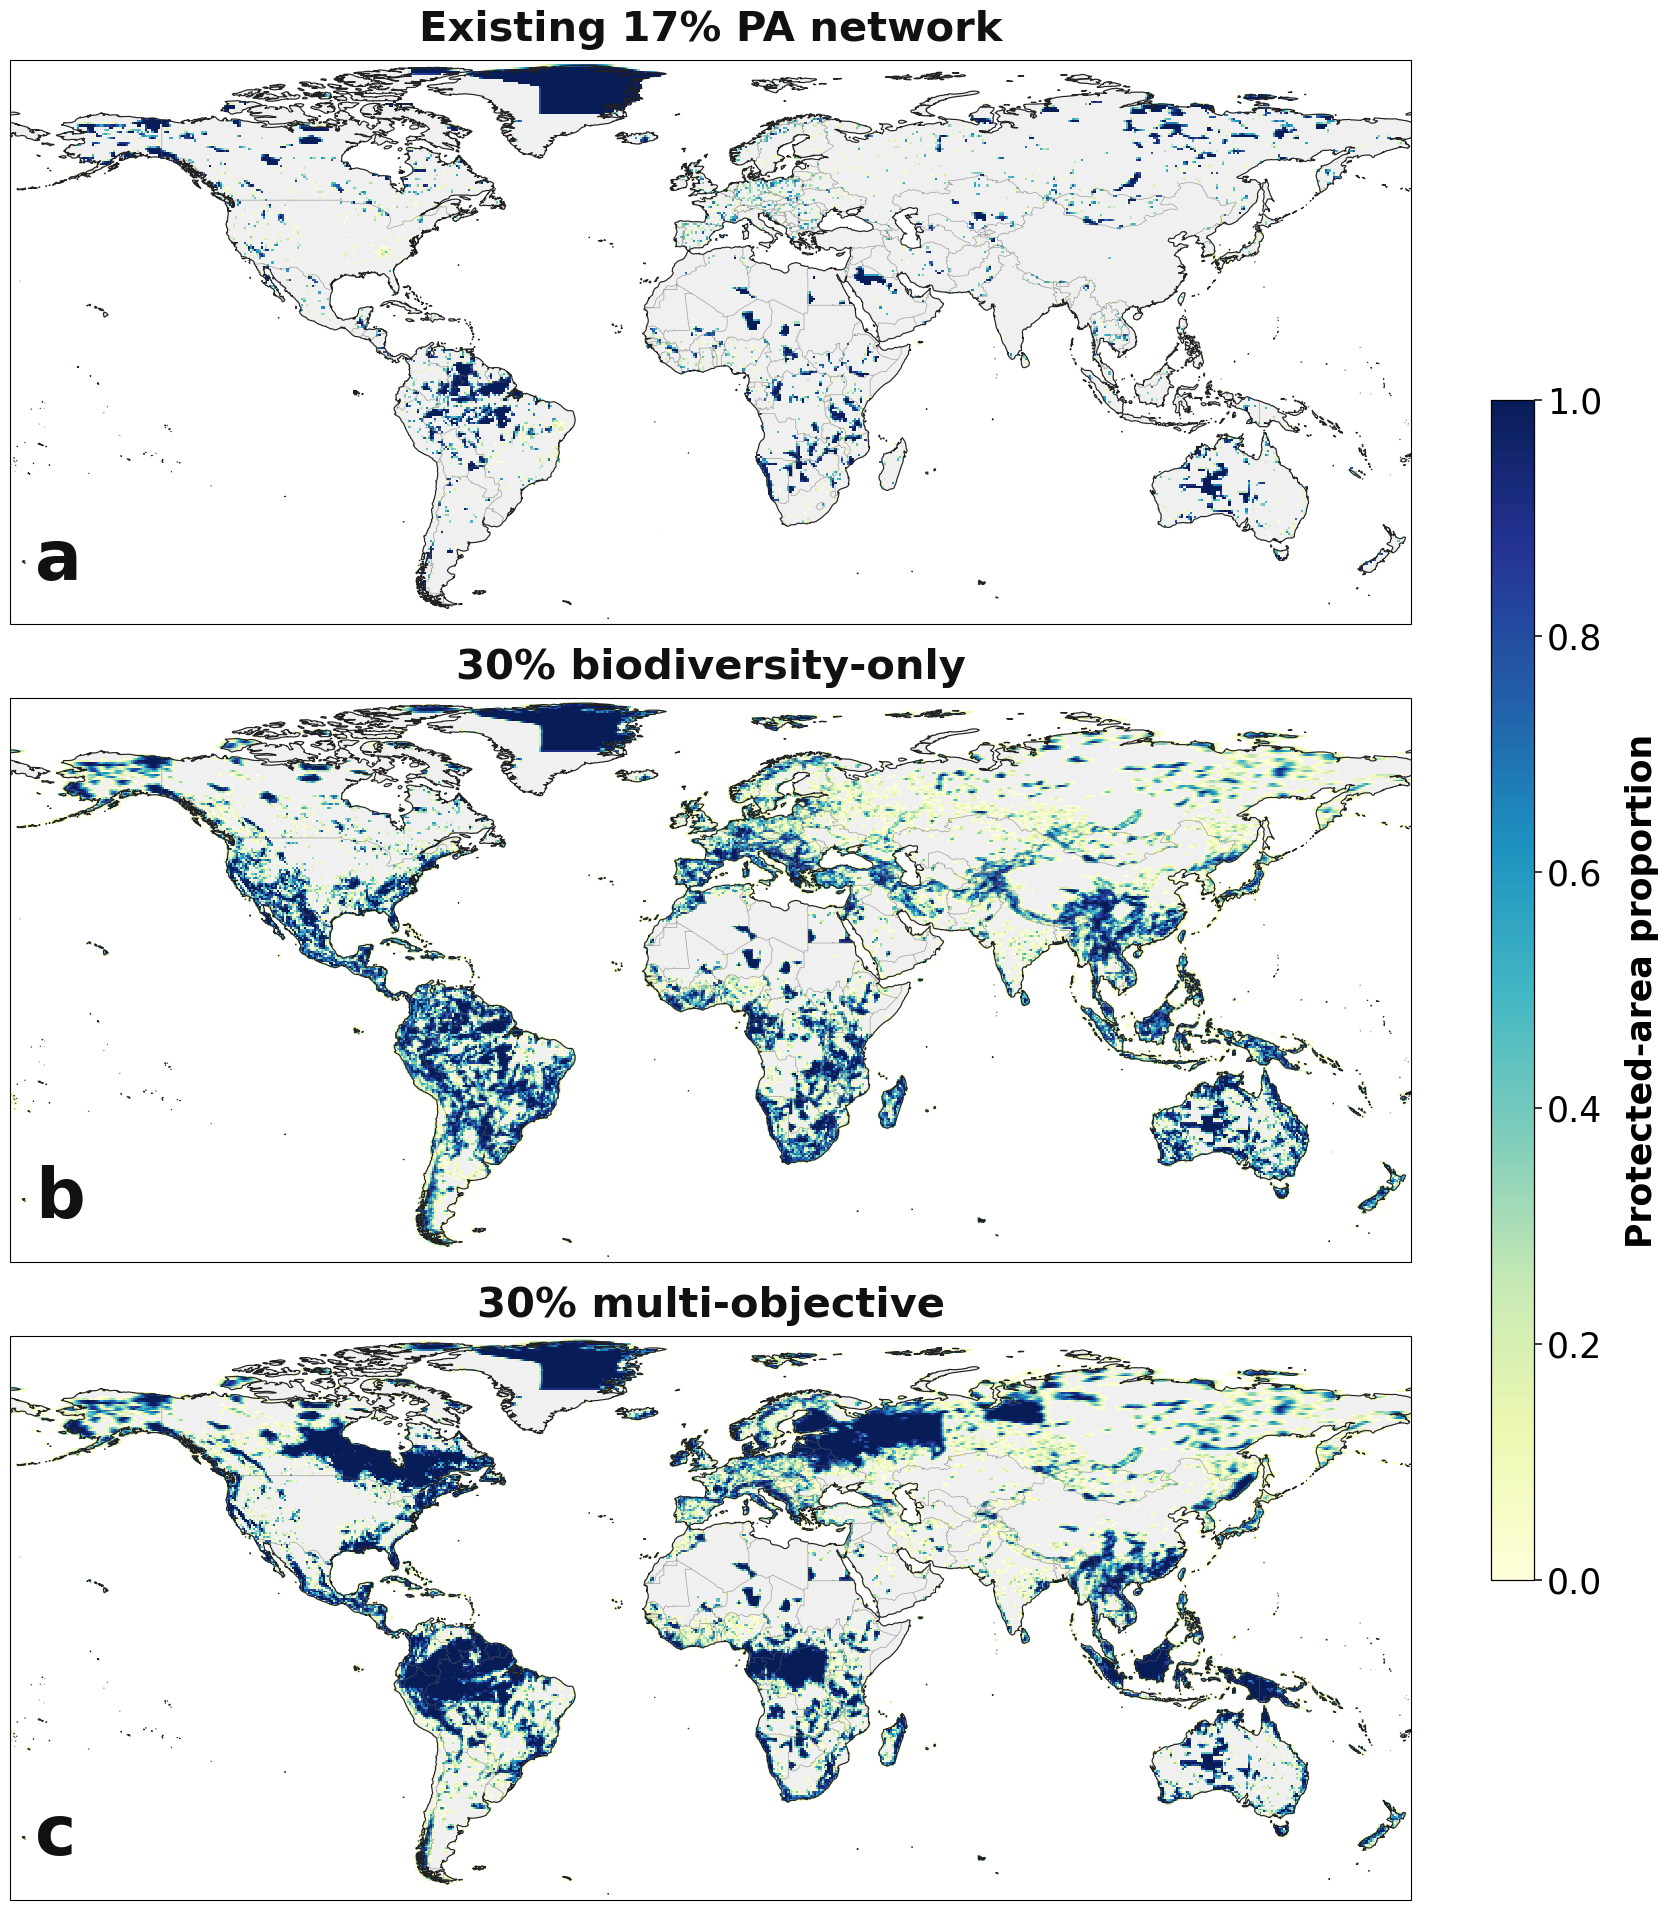


Outputs saved successfully:
  PDF:  /capacity/occr_davin/mguzman/chari_P2_review/Global/New_results/Figures/Global_PA_scenarios_large_fonts.pdf
  PNG:  /capacity/occr_davin/mguzman/chari_P2_review/Global/New_results/Figures/Global_PA_scenarios_large_fonts.png
  TIFF: /capacity/occr_davin/mguzman/chari_P2_review/Global/New_results/Figures/Global_PA_scenarios_large_fonts.tiff


In [83]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""Plot global protected-area coverage for three PA configurations.

Panels:
    a. Existing 17% protected-area network
    b. 30% biodiversity-only configuration
    c. 30% multi-objective configuration

The script uses a large canvas and enlarged typography. All panels share one protected-area
proportion colour scale and one common vertical colour bar.

Outputs:
    - PDF with vector text and rasterized map layers
    - PNG at 600 dpi
    - LZW-compressed TIFF at 600 dpi
"""

from pathlib import Path
import warnings

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

warnings.filterwarnings("ignore", category=RuntimeWarning)


# =====================================================================
# 1. PATHS
# =====================================================================

INPUT_PATHS = {
    "a": Path(
        "/capacity/occr_davin/mguzman/chari_P2_review/"
        "data/PA_masks/WDPA_percentage_map.nc"
    ),
    "b": Path(
        "/capacity/occr_davin/mguzman/chari_P2_review/"
        "data/PA_masks/bio-only_withPA.nc"
    ),
    "c": Path(
        "/capacity/occr_davin/mguzman/chari_P2_review/"
        "data/PA_masks/bcw_withPA.nc"
    ),
}

OUTPUT_DIR = Path(
    "/capacity/occr_davin/mguzman/chari_P2_review/"
    "Global/New_results/Figures"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PDF = OUTPUT_DIR / "Global_PA_scenarios_large_fonts.pdf"
OUTPUT_PNG = OUTPUT_DIR / "Global_PA_scenarios_large_fonts.png"
OUTPUT_TIFF = OUTPUT_DIR / "Global_PA_scenarios_large_fonts.tiff"


# =====================================================================
# 2. PANEL AND DATA SETTINGS
# =====================================================================

PANEL_TITLES = {
    "a": "Existing 17% PA network",
    "b": "30% biodiversity-only",
    "c": "30% multi-objective",
}

# The WDPA input is expressed as percentage and must be converted to 0-1.
PERCENTAGE_INPUTS = {"a"}

MAP_EXTENT = [-180, 180, -60, 85]
COLOR_MINIMUM = 0.0
COLOR_MAXIMUM = 1.0
COLOR_MAP = "YlGnBu"
OUTPUT_DPI = 600


# =====================================================================
# 3. FIGURE SETTINGS
# =====================================================================

FIGURE_WIDTH = 24
FIGURE_HEIGHT = 20

TITLE_SIZE = 30
PANEL_LABEL_SIZE = 50
COLORBAR_LABEL_SIZE = 25
COLORBAR_TICK_SIZE = 25

COASTLINE_WIDTH = 0.85
BORDER_WIDTH = 0.45

OCEAN_COLOR = "#FFFFFF"
LAND_NO_DATA_COLOR = "#F0F0F0"
COASTLINE_COLOR = "#222222"
BORDER_COLOR = "#666666"

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 22,
        "axes.titlesize": TITLE_SIZE,
        "axes.linewidth": 0.8,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "savefig.facecolor": "white",
        "savefig.edgecolor": "white",
    }
)


# =====================================================================
# 4. DATA HELPERS
# =====================================================================


def standardize_coordinates(data_array):
    """Standardize latitude and longitude coordinate names and ordering."""

    rename = {}

    if "latitude" in data_array.coords or "latitude" in data_array.dims:
        rename["latitude"] = "lat"

    if "longitude" in data_array.coords or "longitude" in data_array.dims:
        rename["longitude"] = "lon"

    if rename:
        data_array = data_array.rename(rename)

    if "lat" not in data_array.coords or "lon" not in data_array.coords:
        raise ValueError(
            "Input data do not contain recognizable latitude and longitude "
            "coordinates."
        )

    # Convert 0-360 degrees to -180-180 degrees when required.
    if float(data_array["lon"].max()) > 180:
        data_array = data_array.assign_coords(
            lon=((data_array["lon"] + 180) % 360) - 180
        )

    return data_array.sortby("lon").sortby("lat")



def load_pa_fraction(file_path, convert_percentage=False):
    """Load and validate one protected-area fraction raster."""

    if not file_path.is_file():
        raise FileNotFoundError(f"Input file not found:\n{file_path}")

    if file_path.stat().st_size == 0:
        raise ValueError(f"Input file is empty:\n{file_path}")

    with xr.open_dataset(file_path, decode_times=False) as dataset:
        if not dataset.data_vars:
            raise ValueError(f"No data variables found in:\n{file_path}")

        variable_name = list(dataset.data_vars)[0]
        data = dataset[variable_name].squeeze(drop=True).load()

    data = standardize_coordinates(data).astype(np.float64)

    if convert_percentage:
        data = data / 100.0

    finite_values = data.values[np.isfinite(data.values)]

    if finite_values.size == 0:
        raise ValueError(f"No finite values found in:\n{file_path}")

    # PA fraction should lie in [0, 1]. Small numerical excursions are clipped,
    # while larger excursions trigger an explicit error.
    tolerance = 1e-6
    data_minimum = float(np.nanmin(finite_values))
    data_maximum = float(np.nanmax(finite_values))

    if data_minimum < -tolerance or data_maximum > 1.0 + tolerance:
        raise ValueError(
            f"Protected-area values fall outside [0, 1] after conversion in:\n"
            f"{file_path}\n"
            f"Minimum: {data_minimum:.6f}; maximum: {data_maximum:.6f}"
        )

    return data.clip(min=0.0, max=1.0), variable_name


# =====================================================================
# 5. LOAD ALL INPUTS BEFORE CREATING THE FIGURE
# =====================================================================

pa_data = {}

for panel_label, file_path in INPUT_PATHS.items():
    convert_percentage = panel_label in PERCENTAGE_INPUTS

    print(f"Loading panel {panel_label}: {file_path}")

    data, variable_name = load_pa_fraction(
        file_path,
        convert_percentage=convert_percentage,
    )

    pa_data[panel_label] = data

    finite_values = data.values[np.isfinite(data.values)]
    protected_values = finite_values[finite_values > 0]

    print(f"  Variable: {variable_name}")
    print(f"  Finite cells: {finite_values.size:,}")
    print(f"  Protected cells: {protected_values.size:,}")

    if protected_values.size > 0:
        print(f"  Protected minimum: {protected_values.min():.6f}")
        print(f"  Protected maximum: {protected_values.max():.6f}")


# =====================================================================
# 6. FIGURE SETUP
# =====================================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(FIGURE_WIDTH, FIGURE_HEIGHT),
    facecolor=OCEAN_COLOR,
    subplot_kw={"projection": ccrs.PlateCarree()},
)

# Reserve one fixed column on the right for the shared colour bar.
plt.subplots_adjust(
    left=0.055,
    right=0.895,
    top=0.965,
    bottom=0.045,
    hspace=0.13,
)

image = None


# =====================================================================
# 7. PLOT PANELS
# =====================================================================

for axis, panel_label in zip(axes, INPUT_PATHS):
    data = pa_data[panel_label]

    # Show only positive protected-area fractions in the raster. Unprotected
    # and missing terrestrial cells reveal the pale land background.
    data_masked = data.where(
        np.isfinite(data) & (data > 0)
    )

    axis.set_extent(
        MAP_EXTENT,
        crs=ccrs.PlateCarree(),
    )
    axis.set_facecolor(OCEAN_COLOR)

    axis.add_feature(
        cfeature.LAND.with_scale("50m"),
        facecolor=LAND_NO_DATA_COLOR,
        edgecolor="none",
        zorder=0,
    )

    image = axis.pcolormesh(
        data_masked["lon"],
        data_masked["lat"],
        np.ma.masked_invalid(data_masked.values),
        transform=ccrs.PlateCarree(),
        vmin=COLOR_MINIMUM,
        vmax=COLOR_MAXIMUM,
        cmap=COLOR_MAP,
        shading="auto",
        rasterized=True,
        zorder=1,
    )

    axis.coastlines(
        resolution="50m",
        color=COASTLINE_COLOR,
        linewidth=COASTLINE_WIDTH,
        zorder=3,
    )

    axis.add_feature(
        cfeature.BORDERS.with_scale("50m"),
        edgecolor=BORDER_COLOR,
        linewidth=BORDER_WIDTH,
        alpha=0.65,
        zorder=3,
    )

    axis.set_title(
        PANEL_TITLES[panel_label],
        fontsize=TITLE_SIZE,
        fontweight="bold",
        fontstyle="normal",
        pad=14,
        color="#111111",
    )

    # Lowercase panel labels match the convention used in the other figures.
    axis.text(
        0.018,
        0.055,
        panel_label,
        transform=axis.transAxes,
        fontsize=PANEL_LABEL_SIZE,
        fontweight="bold",
        ha="left",
        va="bottom",
        color="#111111",
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.90,
            "pad": 1.5,
        },
        zorder=10,
    )


# =====================================================================
# 8. SHARED COLOUR BAR
# =====================================================================

if image is None:
    raise RuntimeError("No protected-area raster was plotted.")

# A single shared scale is clearer and avoids repeating identical labels.
colorbar_axis = fig.add_axes(
    [
        0.800,
        0.205,
        0.018,
        0.590,
    ]
)

colorbar = fig.colorbar(
    image,
    cax=colorbar_axis,
    orientation="vertical",
    ticks=np.linspace(0.0, 1.0, 6),
)

colorbar.set_label(
    "Protected-area proportion",
    fontsize=COLORBAR_LABEL_SIZE,
    fontweight="semibold",
    labelpad=16,
)

colorbar.ax.tick_params(
    labelsize=COLORBAR_TICK_SIZE,
    width=1.1,
    length=6,
)

colorbar.outline.set_linewidth(0.9)


# =====================================================================
# 9. SAVE OUTPUTS
# =====================================================================

png_metadata = {
    "Title": "Global protected-area configurations",
    "Description": (
        "Protected-area proportion under the existing 17% network, "
        "30% biodiversity-only configuration, and 30% multi-objective "
        "configuration."
    ),
}

pdf_metadata = {
    "Title": png_metadata["Title"],
    "Subject": png_metadata["Description"],
}

fig.savefig(
    OUTPUT_PDF,
    format="pdf",
    dpi=OUTPUT_DPI,
    bbox_inches="tight",
    pad_inches=0.08,
    facecolor=OCEAN_COLOR,
    edgecolor=OCEAN_COLOR,
    transparent=False,
    metadata=pdf_metadata,
)

fig.savefig(
    OUTPUT_PNG,
    format="png",
    dpi=OUTPUT_DPI,
    bbox_inches="tight",
    pad_inches=0.08,
    facecolor=OCEAN_COLOR,
    edgecolor=OCEAN_COLOR,
    transparent=False,
    metadata=png_metadata,
)

fig.savefig(
    OUTPUT_TIFF,
    format="tiff",
    dpi=OUTPUT_DPI,
    bbox_inches="tight",
    pad_inches=0.08,
    facecolor=OCEAN_COLOR,
    edgecolor=OCEAN_COLOR,
    transparent=False,
    pil_kwargs={"compression": "tiff_lzw"},
)

plt.show()
# For non-interactive cluster execution, replace plt.show() with:
# plt.close(fig)

print("\nOutputs saved successfully:")
print(f"  PDF:  {OUTPUT_PDF}")
print(f"  PNG:  {OUTPUT_PNG}")
print(f"  TIFF: {OUTPUT_TIFF}")
